In [ ]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import soundfile as sf

KEYWORDS_DIR = Path("keywords_augmented")
UNKNOWN_DIR = Path("unknown_balanced")
KEYWORD_LABELS = ["får", "ged", "hest", "laks", "ulv"]
SAMPLE_RATE = 16000

records = []

def load_wav(path):
    x, fs = sf.read(str(path), always_2d=False)
    x = np.asarray(x, dtype=np.float32)
    if x.ndim > 1:
        x = x.mean(axis=1)
    if fs != SAMPLE_RATE:
        raise ValueError(f"Unexpected sample rate in {path}: {fs}")
    return x

def magnitude_spectrum(x, fs):
    window = np.hanning(len(x))
    xw = x * window
    spec = np.fft.rfft(xw)
    mag = np.abs(spec)
    freqs = np.fft.rfftfreq(len(xw), d=1/fs)
    return freqs, mag


# Kurtosis 

# Crest Factor 

# Variance

# Std. Deviation


def rms_energy(x):
    return float(np.sqrt(np.mean(x**2) + 1e-12))

def zero_crossing_rate(x):
    return float(np.mean(np.signbit(x[1:]) != np.signbit(x[:-1])))

def spectral_centroid(x, fs):
    freqs, mag = magnitude_spectrum(x, fs)
    return float(np.sum(freqs * mag) / (np.sum(mag) + 1e-12))

def spectral_rolloff(x, fs, roll_percent=0.85):
    freqs, mag = magnitude_spectrum(x, fs)
    cumsum = np.cumsum(mag)
    threshold = roll_percent * cumsum[-1]
    idx = np.searchsorted(cumsum, threshold)
    return float(freqs[min(idx, len(freqs)-1)])

def dominant_frequency(x, fs):
    freqs, mag = magnitude_spectrum(x, fs)
    idx = np.argmax(mag[1:]) + 1 if len(mag) > 1 else 0
    return float(freqs[idx])

# argmin frequency 

def band_energy(x, fs, f_low, f_high):
    freqs, mag = magnitude_spectrum(x, fs)
    power = mag**2
    mask = (freqs >= f_low) & (freqs < f_high)
    return float(np.sum(power[mask]))

# keywords
for label in KEYWORD_LABELS:
    for wav_path in sorted((KEYWORDS_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)

        record = {
            "rms": rms_energy(x),
            "zcr": zero_crossing_rate(x),
            "centroid": spectral_centroid(x, SAMPLE_RATE),
            "rolloff": spectral_rolloff(x, SAMPLE_RATE),
            "dominant_freq": dominant_frequency(x, SAMPLE_RATE),
            "band_0_500": band_energy(x, SAMPLE_RATE, 0, 500),
            "band_500_1500": band_energy(x, SAMPLE_RATE, 500, 1500),
            "band_1500_3000": band_energy(x, SAMPLE_RATE, 1500, 3000),
            "band_3000_6000": band_energy(x, SAMPLE_RATE, 3000, 6000),
            "activity": label,
            "filename": wav_path.name,
        }
        records.append(record)

# unknown
for wav_path in sorted(UNKNOWN_DIR.glob("*.wav")):
    x = load_wav(wav_path)

    record = {
        "rms": rms_energy(x),
        "zcr": zero_crossing_rate(x),
        "centroid": spectral_centroid(x, SAMPLE_RATE),
        "rolloff": spectral_rolloff(x, SAMPLE_RATE),
        "dominant_freq": dominant_frequency(x, SAMPLE_RATE),
        "band_0_500": band_energy(x, SAMPLE_RATE, 0, 500),
        "band_500_1500": band_energy(x, SAMPLE_RATE, 500, 1500),
        "band_1500_3000": band_energy(x, SAMPLE_RATE, 1500, 3000),
        "band_3000_6000": band_energy(x, SAMPLE_RATE, 3000, 6000),
        "activity": "unknown",
        "filename": wav_path.name,
    }
    records.append(record)

feature_df = pd.DataFrame(records)
print(feature_df.head())
print(feature_df.shape)

feature_df.to_csv("audio_features.csv", index=False)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

X = feature_df.drop(columns=["activity", "filename"])
y = feature_df["activity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=np.unique(y))
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=np.unique(y),
            yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest on audio features")
plt.show()

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    clf,
    X,
    y,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8,6))

plt.plot(train_sizes, train_mean, label="Training accuracy")
plt.plot(train_sizes, val_mean, label="Validation accuracy")

plt.xlabel("Training samples")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Random Forest")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import pandas as pd

importances = clf.feature_importances_

feat_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

print(feat_importance)

ALT OVENOVER ER FEATURE BEREGNING UDEN MFCC. HER FÅR VI EN LIDT LAVERE ACCURACY SCORE END HVIS MFCC VAR MED, MEN DET ER STADIGVÆK EN RET STOR SCORE UDEN MFCC, HVILKET UMIDDELBART ER GODT. 

Nedenunder viser feature beregning med MFCC.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# =========================
# SETTINGS
# =========================
KEYWORDS_DIR = Path("keywords_augmented")
UNKNOWN_DIR = Path("unknown_balanced")
KEYWORD_LABELS = ["får", "ged", "hest", "laks", "ulv"]
SAMPLE_RATE = 16000
N_MFCC = 13

# =========================
# AUDIO / FEATURE FUNCTIONS
# =========================
def load_wav(path: Path):
    x, fs = sf.read(str(path), always_2d=False)
    x = np.asarray(x, dtype=np.float32)

    if x.ndim > 1:
        x = x.mean(axis=1)

    if fs != SAMPLE_RATE:
        raise ValueError(f"Unexpected sample rate in {path}: {fs}")

    return x

def magnitude_spectrum(x, fs):
    window = np.hanning(len(x))
    xw = x * window
    spec = np.fft.rfft(xw)
    mag = np.abs(spec)
    freqs = np.fft.rfftfreq(len(xw), d=1 / fs)
    return freqs, mag

def rms_energy(x):
    return float(np.sqrt(np.mean(x ** 2) + 1e-12))

def zero_crossing_rate(x):
    return float(np.mean(np.signbit(x[1:]) != np.signbit(x[:-1])))

def spectral_centroid(x, fs):
    freqs, mag = magnitude_spectrum(x, fs)
    return float(np.sum(freqs * mag) / (np.sum(mag) + 1e-12))

def spectral_rolloff(x, fs, roll_percent=0.85):
    freqs, mag = magnitude_spectrum(x, fs)
    cumsum = np.cumsum(mag)
    threshold = roll_percent * cumsum[-1]
    idx = np.searchsorted(cumsum, threshold)
    return float(freqs[min(idx, len(freqs) - 1)])

def dominant_frequency(x, fs):
    freqs, mag = magnitude_spectrum(x, fs)
    idx = np.argmax(mag[1:]) + 1 if len(mag) > 1 else 0
    return float(freqs[idx])

def band_energy(x, fs, f_low, f_high):
    freqs, mag = magnitude_spectrum(x, fs)
    power = mag ** 2
    mask = (freqs >= f_low) & (freqs < f_high)
    return float(np.sum(power[mask]))

def mfcc_features(x, sr, n_mfcc=13):
    mfcc = librosa.feature.mfcc(
        y=x,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=1024,
        hop_length=512
    )
    return np.mean(mfcc, axis=1)

def extract_features(x, fs):
    record = {
        "rms": rms_energy(x),
        "zcr": zero_crossing_rate(x),
        "centroid": spectral_centroid(x, fs),
        "rolloff": spectral_rolloff(x, fs),
        "dominant_freq": dominant_frequency(x, fs),
        "band_0_500": band_energy(x, fs, 0, 500),
        "band_500_1500": band_energy(x, fs, 500, 1500),
        "band_1500_3000": band_energy(x, fs, 1500, 3000),
        "band_3000_6000": band_energy(x, fs, 3000, 6000),
    }

    mfcc_vals = mfcc_features(x, fs, n_mfcc=N_MFCC)
    for i, val in enumerate(mfcc_vals, start=1):
        record[f"mfcc_{i}"] = float(val)

    return record

# =========================
# BUILD FEATURE DATAFRAME
# =========================
records = []

# keywords
for label in KEYWORD_LABELS:
    for wav_path in sorted((KEYWORDS_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        record = extract_features(x, SAMPLE_RATE)
        record["activity"] = label
        record["filename"] = wav_path.name
        records.append(record)

# unknown
for wav_path in sorted(UNKNOWN_DIR.glob("*.wav")):
    x = load_wav(wav_path)
    record = extract_features(x, SAMPLE_RATE)
    record["activity"] = "unknown"
    record["filename"] = wav_path.name
    records.append(record)

feature_df = pd.DataFrame(records)

print(feature_df.head())
print(feature_df.shape)

feature_df.to_csv("audio_features_with_mfcc.csv", index=False)

# =========================
# FEATURE SETS
# =========================
simple_features = [
    "rms", "zcr", "centroid", "rolloff", "dominant_freq",
    "band_0_500", "band_500_1500", "band_1500_3000", "band_3000_6000"
]

mfcc_feature_cols = [f"mfcc_{i}" for i in range(1, N_MFCC + 1)]

all_features = simple_features + mfcc_feature_cols

# Vælg hvilket sæt du vil teste:
feature_cols = all_features
# feature_cols = simple_features
# feature_cols = mfcc_feature_cols

# =========================
# TRAIN / TEST
# =========================
X = feature_df[feature_cols]
y = feature_df["activity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# =========================
# CONFUSION MATRIX
# =========================
labels_sorted = np.unique(y)
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels_sorted,
    yticklabels=labels_sorted
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest on audio features")
plt.show()

# =========================
# LEARNING CURVE
# =========================
train_sizes, train_scores, val_scores = learning_curve(
    clf,
    X,
    y,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label="Training accuracy")
plt.plot(train_sizes, val_mean, label="Validation accuracy")
plt.xlabel("Training samples")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Random Forest")
plt.legend()
plt.grid(True)
plt.show()

# =========================
# FEATURE IMPORTANCE
# =========================
importances = clf.feature_importances_

feat_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

print(feat_importance)

# Optional plot
plt.figure(figsize=(10, 8))
sns.barplot(data=feat_importance.head(20), x="importance", y="feature")
plt.title("Top 20 Feature Importances")
plt.grid(True, axis="x")
plt.show()

Her får vi denne konklusion:

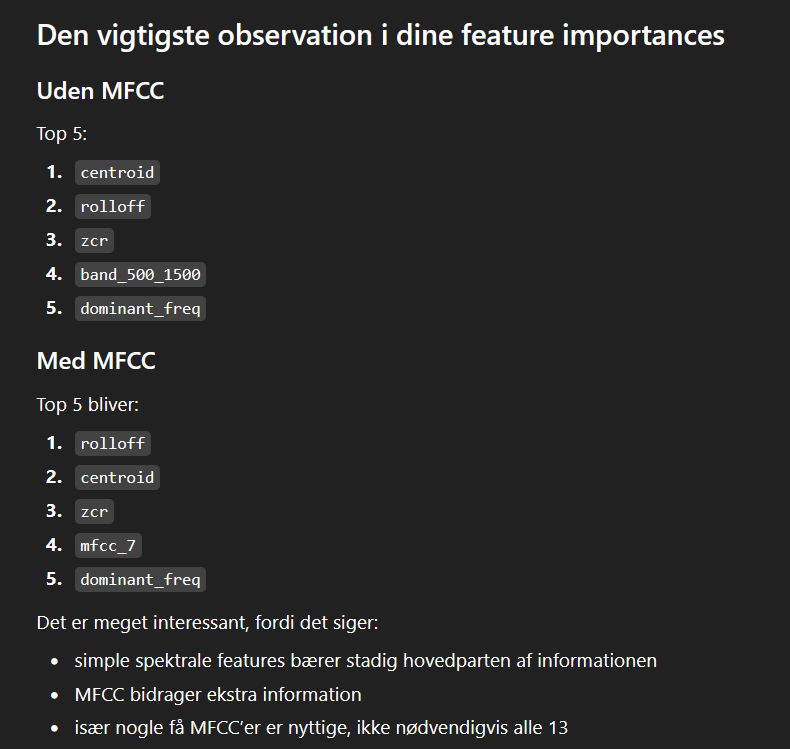

Hertil kan vi lave en sammenligning af accuracy scores med simple features og MFCC only features og dem sammen kombineret: 
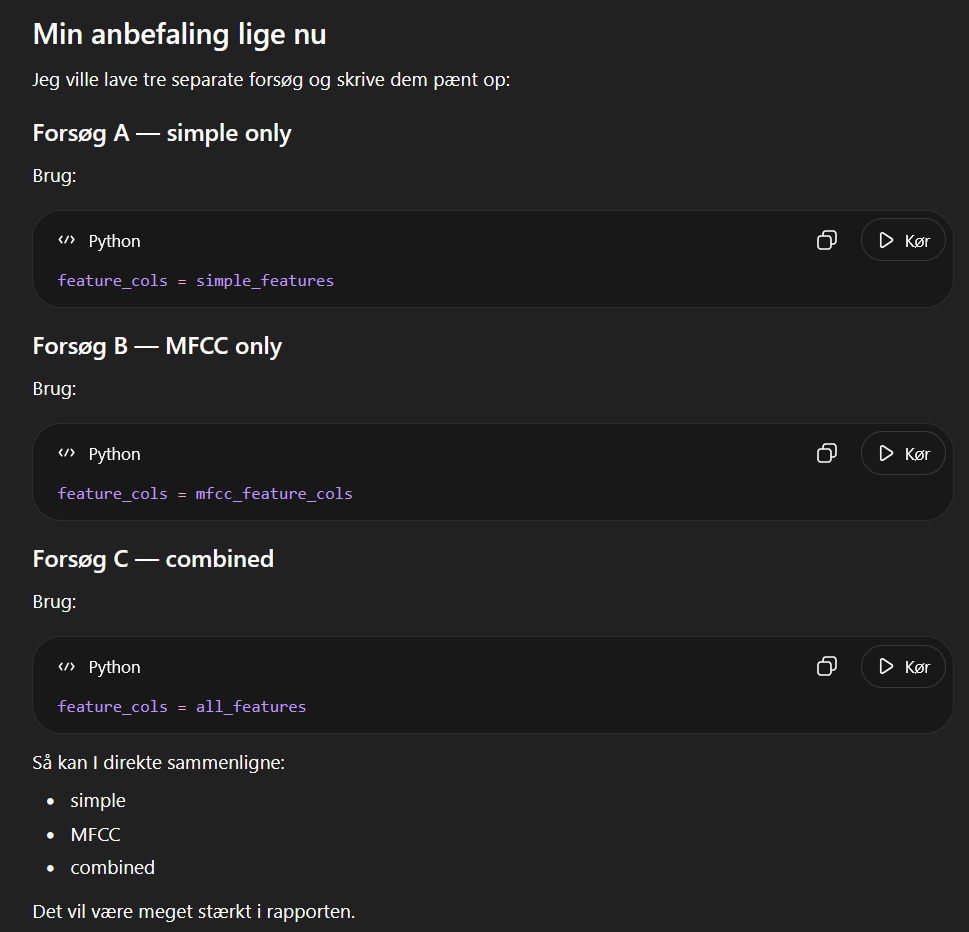

Derudover kan vi lave hvor vi extracter de 5 bedste features. En metode til det er at ved at aflæse feature importances (SPØRG MORTEN OM DETTE ER OK ELLER MAN BØR VÆRE MERE KONSEKVENT), og se hvor meget accuracy scoren så falder:

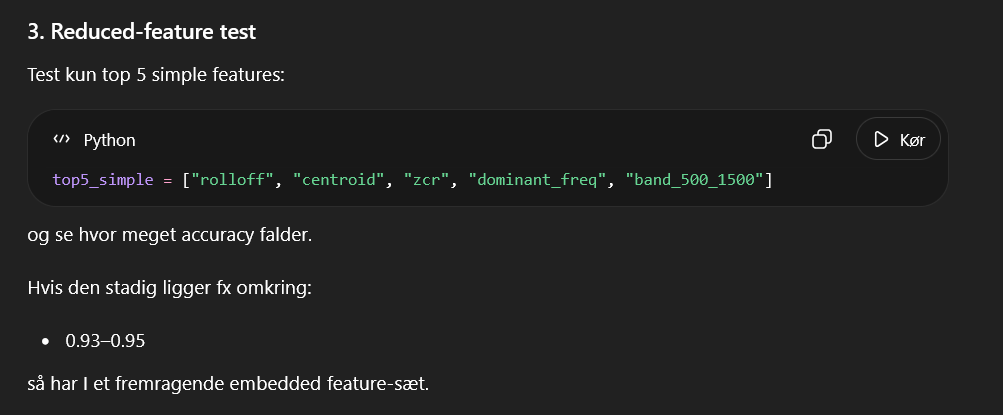



# Dog viser modellen en lille tegn for overfitting ud fra vores accuracy curve

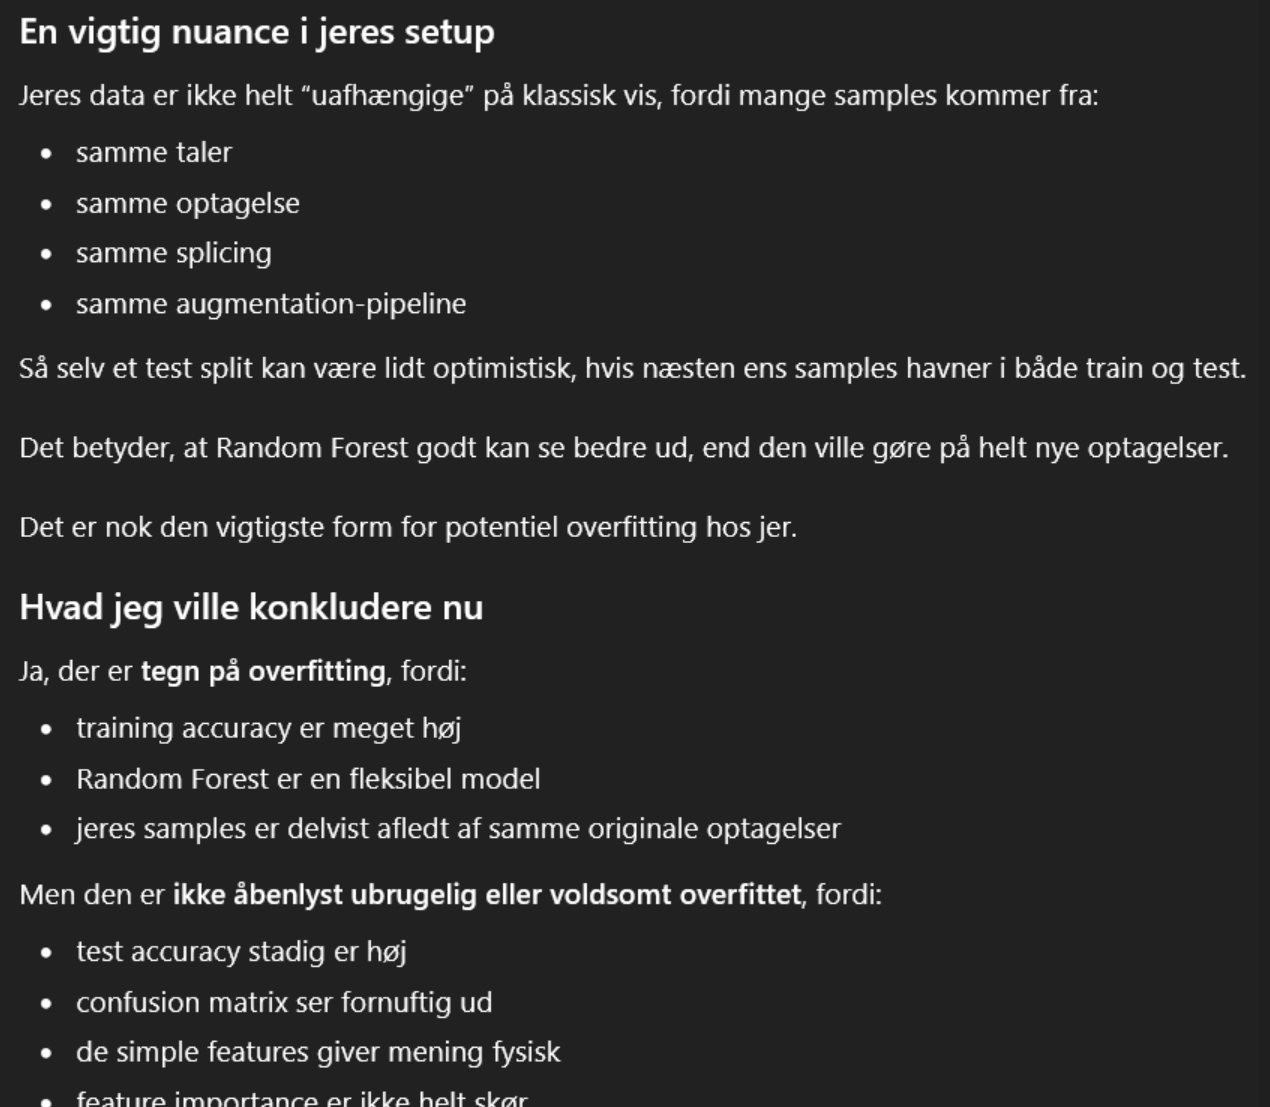

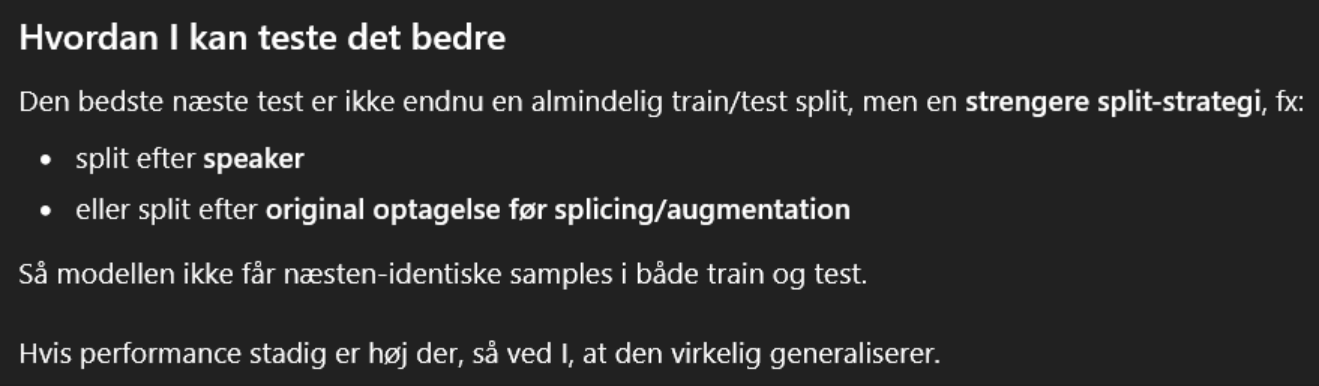

Så der ligger noget analyse i om at vælge en god classifier. Et godt udgangspunkt vil være at følge:
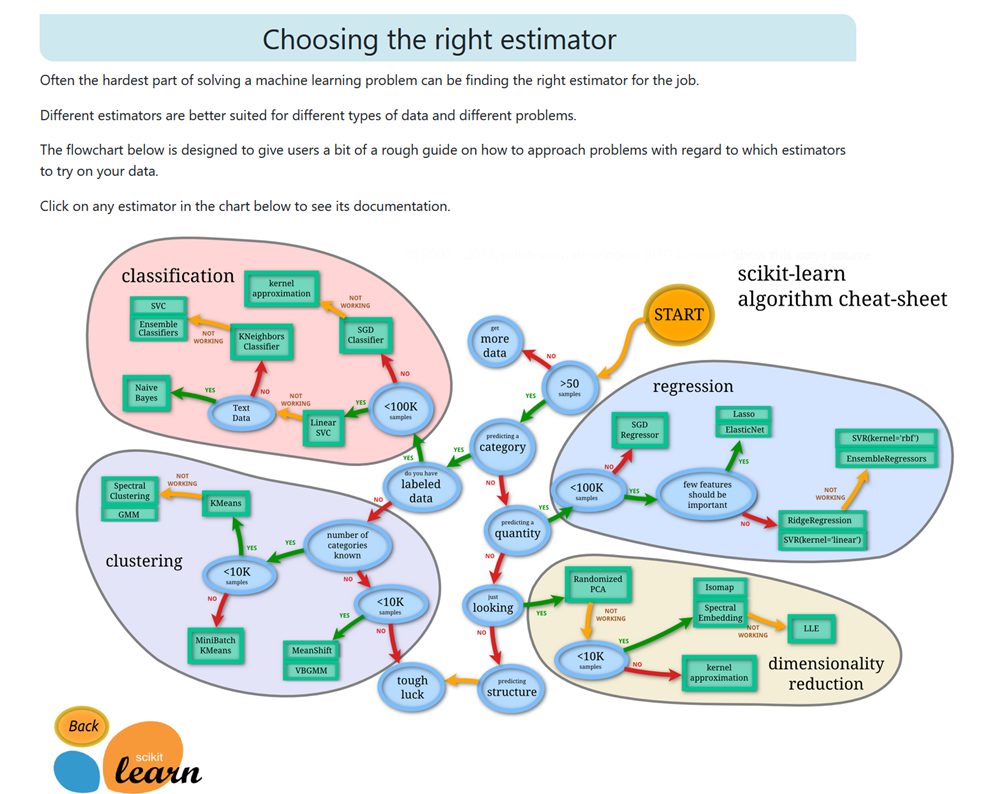

Hvor at vores randomforrest hører under ensemble classifiers. 
Problemet er at ved øjekast ligner det at Random Forrest modellen godt kan overfitte en smule, pga. at generaliserings gap'et mellem training og validation er lige ved at vippe væk fra hinanden. Derfor vil det også være interressant at sammenligne andre modeller som der har mindre kapacitet end Random Forest, men for at se om man kan slippe afsted med mindre kapacitet, SAMT SE OM HVORDAN DET PÅVIRKER ACCURACY SCOREN. 
DET VIL ESSENTIELT SIGE AT VI SKAL KOMBINERE TESTEN MELLEM FORSKELLIGE MODELLER, SAMT TESTE DE ENKELTE MODELLER MED SIMPLE FEATURES ONLY, MFCC ONLY OG KOMBINATION AF SIMPLE OG MFCC FEATURES:

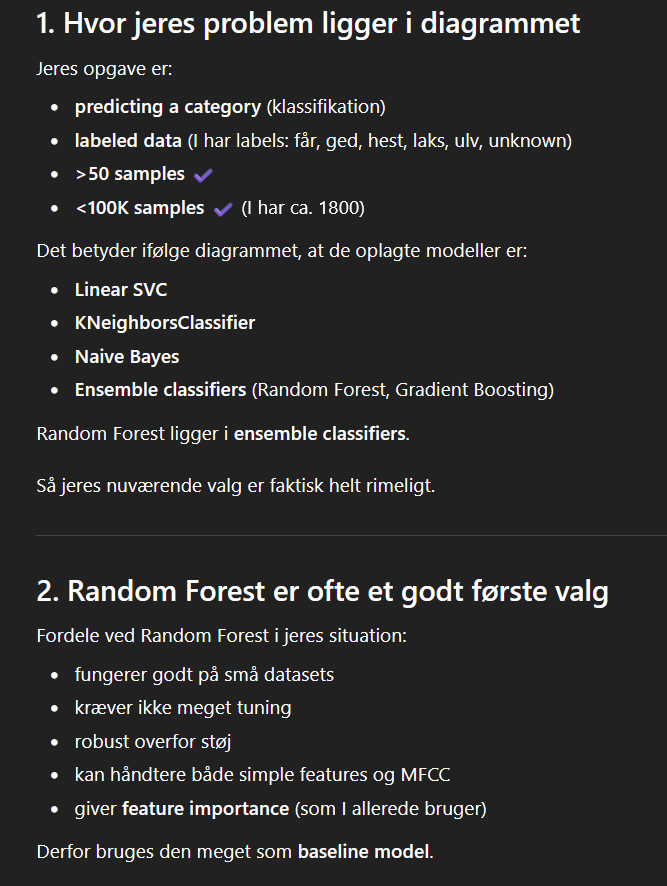

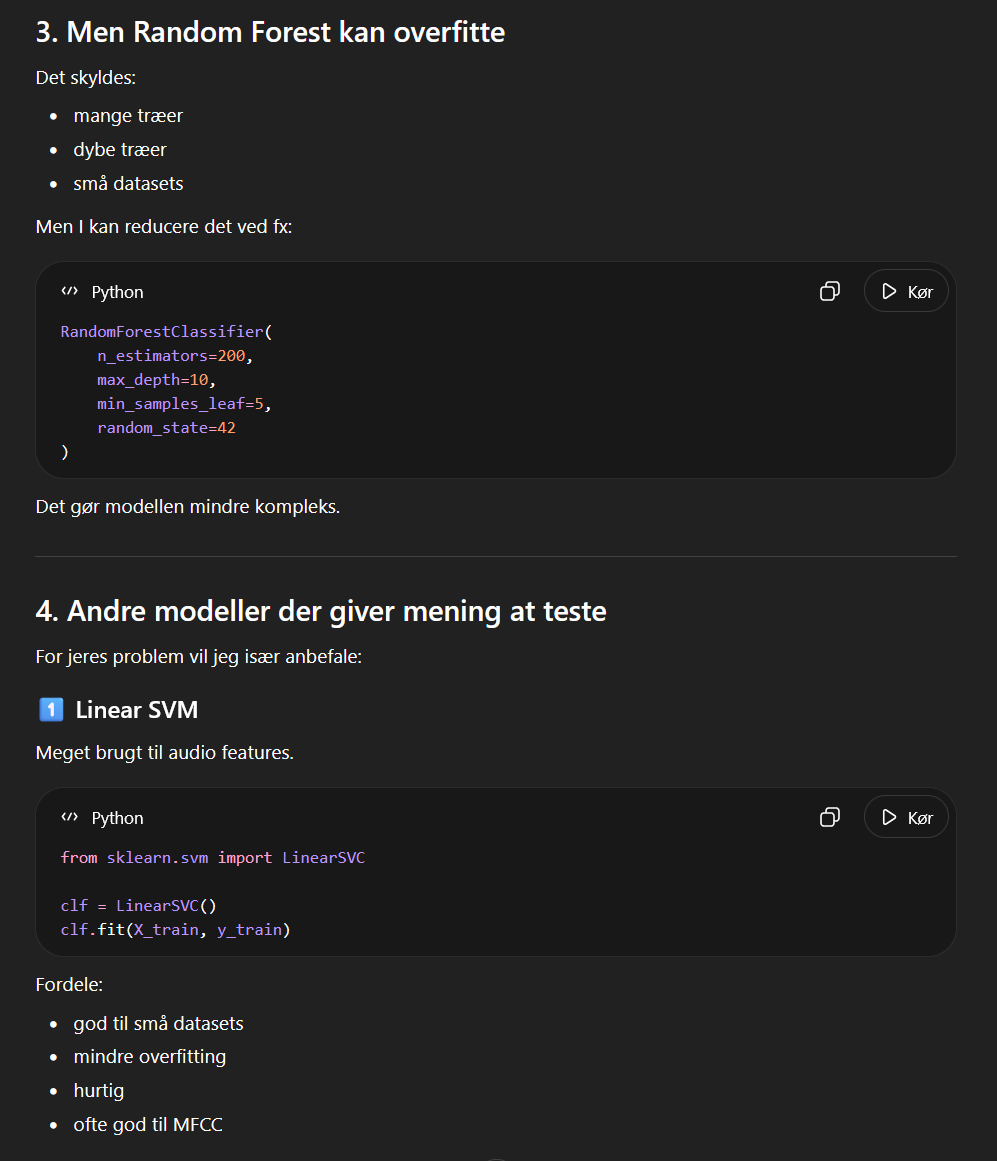

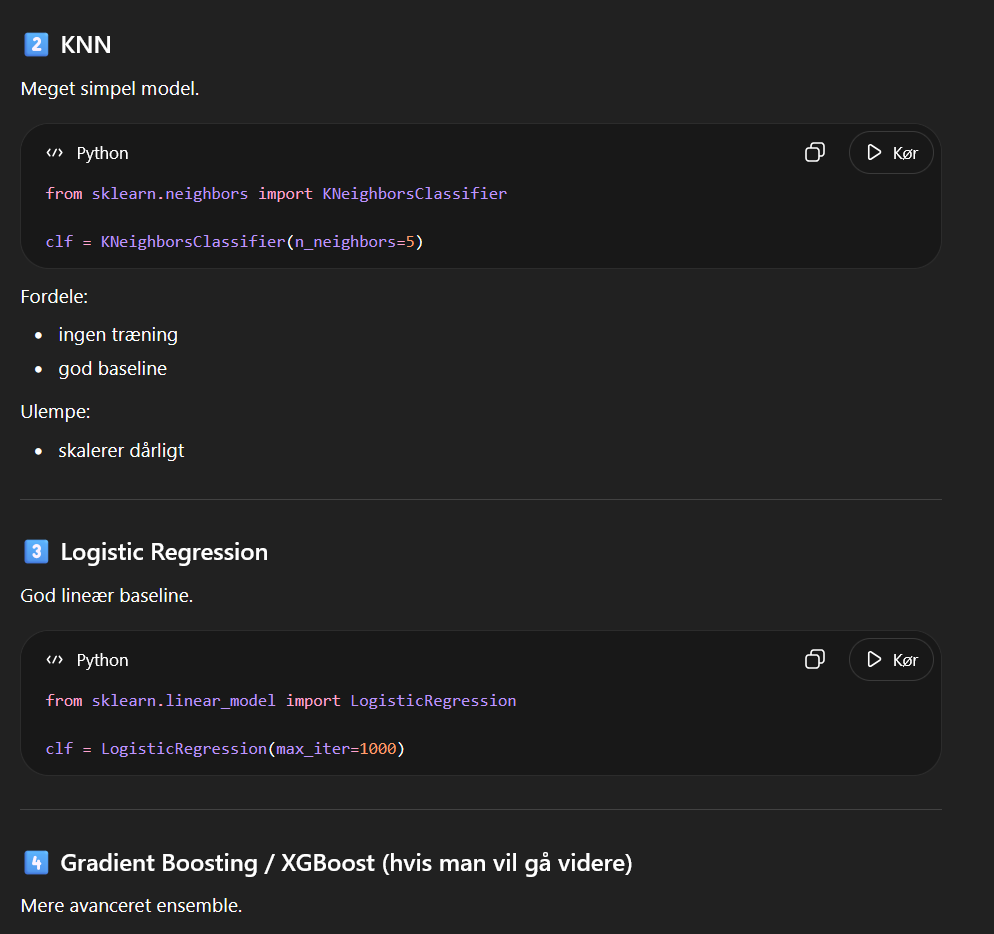

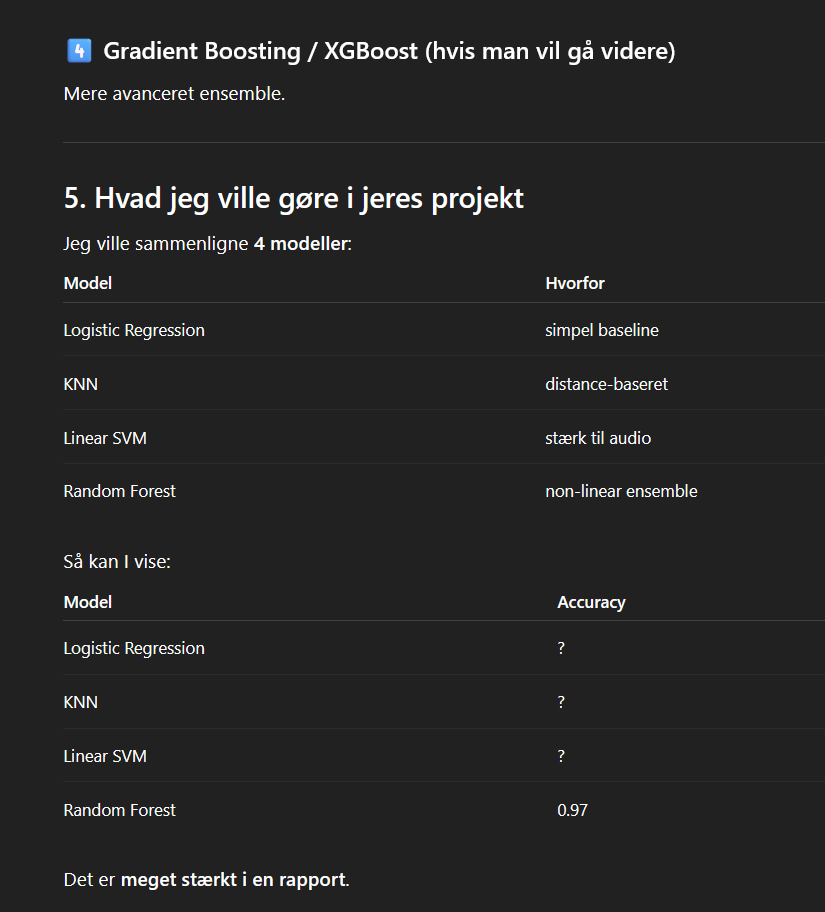

# Endnu en test; Forskellige SNR niveauer af baggrundsstøj (styres mellem 0 og 1 i curation scriptet)

Vi bør også holde øje med om vores model overfitter, pga. manglende preprocessing og scaling. Derfor bør vi have det i overvejelserne, når vi tester forskellige modeller. Samt kan vi opstille pipelines, når vi skal lave scaling

Nedenstående screenshot beskriver faktisk at vi bør lave scaling, fordi at flere af vores features har forskellige størrelsesordener: 
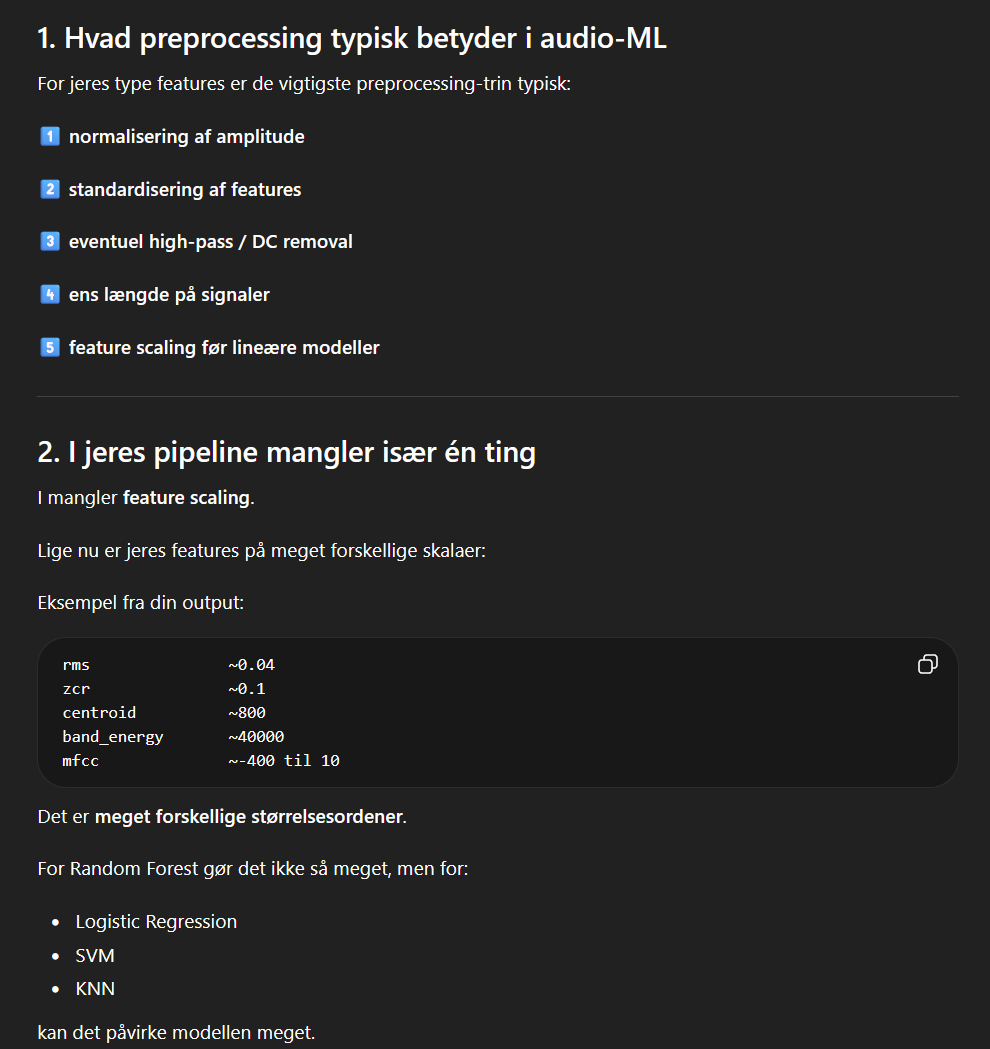

Hertil kan vi bruge Pipelines som vi har lært om i MAL, sammen med vores classifiers, som vi vil teste

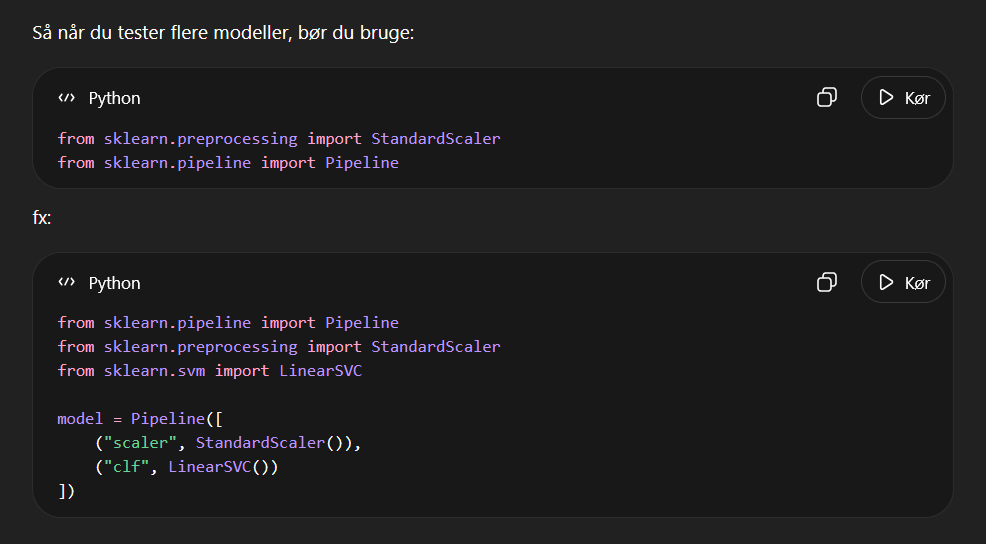

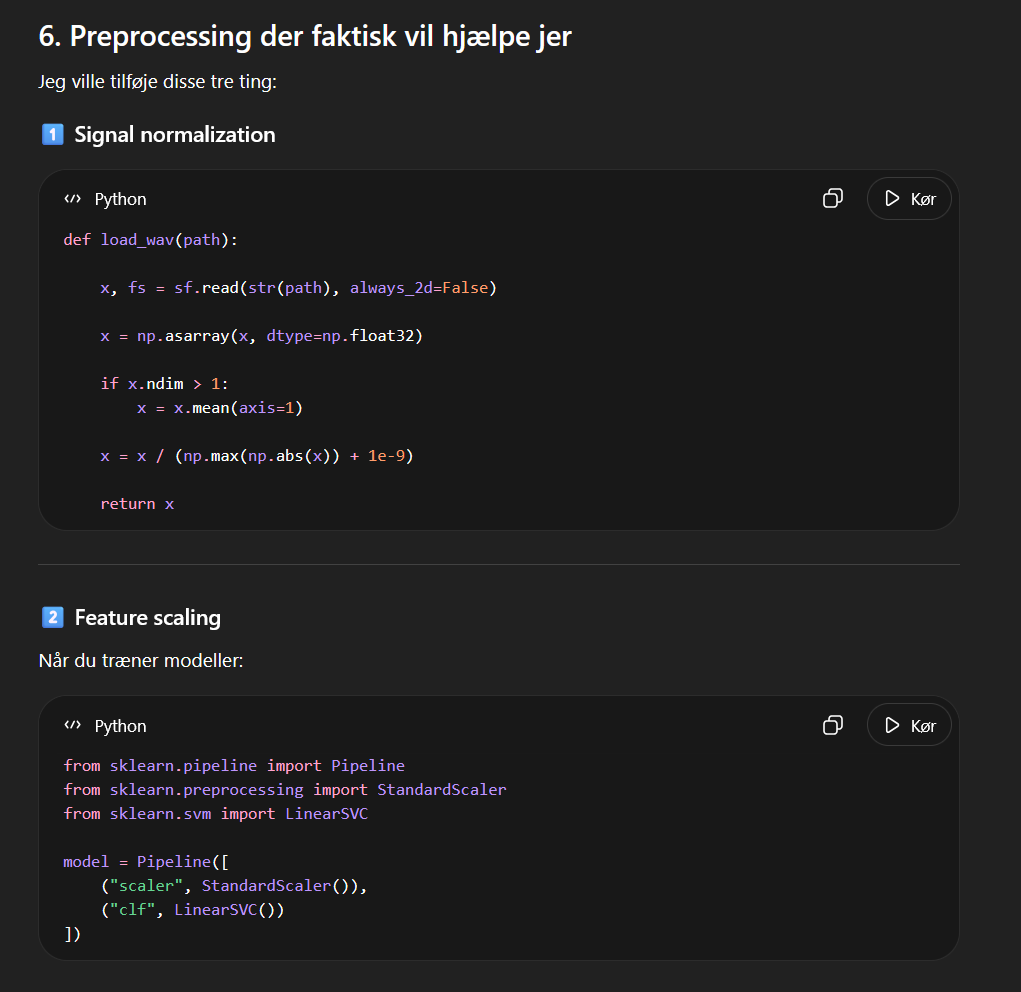

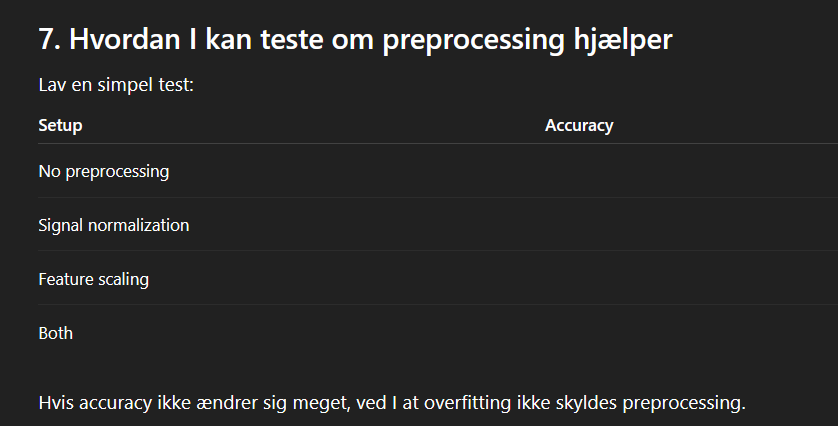

# Som endelig test-split; 

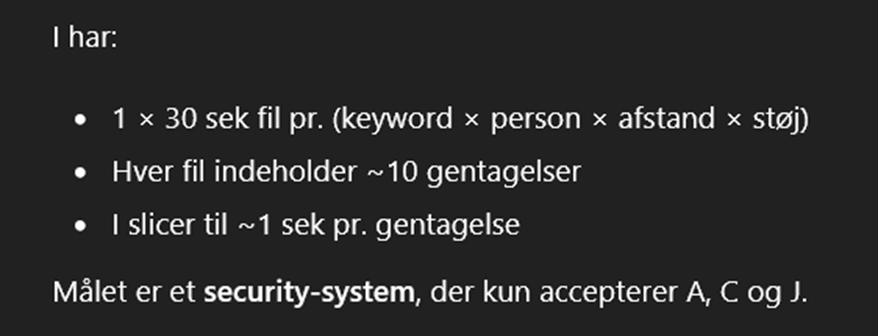

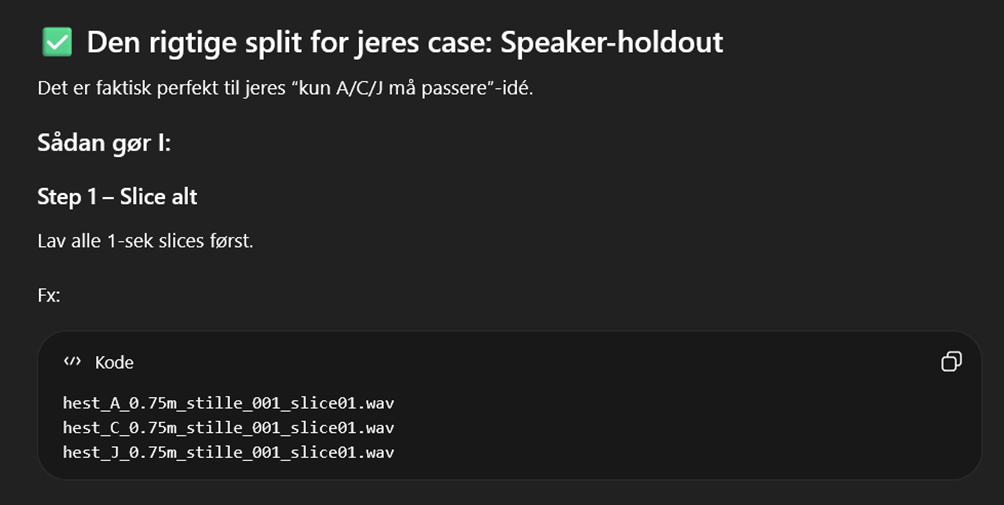

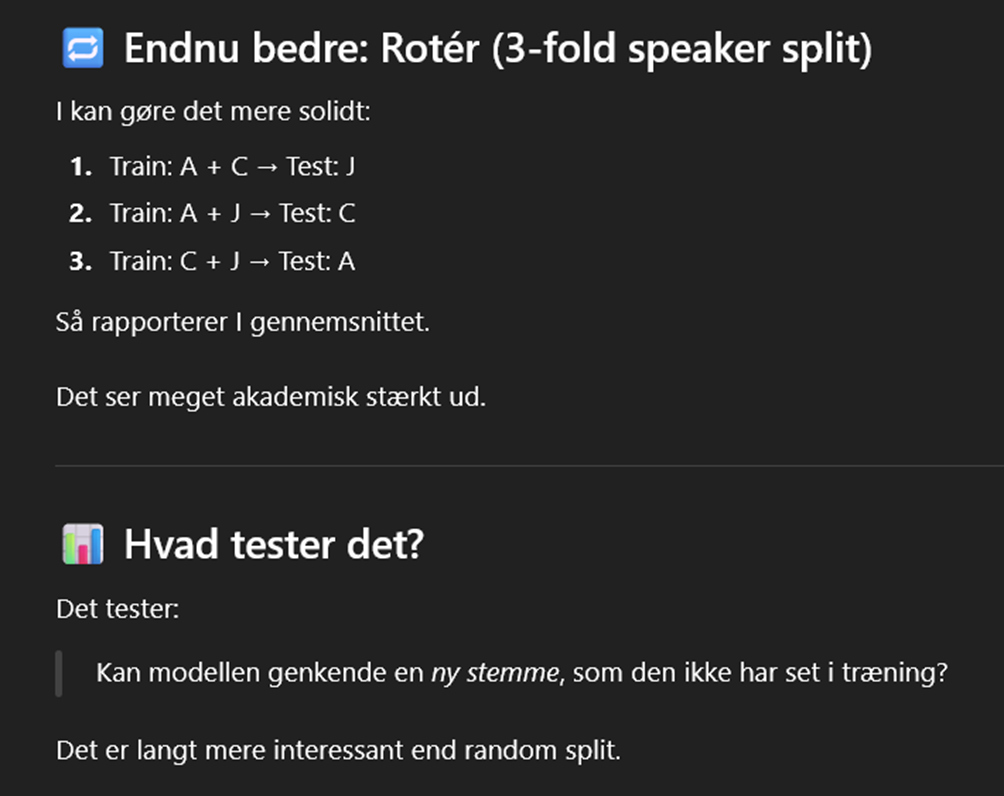

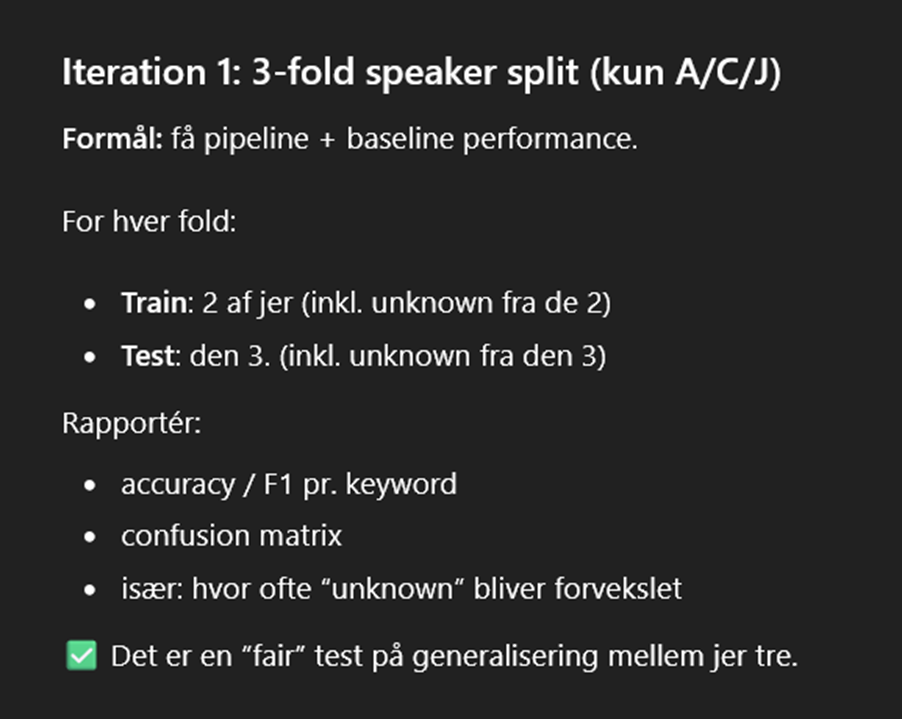

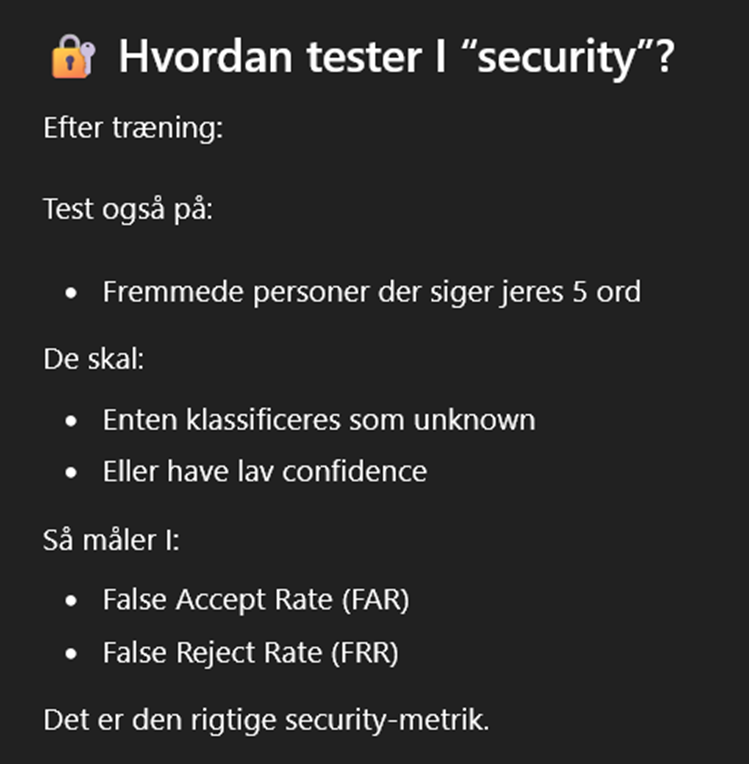

ELLER MÅSKE I STEDET MED EN ANDEN ACCENT I STEDET FOR ANDRE PERSONER, FORDI DET KAN VÆRE FOR BESVÆRLIGT. 

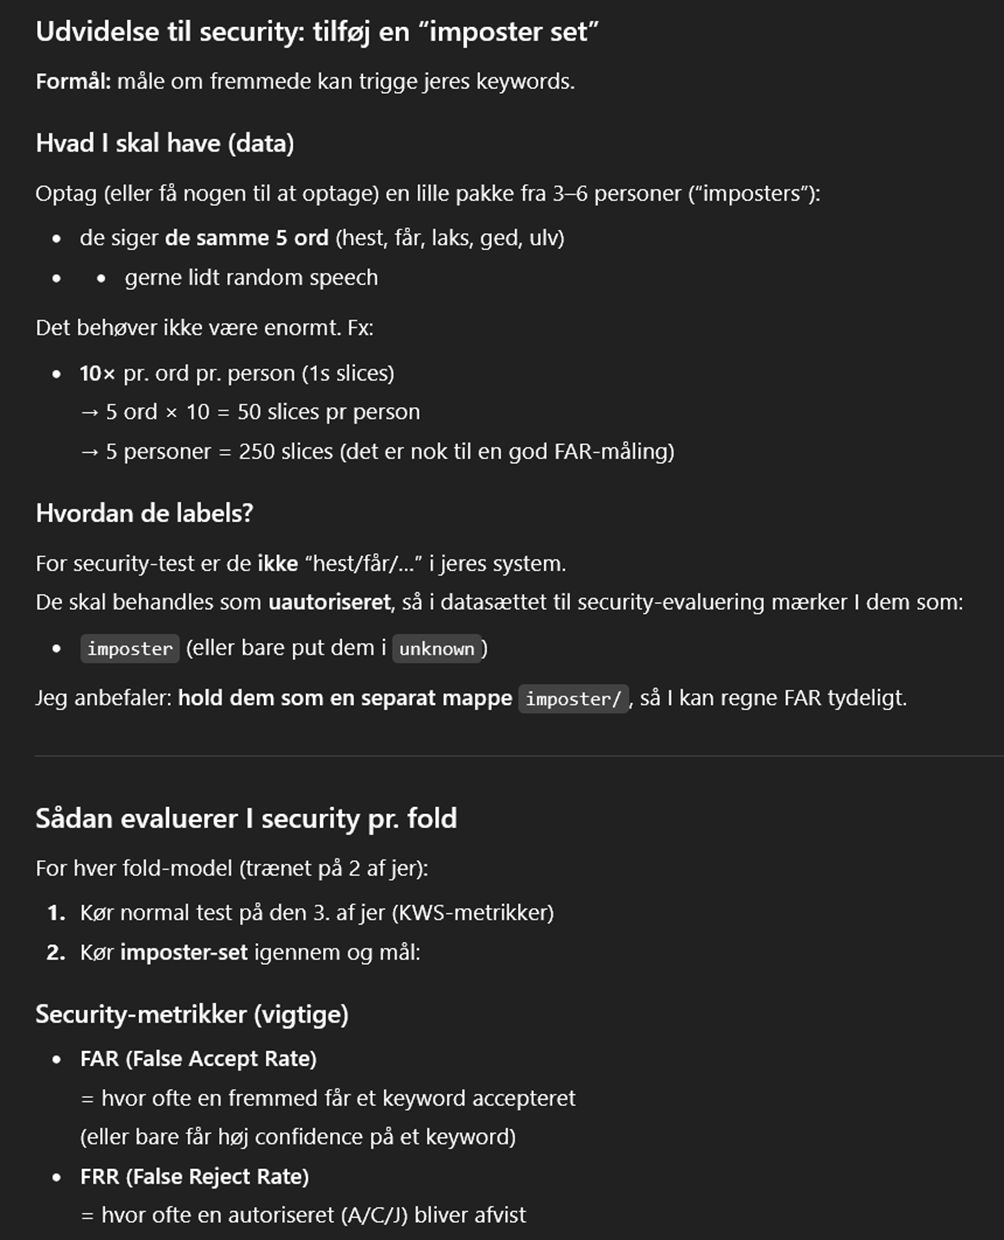


DERUDOVER HAR VI OGSÅ ANDRE TEST-SPLITS VI KAN LAVE: 
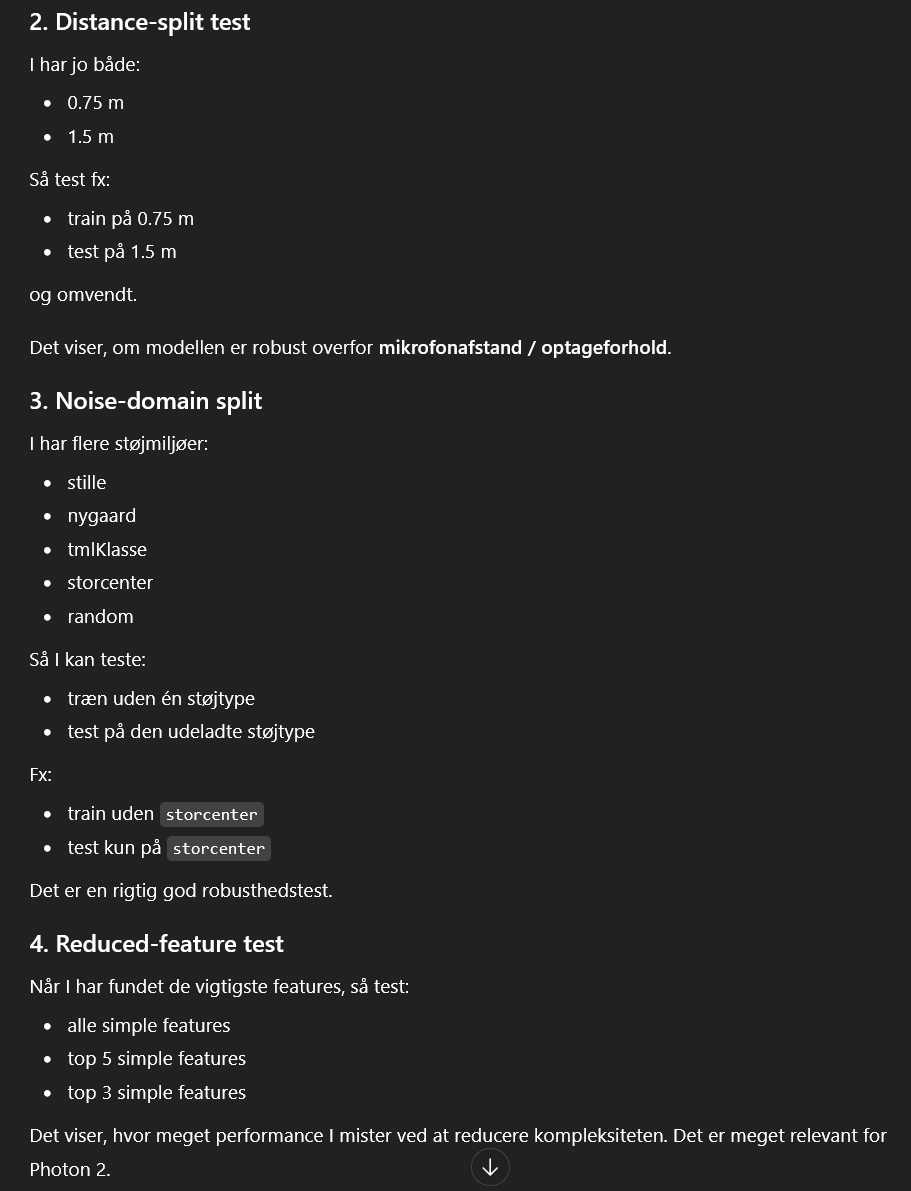

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# =========================
# SETTINGS
# =========================
TRAIN_KEYWORDS_DIR = Path("keywords_augmented")
TRAIN_UNKNOWN_DIR = Path("unknown_balanced")

TEST_DIR = Path("test_ready")

KEYWORD_LABELS = ["får", "ged", "hest", "laks", "ulv"]
ALL_LABELS = KEYWORD_LABELS + ["unknown"]

SAMPLE_RATE = 16000
N_MFCC = 13

# =========================
# AUDIO / FEATURE FUNCTIONS
# =========================
def load_wav(path: Path):
    x, fs = sf.read(str(path), always_2d=False)
    x = np.asarray(x, dtype=np.float32)

    if x.ndim > 1:
        x = x.mean(axis=1)

    if fs != SAMPLE_RATE:
        raise ValueError(f"Unexpected sample rate in {path}: {fs}")

    return x

def magnitude_spectrum(x, fs):
    window = np.hanning(len(x))
    xw = x * window
    spec = np.fft.rfft(xw)
    mag = np.abs(spec)
    freqs = np.fft.rfftfreq(len(xw), d=1 / fs)
    return freqs, mag

def rms_energy(x):
    return float(np.sqrt(np.mean(x ** 2) + 1e-12))

def zero_crossing_rate(x):
    return float(np.mean(np.signbit(x[1:]) != np.signbit(x[:-1])))

def spectral_centroid(x, fs):
    freqs, mag = magnitude_spectrum(x, fs)
    return float(np.sum(freqs * mag) / (np.sum(mag) + 1e-12))

def spectral_rolloff(x, fs, roll_percent=0.85):
    freqs, mag = magnitude_spectrum(x, fs)
    cumsum = np.cumsum(mag)
    threshold = roll_percent * cumsum[-1]
    idx = np.searchsorted(cumsum, threshold)
    return float(freqs[min(idx, len(freqs) - 1)])

def dominant_frequency(x, fs):
    freqs, mag = magnitude_spectrum(x, fs)
    idx = np.argmax(mag[1:]) + 1 if len(mag) > 1 else 0
    return float(freqs[idx])

def band_energy(x, fs, f_low, f_high):
    freqs, mag = magnitude_spectrum(x, fs)
    power = mag ** 2
    mask = (freqs >= f_low) & (freqs < f_high)
    return float(np.sum(power[mask]))

def mfcc_features(x, sr, n_mfcc=13):
    mfcc = librosa.feature.mfcc(
        y=x,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=1024,
        hop_length=512
    )
    return np.mean(mfcc, axis=1)

def extract_features(x, fs):
    record = {
        "rms": rms_energy(x),
        "zcr": zero_crossing_rate(x),
        "centroid": spectral_centroid(x, fs),
        "rolloff": spectral_rolloff(x, fs),
        "dominant_freq": dominant_frequency(x, fs),
        "band_0_500": band_energy(x, fs, 0, 500),
        "band_500_1500": band_energy(x, fs, 500, 1500),
        "band_1500_3000": band_energy(x, fs, 1500, 3000),
        "band_3000_6000": band_energy(x, fs, 3000, 6000),
    }

    mfcc_vals = mfcc_features(x, fs, n_mfcc=N_MFCC)
    for i, val in enumerate(mfcc_vals, start=1):
        record[f"mfcc_{i}"] = float(val)

    return record

# =========================
# FEATURE SETS
# =========================
simple_features = [
    "rms", "zcr", "centroid", "rolloff", "dominant_freq",
    "band_0_500", "band_500_1500", "band_1500_3000", "band_3000_6000"
]

mfcc_feature_cols = [f"mfcc_{i}" for i in range(1, N_MFCC + 1)]
all_features = simple_features + mfcc_feature_cols

# vælg features her
feature_cols = all_features
# feature_cols = simple_features
# feature_cols = mfcc_feature_cols

# =========================
# BUILD TRAIN FEATURE DATAFRAME
# =========================
train_records = []

for label in KEYWORD_LABELS:
    for wav_path in sorted((TRAIN_KEYWORDS_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        record = extract_features(x, SAMPLE_RATE)
        record["activity"] = label
        record["filename"] = wav_path.name
        train_records.append(record)

for wav_path in sorted(TRAIN_UNKNOWN_DIR.glob("*.wav")):
    x = load_wav(wav_path)
    record = extract_features(x, SAMPLE_RATE)
    record["activity"] = "unknown"
    record["filename"] = wav_path.name
    train_records.append(record)

train_df = pd.DataFrame(train_records)

# =========================
# BUILD TEST FEATURE DATAFRAME
# =========================
test_records = []

for label in ALL_LABELS:
    for wav_path in sorted((TEST_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        record = extract_features(x, SAMPLE_RATE)
        record["activity"] = label
        record["filename"] = wav_path.name
        test_records.append(record)

test_df = pd.DataFrame(test_records)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# =========================
# TRAIN ON TRAIN SET
# =========================
X_train = train_df[feature_cols]
y_train = train_df["activity"]

X_test = test_df[feature_cols]
y_test = test_df["activity"]

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

# =========================
# EVALUATE ON NEW RECORDINGS
# =========================
print("Test-on-new-recordings accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, labels=ALL_LABELS))

cm = confusion_matrix(y_test, y_pred, labels=ALL_LABELS)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=ALL_LABELS,
    yticklabels=ALL_LABELS
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest on NEW test recordings")
plt.show()

## BEMÆRK, AT TEST DATASÆTTET ER BASERET PÅ 126 SAMPLES, SOM VI HURTIGT OPTOG I TinyML KLASSELOKALET. 

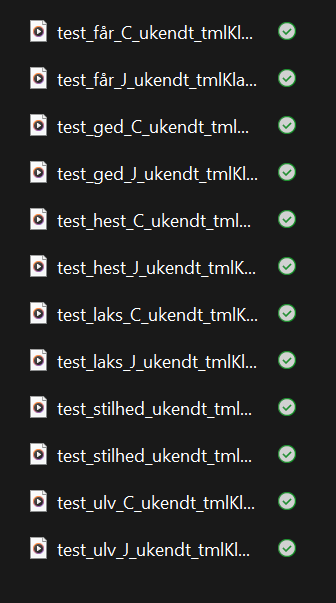

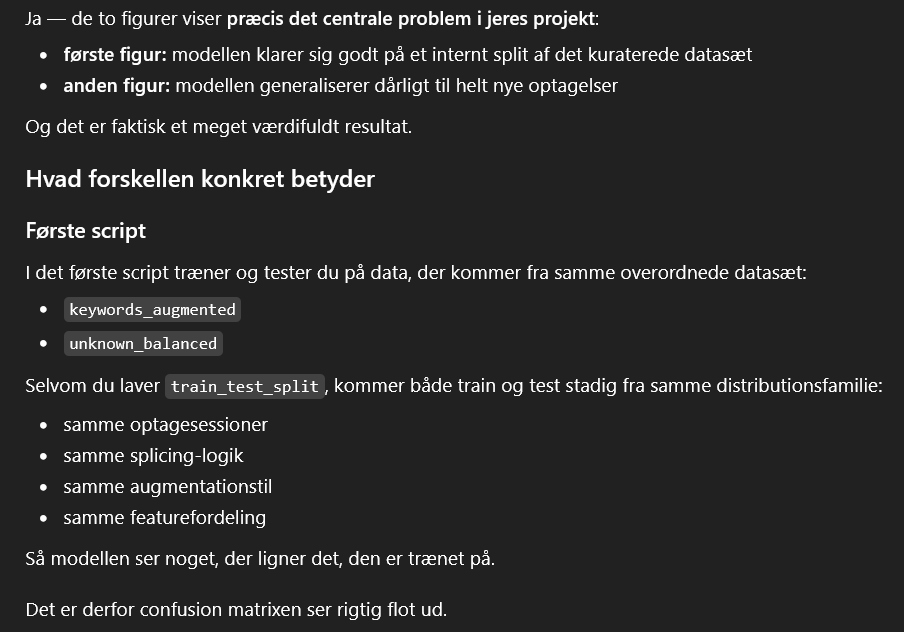

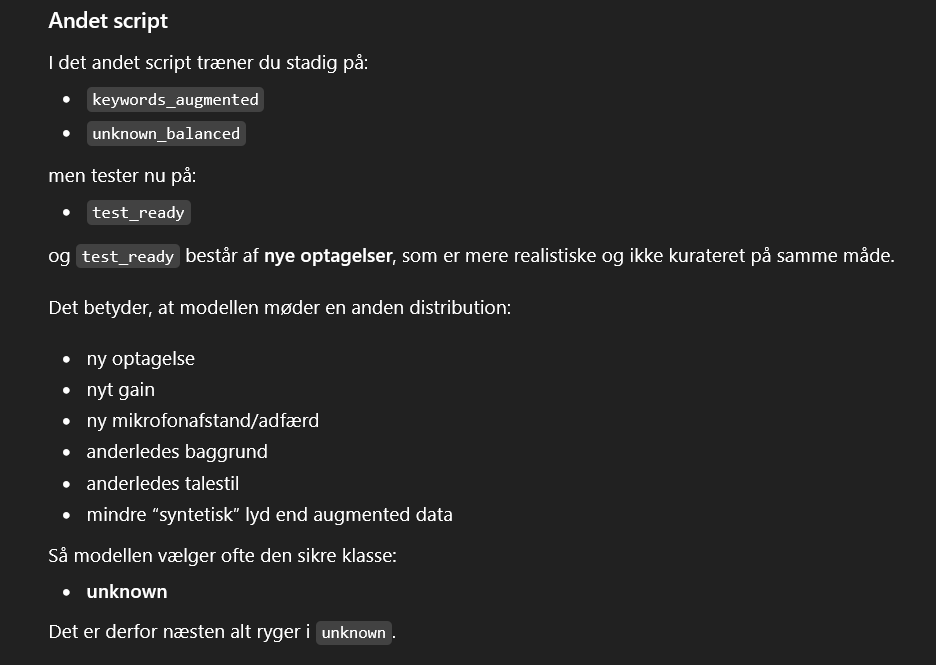

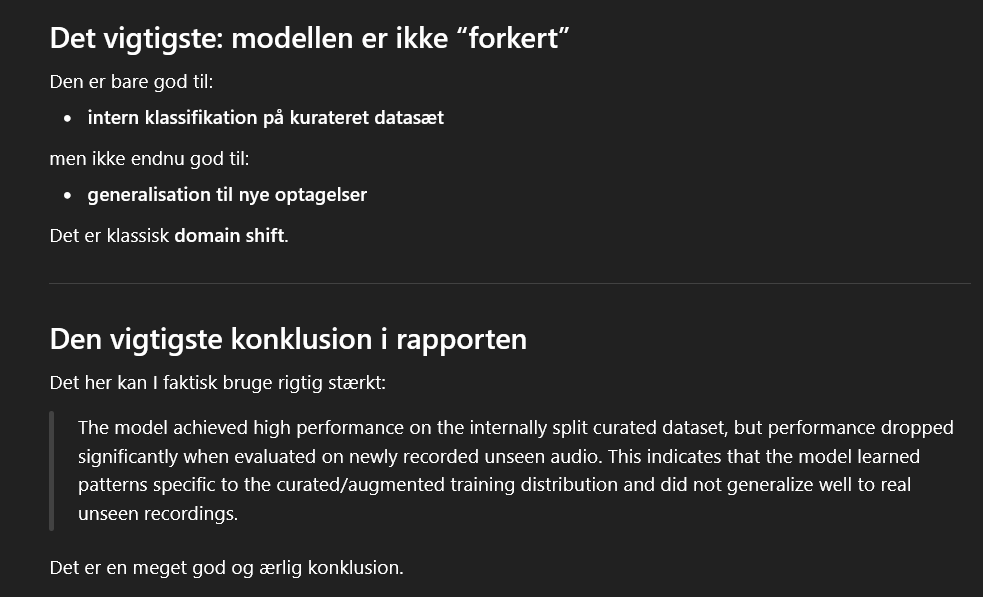

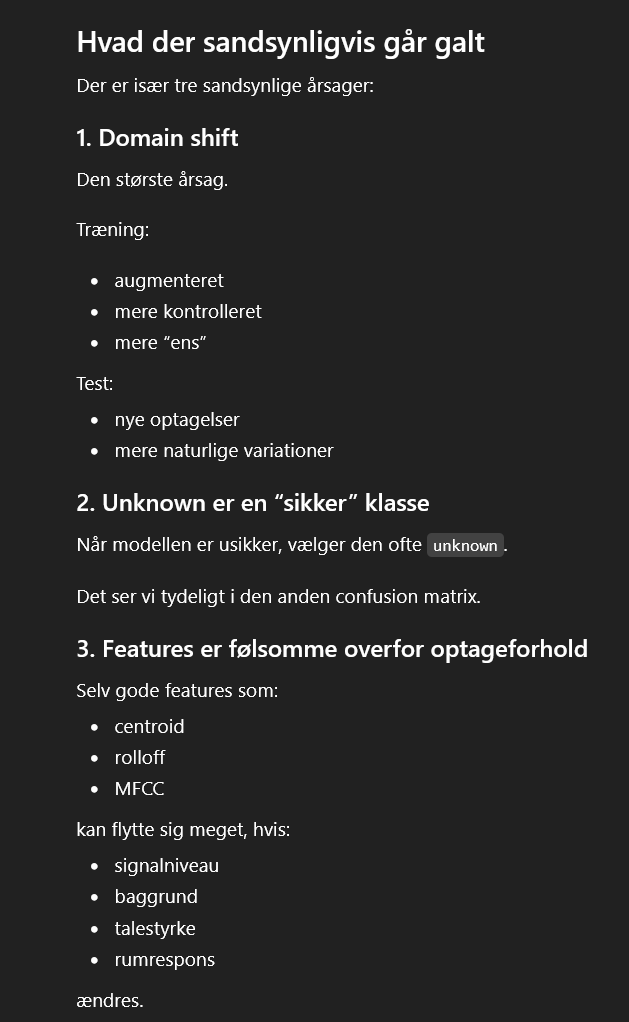

HVAD VI BØR GØRE FOR AT FIKSE PROBLEMET

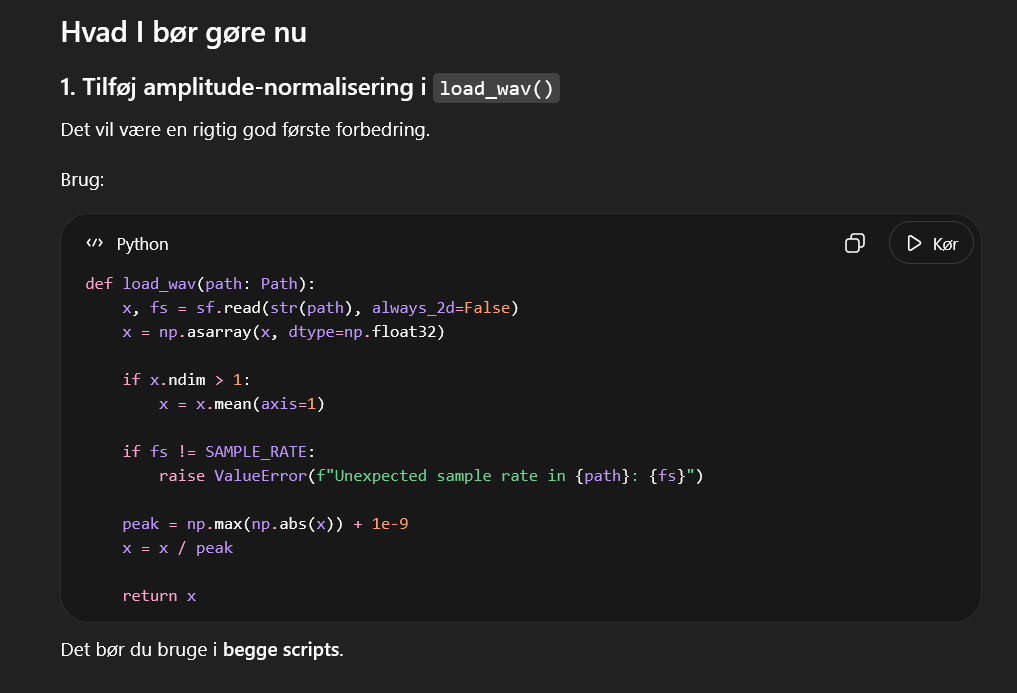

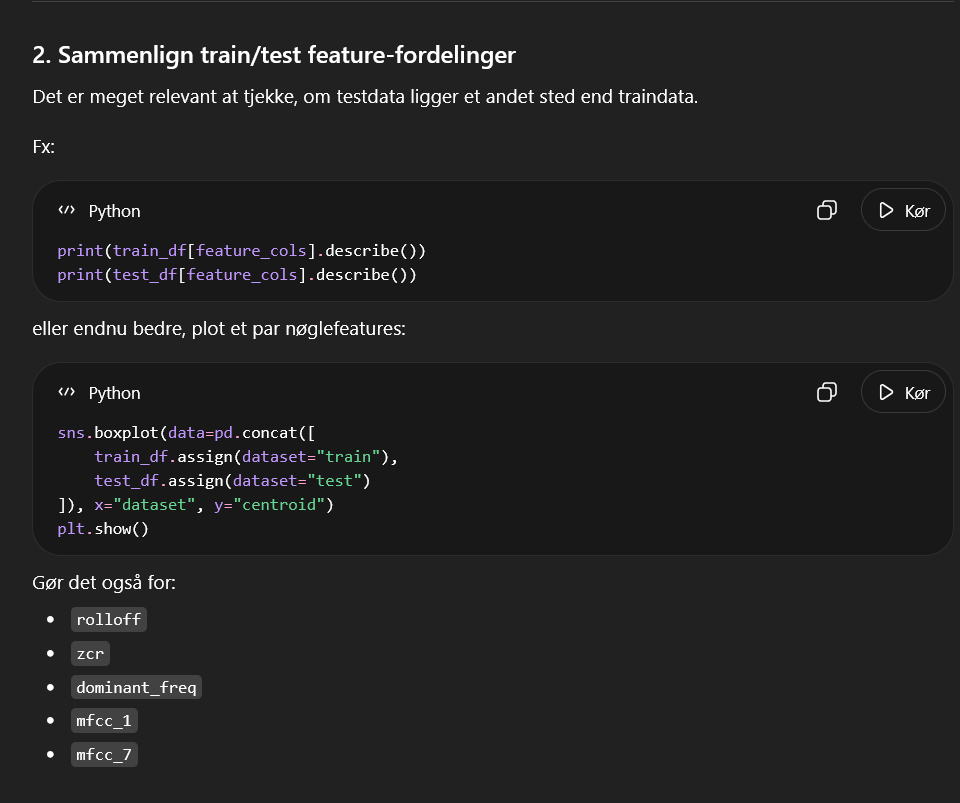

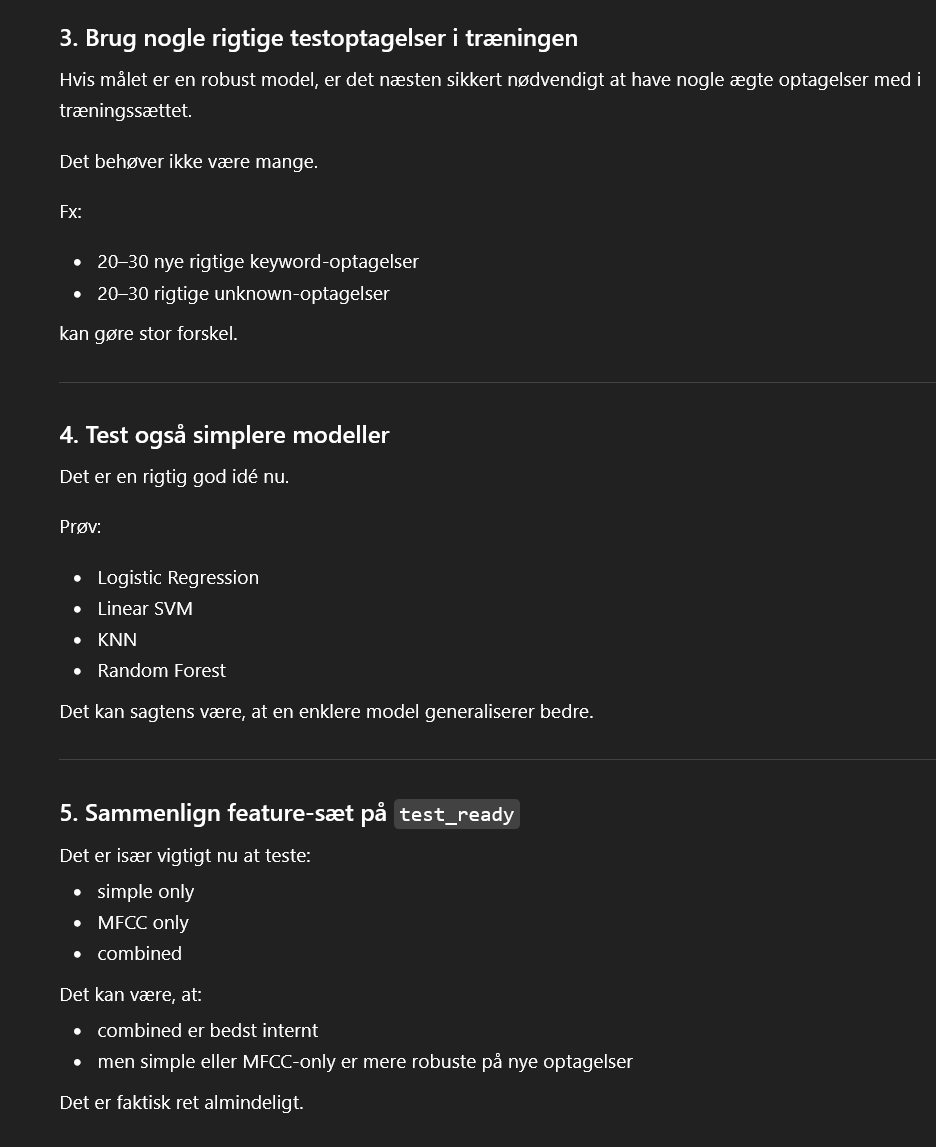

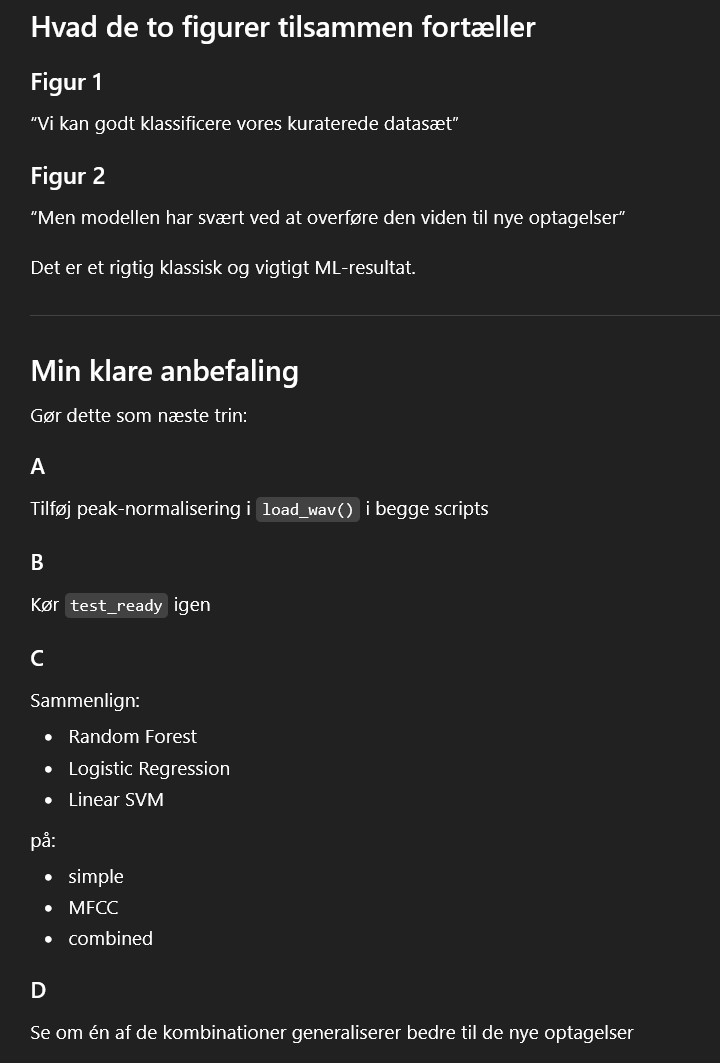

DET HER ER SKIDE GODT, FORDI AT NU DEMONSTRERER VI EN ITERATIV PROCES. 

ALTSÅ, NU KAN VI DOKUMENTERE AT NÅR VI LAVER INTERN EVALUERING AF MODEL (ALTSÅ TRAIN/TEST SPLIT ER FRA SAMME DATA + CURATION), SÅ LÆRERER MODELLEN ALT EFTER VORES SPLICING + BESTEMTE SNR NIVEAU, MM. 

MEN MODELLEN ER DÅRLIG TIL AT GENERALISERER FOR RIGTIG LYD, HVILKET SKYLDES DE IKKE RIGTIGE ARTIFAKTER, SOM DER KOMMER NÅR VI LAVER DATA CURATION FOR 2/3 af vores keywords. 

DERFOR BØR VI FØLGE NEDENSTÅENDE LØSNING:

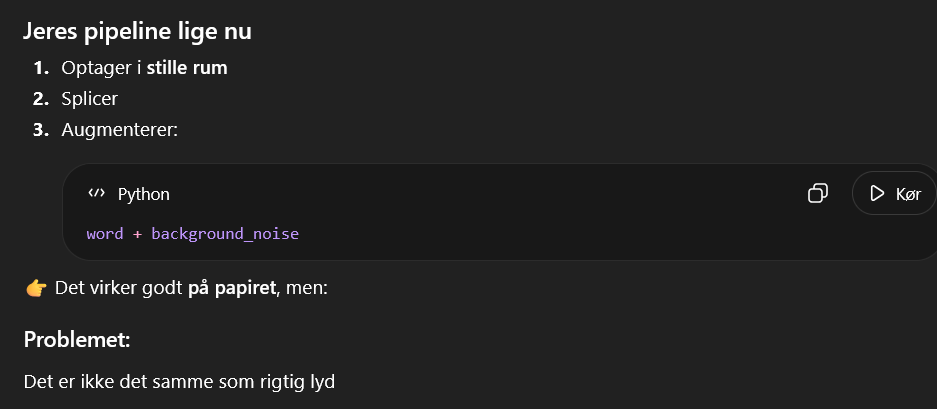

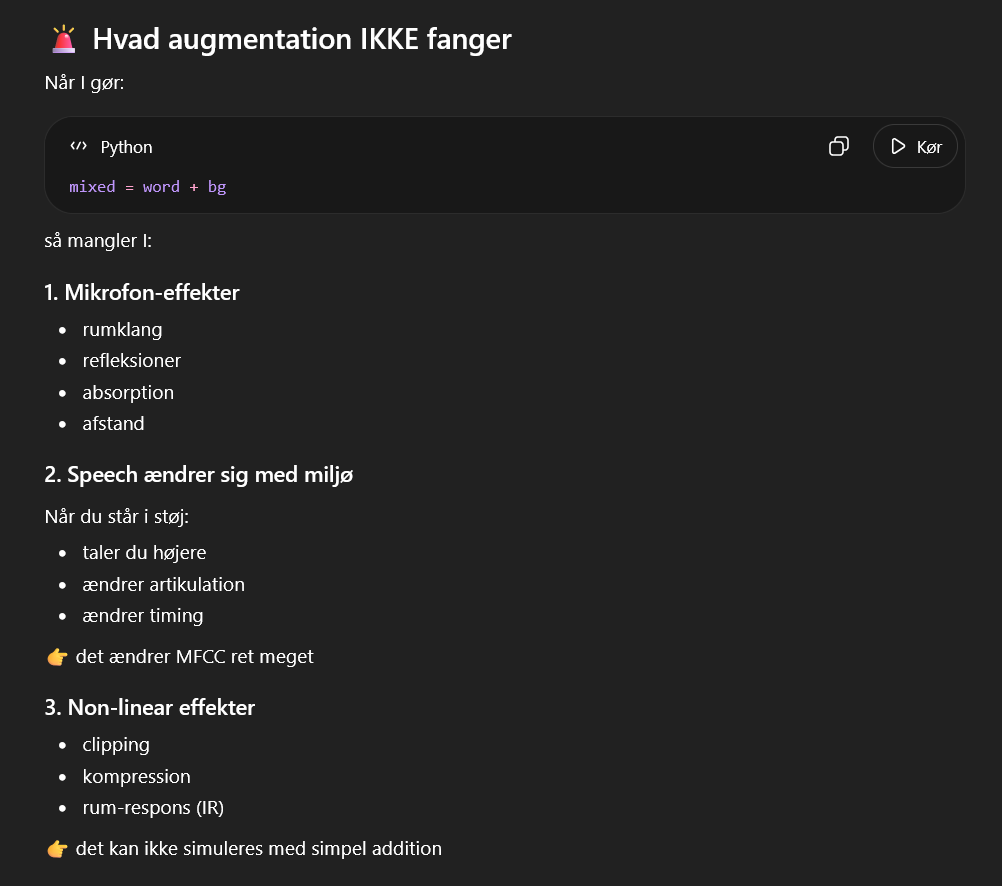

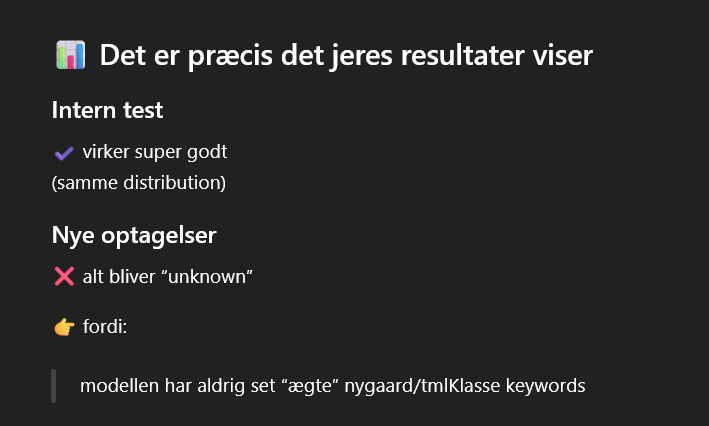

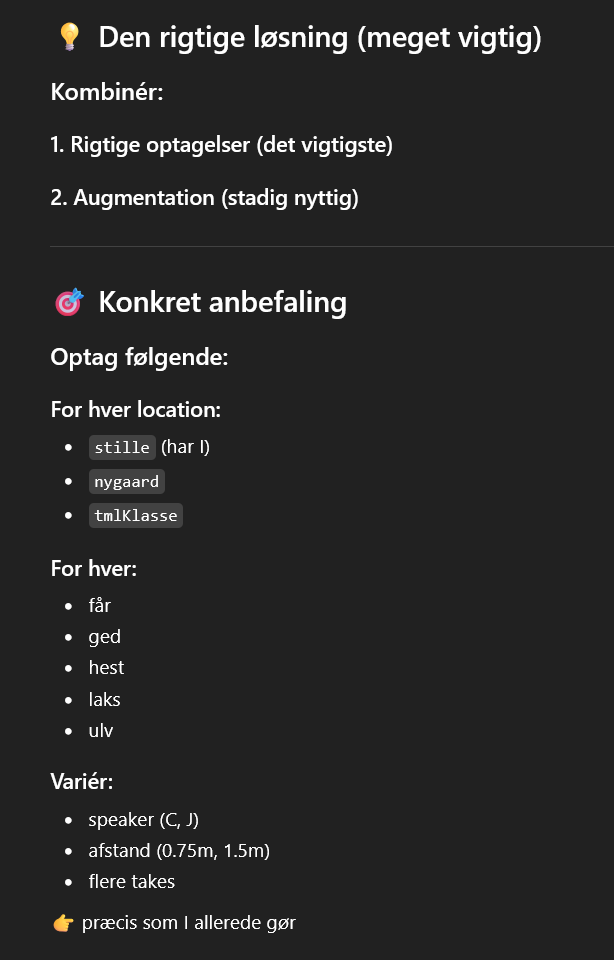

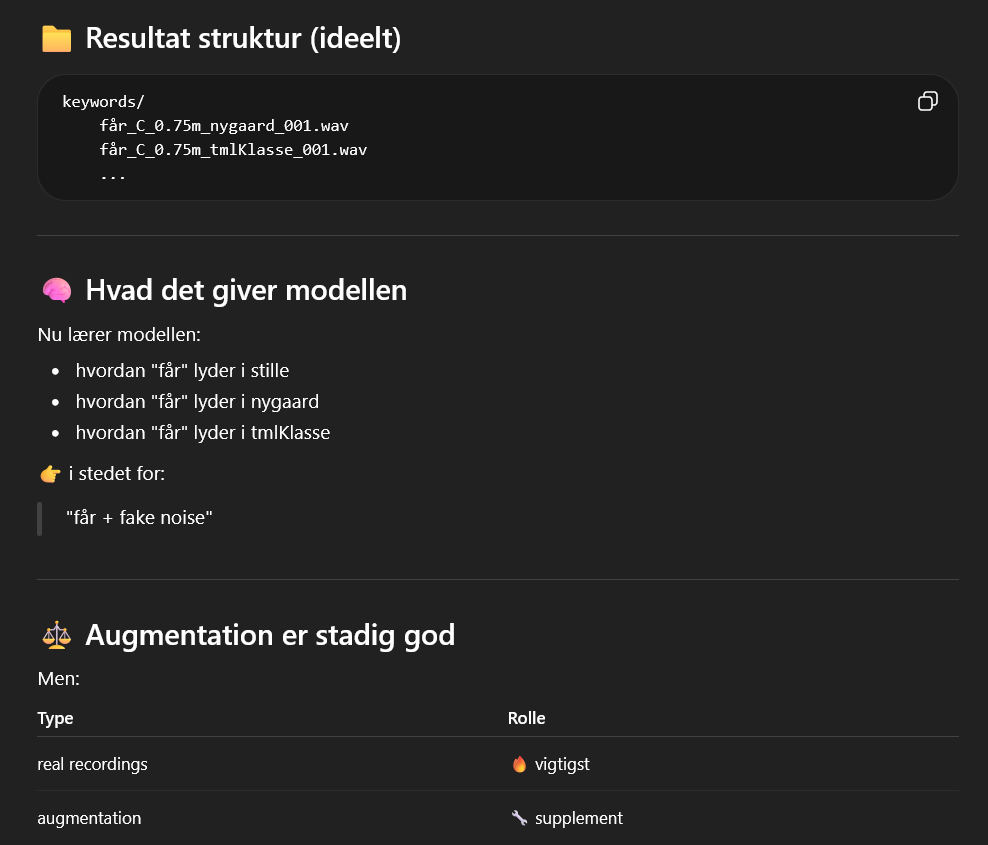

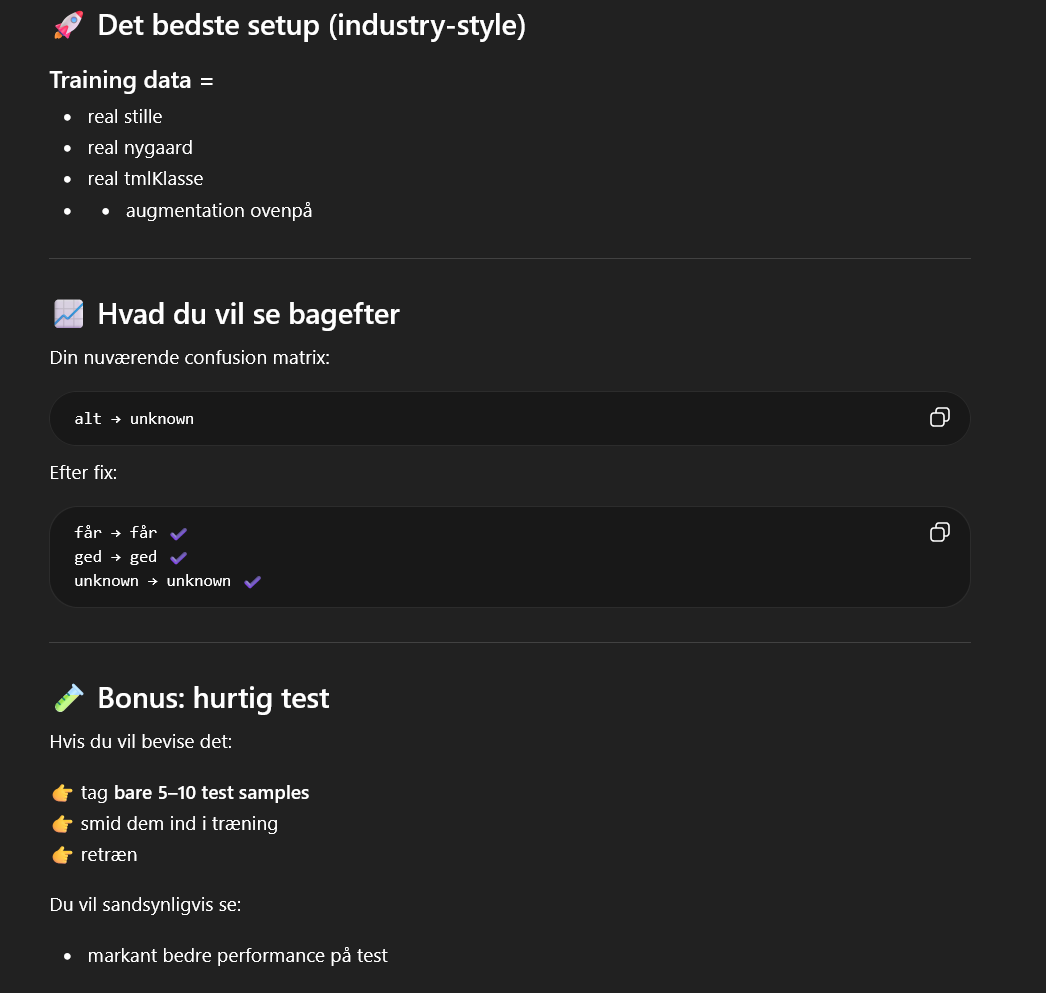

ALTSÅ VI VIL SKIFTE AUGMENTATION STRATEGI, TIL AT TILFØJE MINDRE VARIATIONER I VORES FORSKELLIGE MILJØER

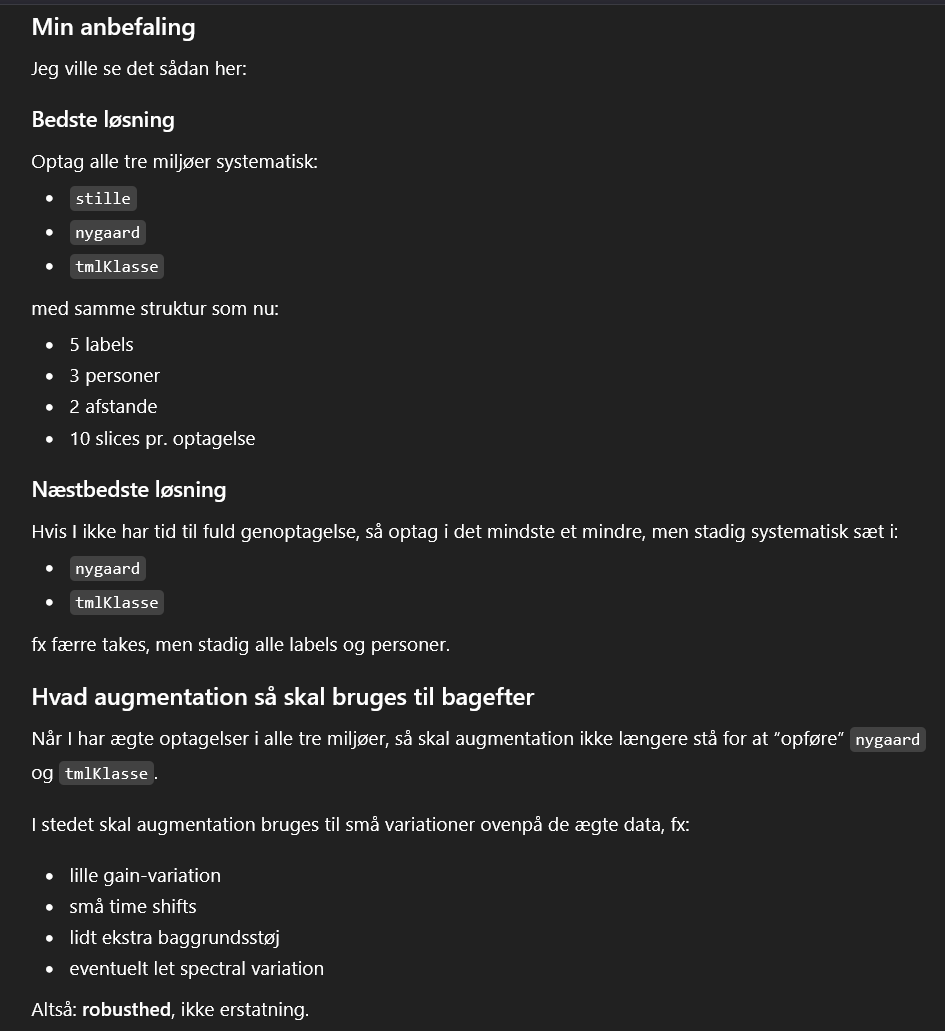

MEN PRØV FØRST AT GØR DET MAN KAN GØRE I PYTHON, FOR AT SE OM DET ER NOGET VI KAN LØSE UDEN AT SKULLE OPTAGE MERE

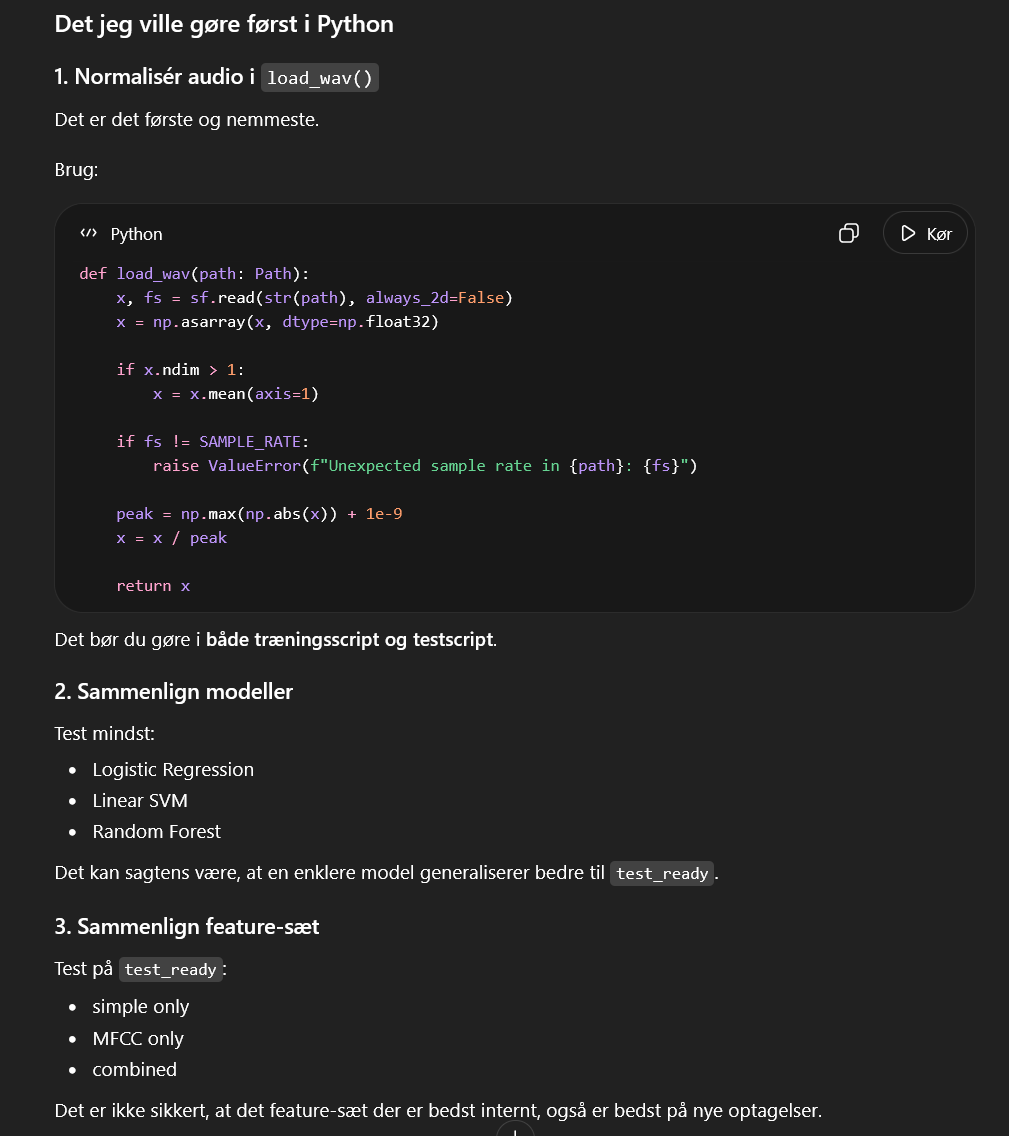

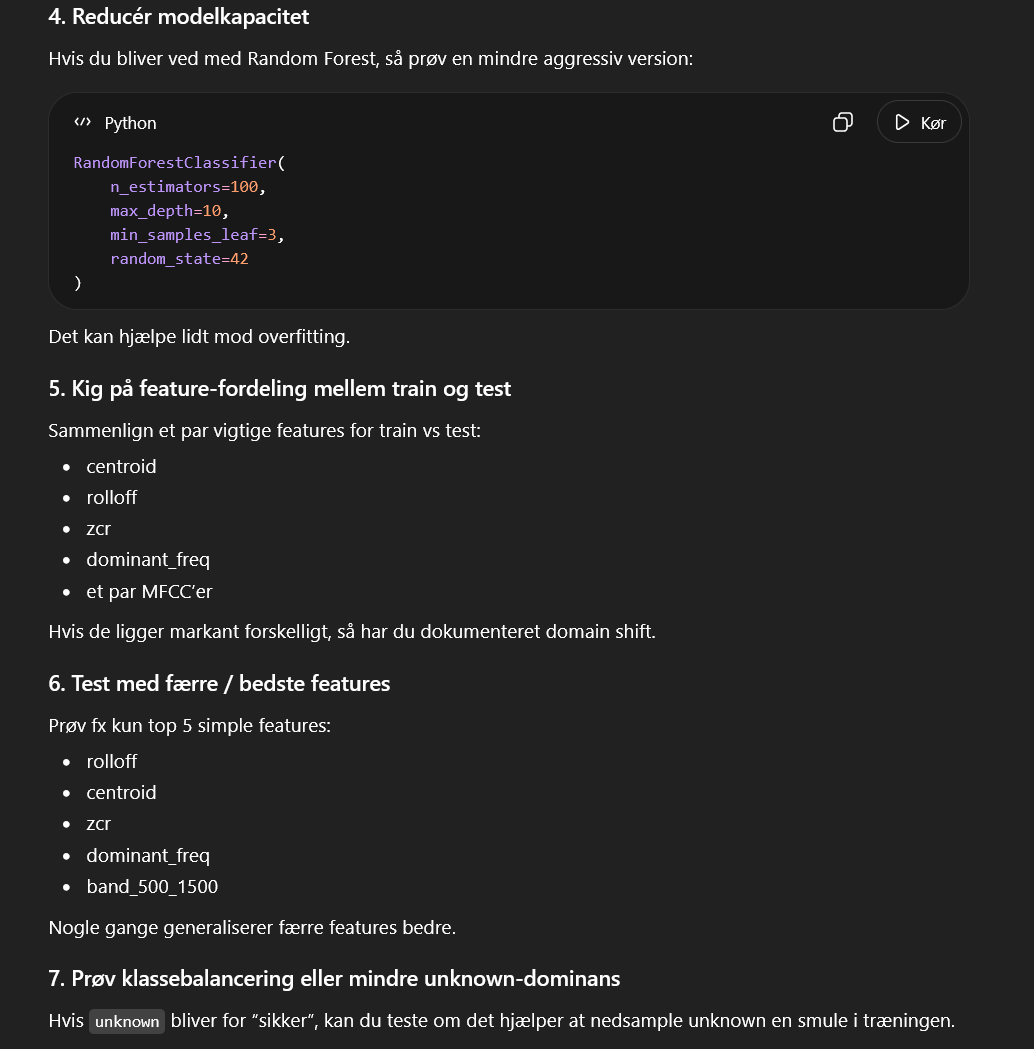

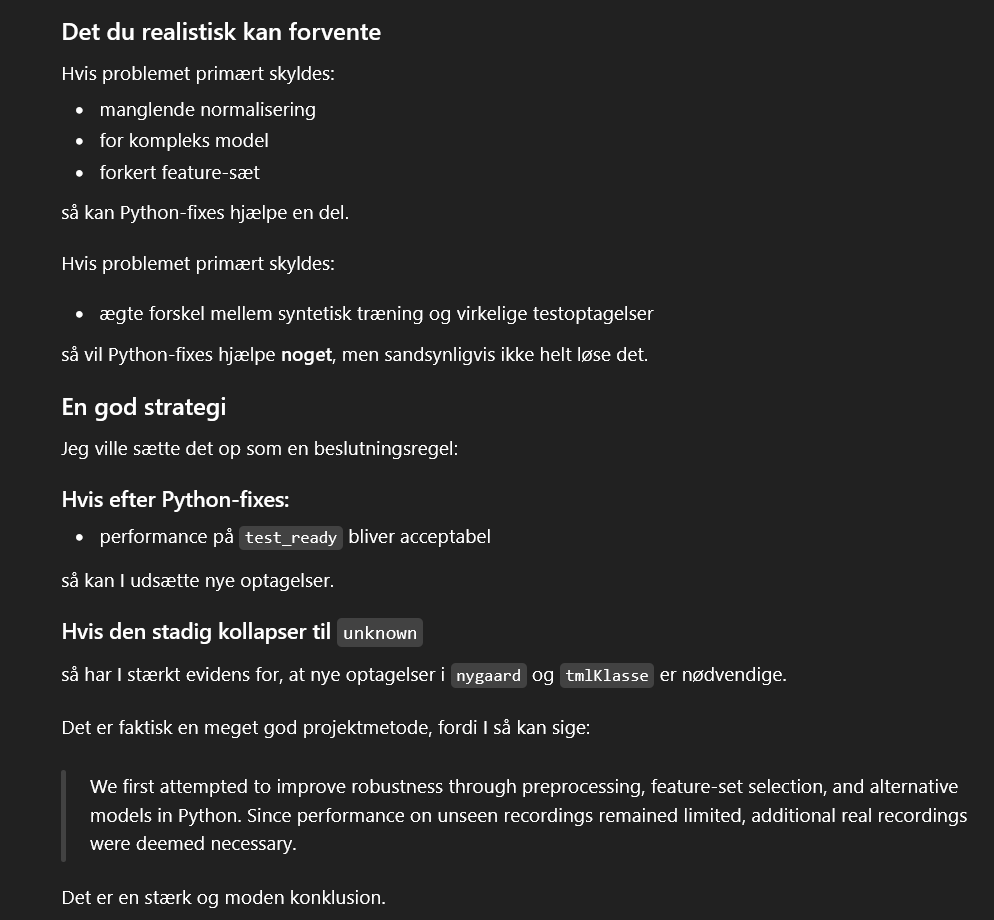

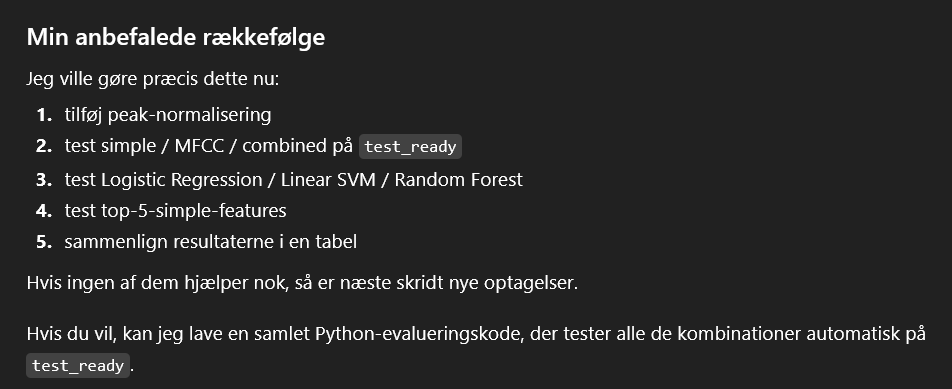

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# =========================
# SETTINGS
# =========================
TRAIN_KEYWORDS_DIR = Path("keywords_augmented")
TRAIN_UNKNOWN_DIR = Path("unknown_balanced")

TEST_DIR = Path("test_ready")

KEYWORD_LABELS = ["får", "ged", "hest", "laks", "ulv"]
ALL_LABELS = KEYWORD_LABELS + ["unknown"]

SAMPLE_RATE = 16000
N_MFCC = 13

# =========================
# AUDIO / FEATURE FUNCTIONS
# =========================
def load_wav(path: Path):
    x, fs = sf.read(str(path), always_2d=False)
    x = np.asarray(x, dtype=np.float32)

    if x.ndim > 1:
        x = x.mean(axis=1)

    if fs != SAMPLE_RATE:
        raise ValueError(f"Unexpected sample rate in {path}: {fs}")

    # 🔥 NYT: peak-normalisering
    peak = np.max(np.abs(x)) + 1e-9
    x = x / peak

    return x

def magnitude_spectrum(x, fs):
    window = np.hanning(len(x))
    xw = x * window
    spec = np.fft.rfft(xw)
    mag = np.abs(spec)
    freqs = np.fft.rfftfreq(len(xw), d=1 / fs)
    return freqs, mag

def rms_energy(x):
    return float(np.sqrt(np.mean(x ** 2) + 1e-12))

def zero_crossing_rate(x):
    return float(np.mean(np.signbit(x[1:]) != np.signbit(x[:-1])))

def spectral_centroid(x, fs):
    freqs, mag = magnitude_spectrum(x, fs)
    return float(np.sum(freqs * mag) / (np.sum(mag) + 1e-12))

def spectral_rolloff(x, fs, roll_percent=0.85):
    freqs, mag = magnitude_spectrum(x, fs)
    cumsum = np.cumsum(mag)
    threshold = roll_percent * cumsum[-1]
    idx = np.searchsorted(cumsum, threshold)
    return float(freqs[min(idx, len(freqs) - 1)])

def dominant_frequency(x, fs):
    freqs, mag = magnitude_spectrum(x, fs)
    idx = np.argmax(mag[1:]) + 1 if len(mag) > 1 else 0
    return float(freqs[idx])

def band_energy(x, fs, f_low, f_high):
    freqs, mag = magnitude_spectrum(x, fs)
    power = mag ** 2
    mask = (freqs >= f_low) & (freqs < f_high)
    return float(np.sum(power[mask]))

def mfcc_features(x, sr, n_mfcc=13):
    mfcc = librosa.feature.mfcc(
        y=x,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=1024,
        hop_length=512
    )
    return np.mean(mfcc, axis=1)

def extract_features(x, fs):
    record = {
        "rms": rms_energy(x),
        "zcr": zero_crossing_rate(x),
        "centroid": spectral_centroid(x, fs),
        "rolloff": spectral_rolloff(x, fs),
        "dominant_freq": dominant_frequency(x, fs),
        "band_0_500": band_energy(x, fs, 0, 500),
        "band_500_1500": band_energy(x, fs, 500, 1500),
        "band_1500_3000": band_energy(x, fs, 1500, 3000),
        "band_3000_6000": band_energy(x, fs, 3000, 6000),
    }

    mfcc_vals = mfcc_features(x, fs, n_mfcc=N_MFCC)
    for i, val in enumerate(mfcc_vals, start=1):
        record[f"mfcc_{i}"] = float(val)

    return record

# =========================
# FEATURE SETS
# =========================
simple_features = [
    "rms", "zcr", "centroid", "rolloff", "dominant_freq",
    "band_0_500", "band_500_1500", "band_1500_3000", "band_3000_6000"
]

mfcc_feature_cols = [f"mfcc_{i}" for i in range(1, N_MFCC + 1)]
all_features = simple_features + mfcc_feature_cols

# vælg features her
feature_cols = all_features
# feature_cols = simple_features
# feature_cols = mfcc_feature_cols

# =========================
# BUILD TRAIN FEATURE DATAFRAME
# =========================
train_records = []

for label in KEYWORD_LABELS:
    for wav_path in sorted((TRAIN_KEYWORDS_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        record = extract_features(x, SAMPLE_RATE)
        record["activity"] = label
        record["filename"] = wav_path.name
        train_records.append(record)

for wav_path in sorted(TRAIN_UNKNOWN_DIR.glob("*.wav")):
    x = load_wav(wav_path)
    record = extract_features(x, SAMPLE_RATE)
    record["activity"] = "unknown"
    record["filename"] = wav_path.name
    train_records.append(record)

train_df = pd.DataFrame(train_records)

# =========================
# BUILD TEST FEATURE DATAFRAME
# =========================
test_records = []

for label in ALL_LABELS:
    for wav_path in sorted((TEST_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        record = extract_features(x, SAMPLE_RATE)
        record["activity"] = label
        record["filename"] = wav_path.name
        test_records.append(record)

test_df = pd.DataFrame(test_records)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# =========================
# TRAIN ON TRAIN SET
# =========================
from sklearn.preprocessing import StandardScaler

X_train = train_df[feature_cols].values
y_train = train_df["activity"]

X_test = test_df[feature_cols].values
y_test = test_df["activity"]

# 🔥 Fit scaler KUN på train
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

# 🔥 Brug samme scaler på test
X_test = scaler.transform(X_test)

#clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

# =========================
# EVALUATE ON NEW RECORDINGS
# =========================
print("Test-on-new-recordings accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, labels=ALL_LABELS))

cm = confusion_matrix(y_test, y_pred, labels=ALL_LABELS)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=ALL_LABELS,
    yticklabels=ALL_LABELS
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest on NEW test recordings")
plt.show()

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import soundfile as sf
import librosa

from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# =========================
# SETTINGS
# =========================
TRAIN_KEYWORDS_DIR = Path("keywords_augmented")
TRAIN_UNKNOWN_DIR = Path("unknown_balanced")
TEST_DIR = Path("test_ready")

KEYWORD_LABELS = ["får", "ged", "hest", "laks", "ulv"]
ALL_LABELS = KEYWORD_LABELS + ["unknown"]

SAMPLE_RATE = 16000
N_MFCC = 13

# =========================
# AUDIO / FEATURE FUNCTIONS
# =========================
def load_wav(path: Path):
    x, fs = sf.read(str(path), always_2d=False)
    x = np.asarray(x, dtype=np.float32)

    if x.ndim > 1:
        x = x.mean(axis=1)

    if fs != SAMPLE_RATE:
        raise ValueError(f"Unexpected sample rate in {path}: {fs}")

    peak = np.max(np.abs(x)) + 1e-9
    x = x / peak

    return x

def magnitude_spectrum(x, fs):
    window = np.hanning(len(x))
    xw = x * window
    spec = np.fft.rfft(xw)
    mag = np.abs(spec)
    freqs = np.fft.rfftfreq(len(xw), d=1 / fs)
    return freqs, mag

def rms_energy(x):
    return float(np.sqrt(np.mean(x ** 2) + 1e-12))

def zero_crossing_rate(x):
    return float(np.mean(np.signbit(x[1:]) != np.signbit(x[:-1])))

def spectral_centroid(x, fs):
    freqs, mag = magnitude_spectrum(x, fs)
    return float(np.sum(freqs * mag) / (np.sum(mag) + 1e-12))

def spectral_rolloff(x, fs, roll_percent=0.85):
    freqs, mag = magnitude_spectrum(x, fs)
    cumsum = np.cumsum(mag)
    threshold = roll_percent * cumsum[-1]
    idx = np.searchsorted(cumsum, threshold)
    return float(freqs[min(idx, len(freqs) - 1)])

def dominant_frequency(x, fs):
    freqs, mag = magnitude_spectrum(x, fs)
    idx = np.argmax(mag[1:]) + 1 if len(mag) > 1 else 0
    return float(freqs[idx])

def band_energy(x, fs, f_low, f_high):
    freqs, mag = magnitude_spectrum(x, fs)
    power = mag ** 2
    mask = (freqs >= f_low) & (freqs < f_high)
    return float(np.sum(power[mask]))

def mfcc_features(x, sr, n_mfcc=13):
    mfcc = librosa.feature.mfcc(
        y=x,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=1024,
        hop_length=512
    )
    return np.mean(mfcc, axis=1)

def extract_features(x, fs):
    record = {
        "rms": rms_energy(x),
        "zcr": zero_crossing_rate(x),
        "centroid": spectral_centroid(x, fs),
        "rolloff": spectral_rolloff(x, fs),
        "dominant_freq": dominant_frequency(x, fs),
        "band_0_500": band_energy(x, fs, 0, 500),
        "band_500_1500": band_energy(x, fs, 500, 1500),
        "band_1500_3000": band_energy(x, fs, 1500, 3000),
        "band_3000_6000": band_energy(x, fs, 3000, 6000),
    }

    mfcc_vals = mfcc_features(x, fs, n_mfcc=N_MFCC)
    for i, val in enumerate(mfcc_vals, start=1):
        record[f"mfcc_{i}"] = float(val)

    return record

# =========================
# BUILD DATAFRAMES
# =========================
train_records = []

for label in KEYWORD_LABELS:
    for wav_path in sorted((TRAIN_KEYWORDS_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        record = extract_features(x, SAMPLE_RATE)
        record["activity"] = label
        train_records.append(record)

for wav_path in sorted(TRAIN_UNKNOWN_DIR.glob("*.wav")):
    x = load_wav(wav_path)
    record = extract_features(x, SAMPLE_RATE)
    record["activity"] = "unknown"
    train_records.append(record)

train_df = pd.DataFrame(train_records)

test_records = []

for label in ALL_LABELS:
    for wav_path in sorted((TEST_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        record = extract_features(x, SAMPLE_RATE)
        record["activity"] = label
        test_records.append(record)

test_df = pd.DataFrame(test_records)

simple_features = [
    "rms", "zcr", "centroid", "rolloff", "dominant_freq",
    "band_0_500", "band_500_1500", "band_1500_3000", "band_3000_6000"
]
mfcc_feature_cols = [f"mfcc_{i}" for i in range(1, N_MFCC + 1)]
all_features = simple_features + mfcc_feature_cols

feature_sets = {
    "simple": simple_features,
    "mfcc": mfcc_feature_cols,
    "combined": all_features,
}

models = {
    "LogisticRegression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=3000)
    ),
    "LinearSVM": make_pipeline(
        StandardScaler(),
        LinearSVC()
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=3,
        random_state=42
    ),
}

results = []

for feat_name, feat_cols in feature_sets.items():
    X_train = train_df[feat_cols]
    y_train = train_df["activity"]

    X_test = test_df[feat_cols]
    y_test = test_df["activity"]

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        results.append({
            "model": model_name,
            "features": feat_name,
            "accuracy": acc
        })

        print(f"\nModel: {model_name}, Features: {feat_name}")
        print("Accuracy:", acc)
        print(classification_report(y_test, y_pred, labels=ALL_LABELS))

        # 🔥 NYT: Confusion Matrix Plot
        cm = confusion_matrix(y_test, y_pred, labels=ALL_LABELS)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=ALL_LABELS
        )

        fig, ax = plt.subplots(figsize=(6, 5))
        disp.plot(ax=ax, cmap="magma", values_format="d")
        plt.title(f"{model_name} ({feat_name})")
        plt.tight_layout()
        plt.show()

results_df = pd.DataFrame(results)
print("\nSummary:")
print(results_df.sort_values("accuracy", ascending=False))

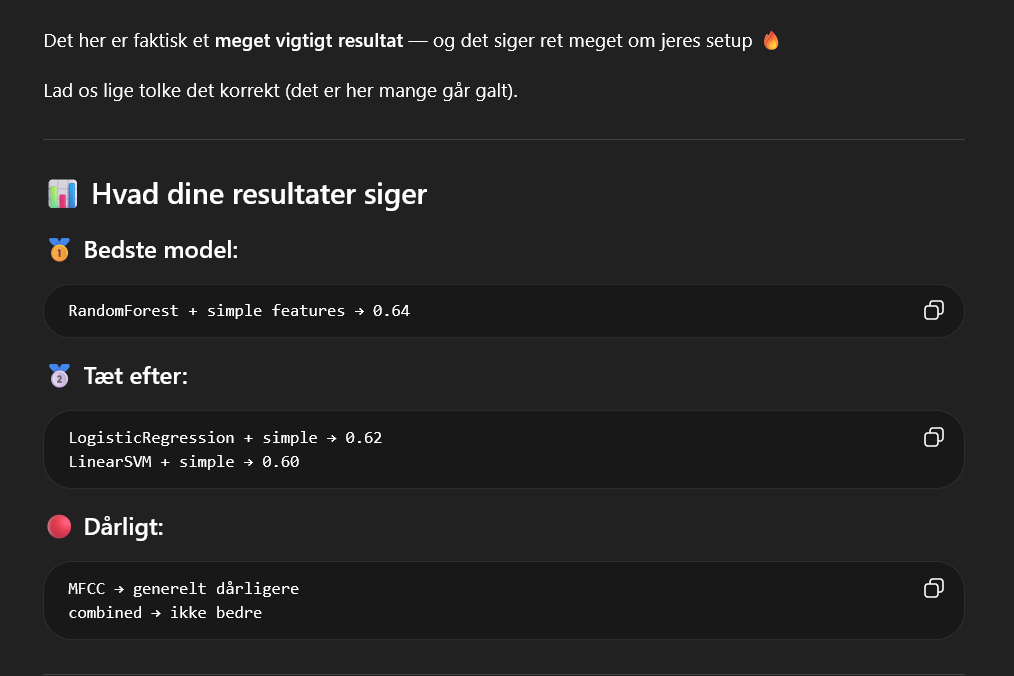

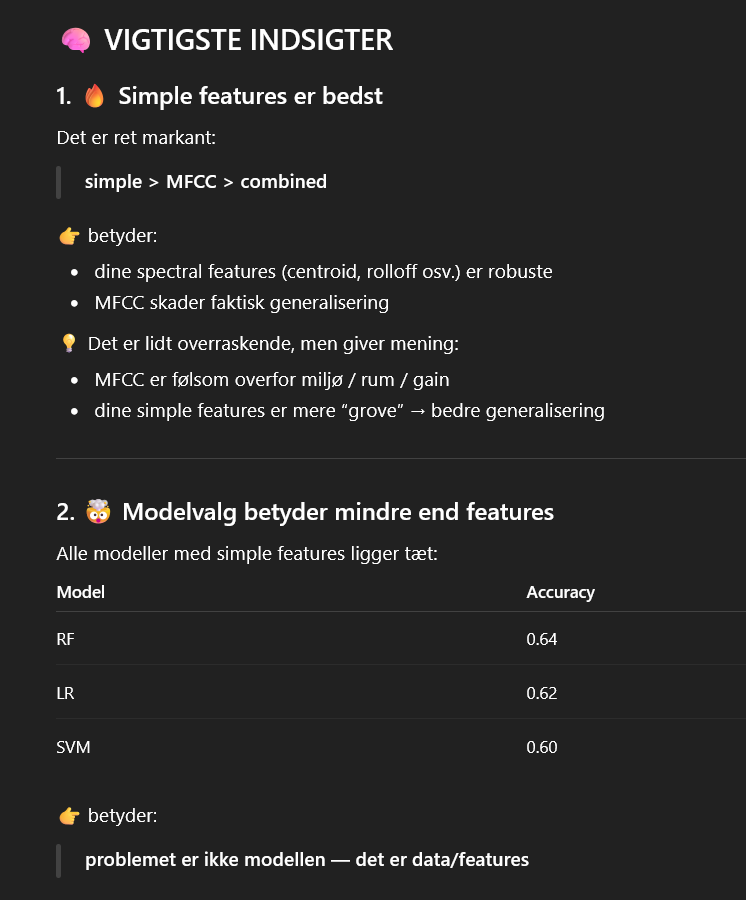

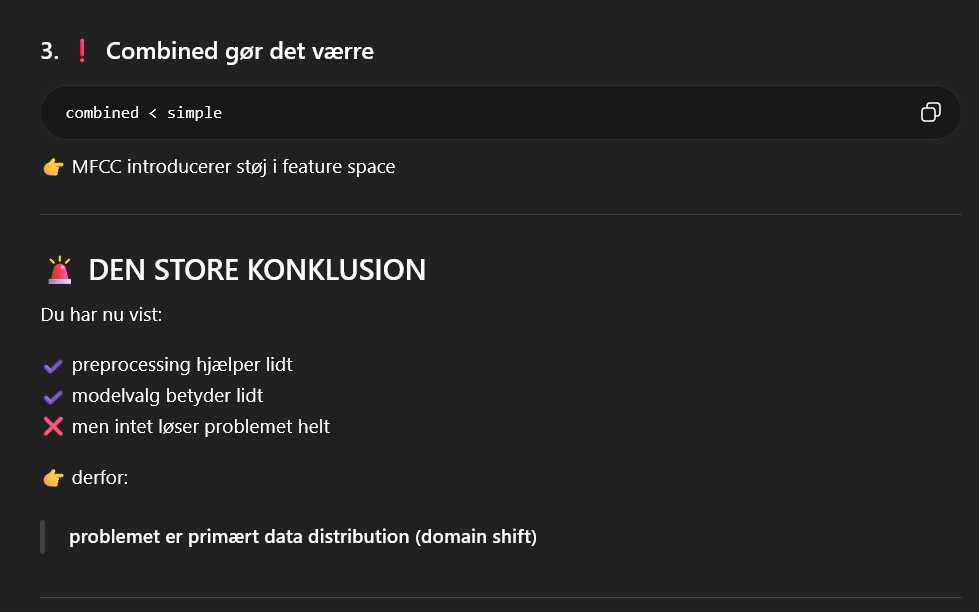

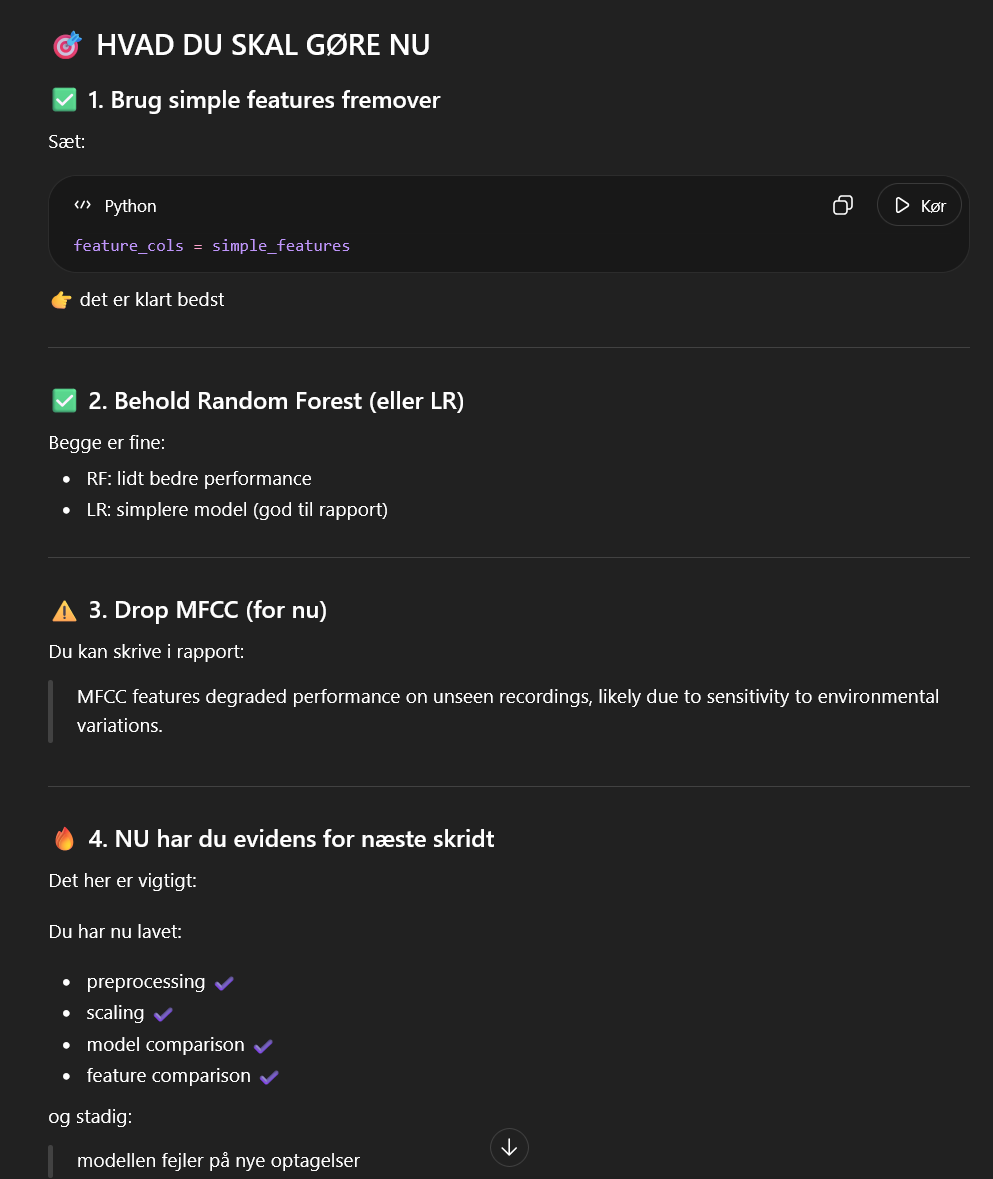



Måske skal vores model blot være robust for to forskellige støjniveauer (stille og tmlKlasse/Nygaard/Shannon)

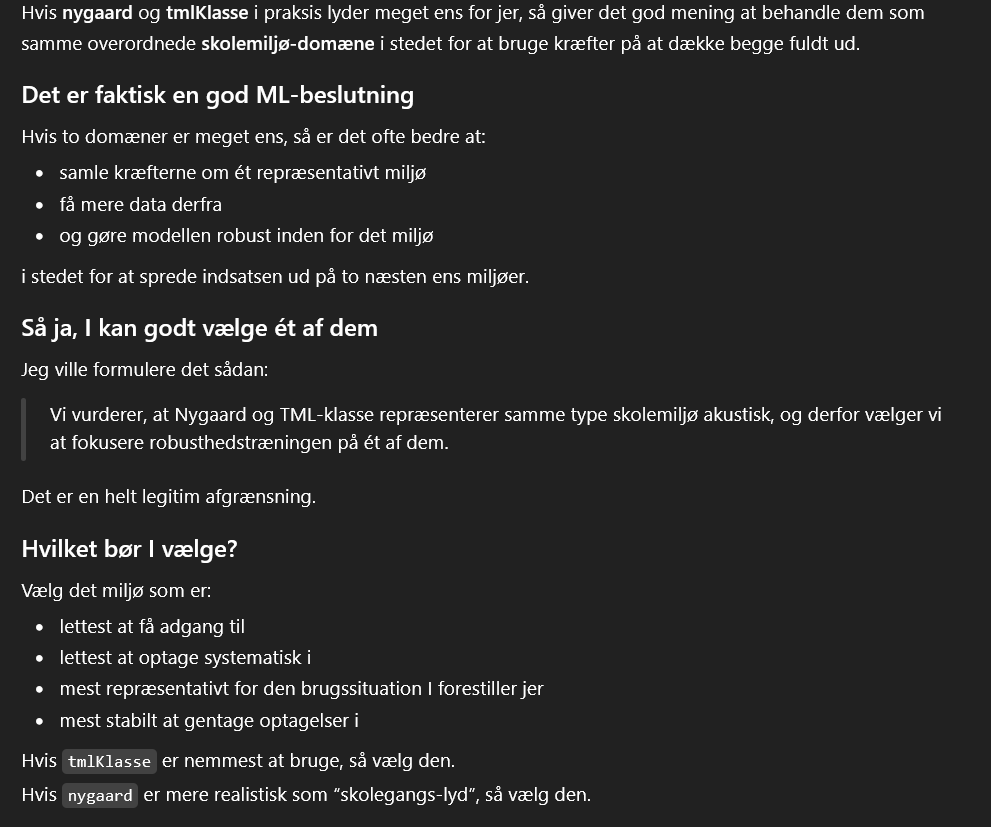



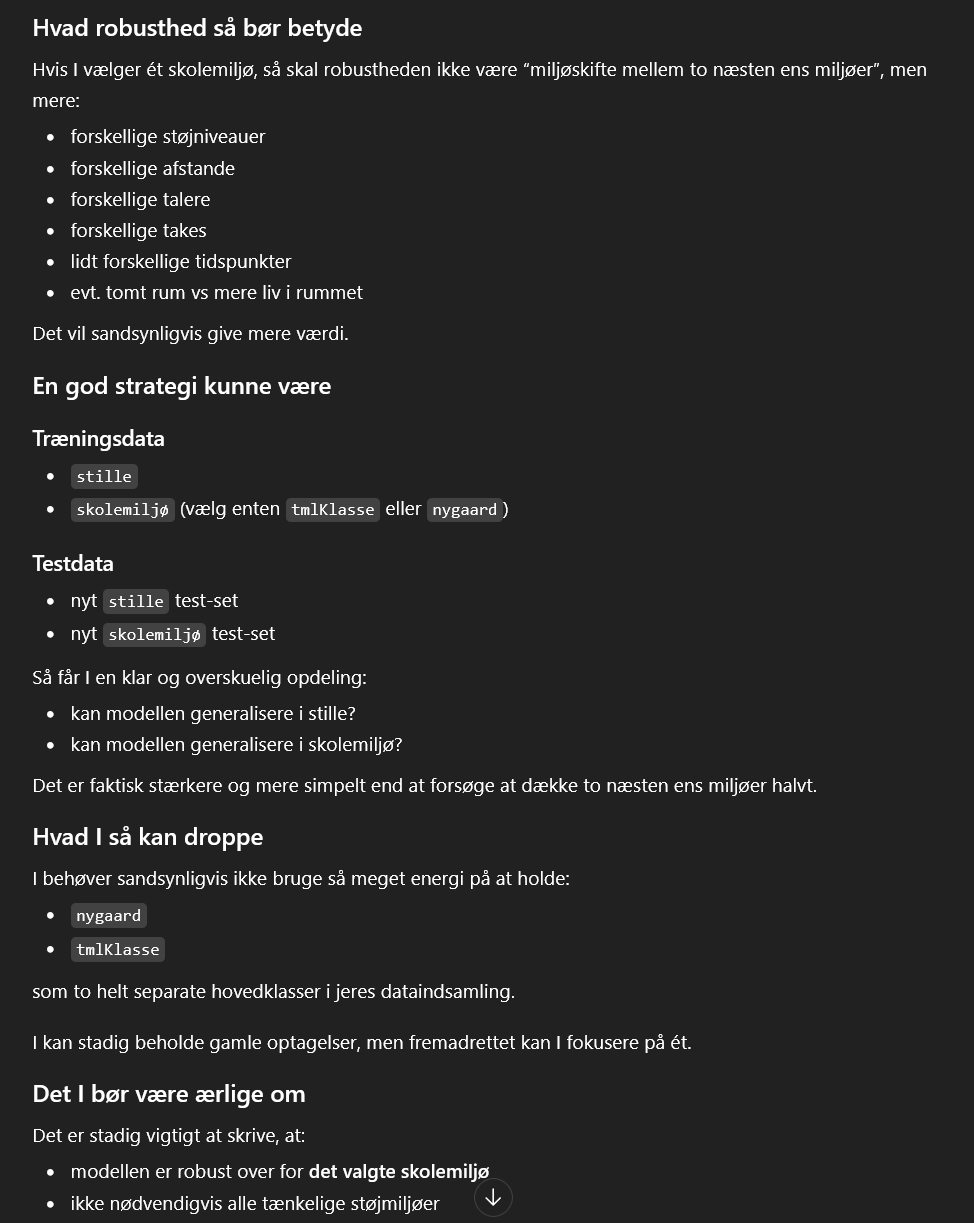

En kombination af at vores optagelser er ret monotone pr. kombination, samt at data augmentationen laver ekstra bias, så vil vi fokuserer på at lave bedre optagelser i to støj miljøer (stille og tmlKlasse/nygaard).

Vi tilføjer et miljø, så vi har to støjniveauer i alt

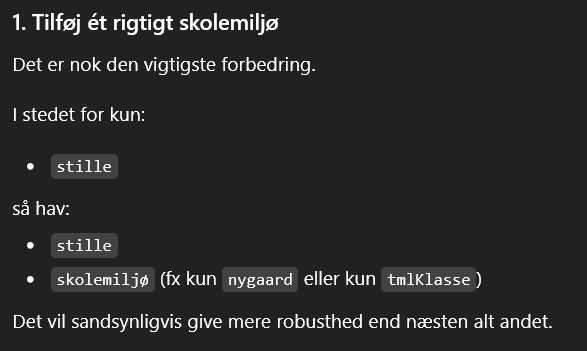

Flere takes pr kombination, ALTSÅ AT VI GENNEMFØR ET TAKE AF DISSE KOMBINATIONER MINIMUM 2 GANGE, FOR AT VI KAN FÅ VARIATION I UDTALE

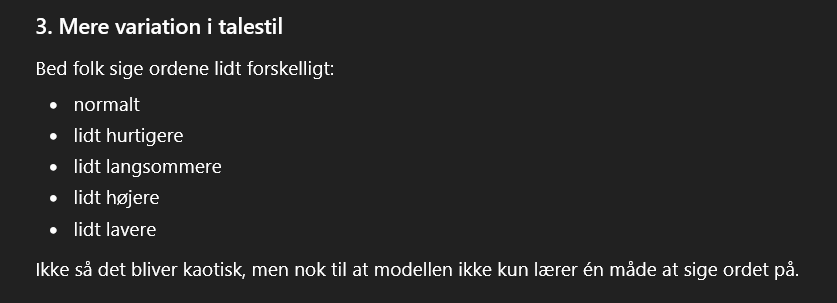

Dermed kan vi få flere optagelser, således

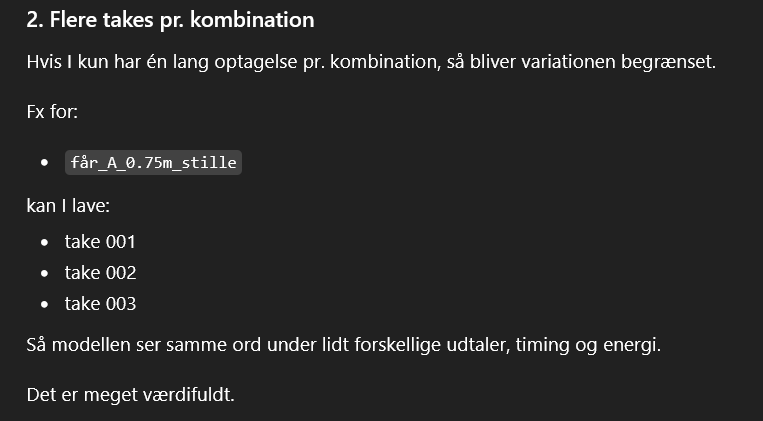

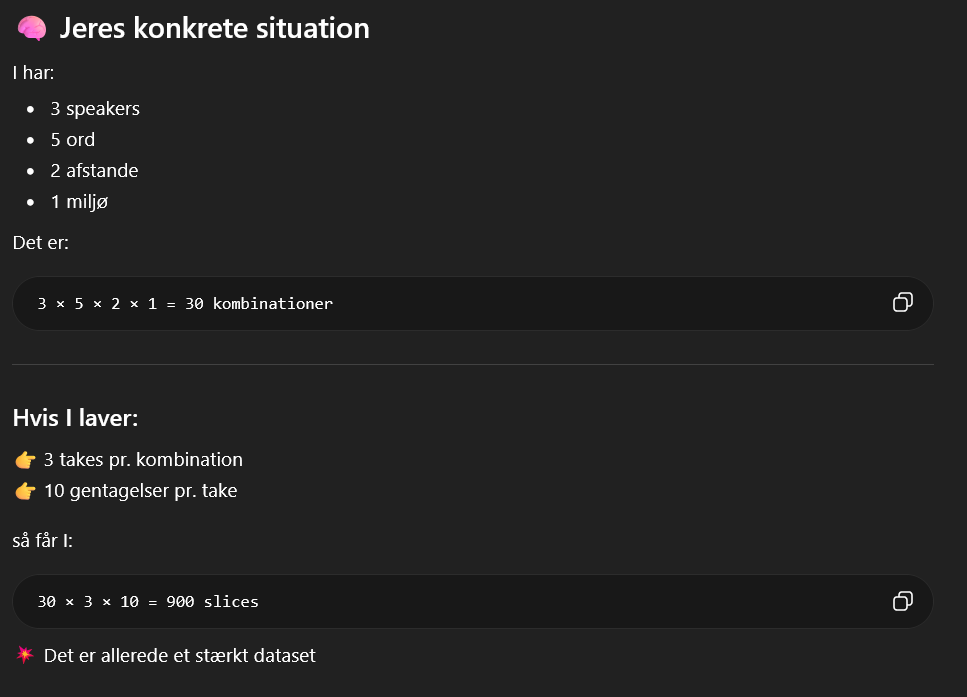

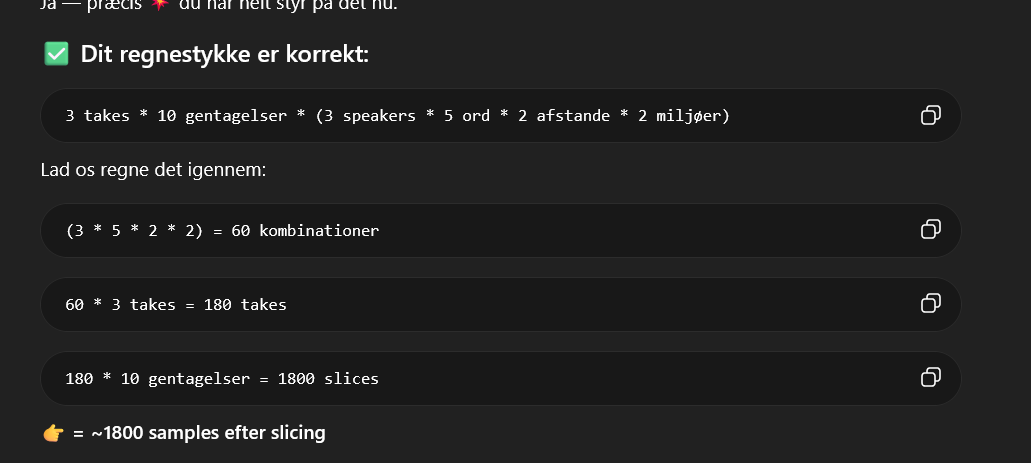

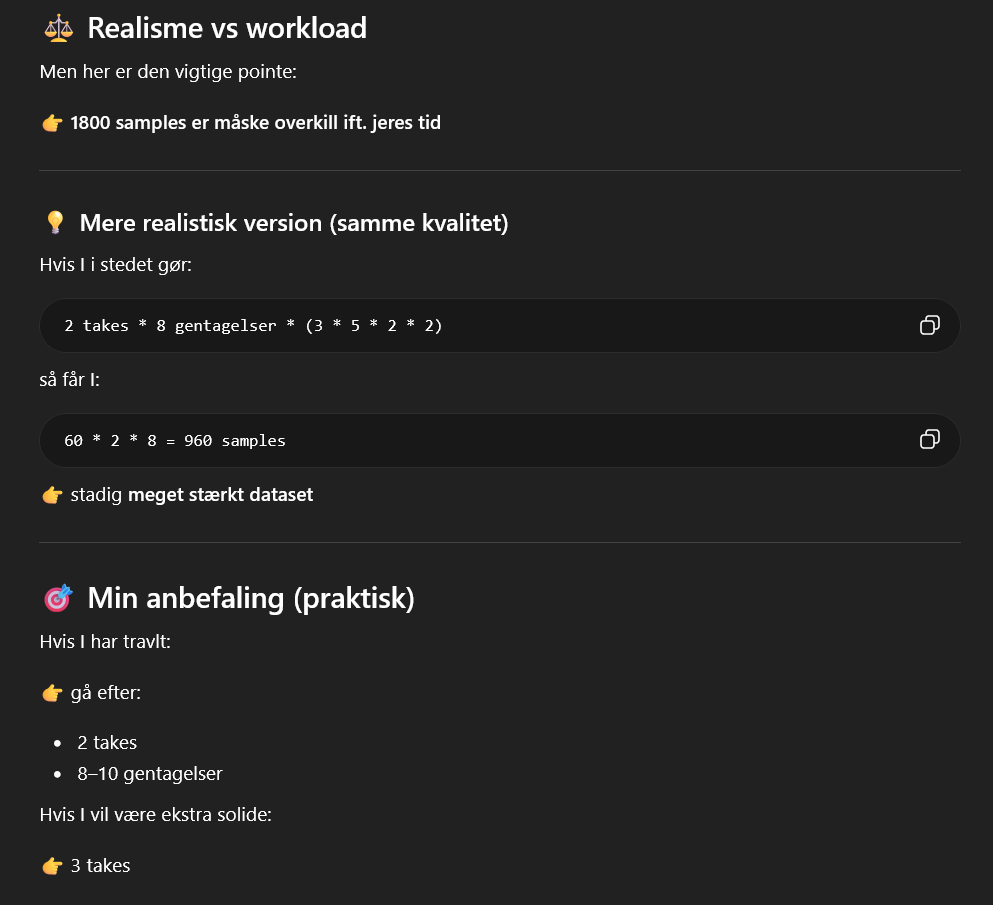

# Vigtigt

DESUDEN BØR VI NAVNGIVE VORES "stille" TIL "bachelor_lokale", EFTERSOM AT MODELLEN SOM DEN ER NU ER ROBUST FOR VARIATIONER I DET LOKALE, SOM HAR BESTEMTE AKUSTISKE FORHOLD OG RUMKLANG. 

# Test set fra bachelor lokale

Ovenstående test data er fra tmlKlassen, hvilket vores optagelser med keywords ikke er robust for. Siden vi kun har optaget vores keywords i bachelor lokalet, så bør vi helst starte med at vores model er robust for bachelor lokalet. Det er ellers meget bøvlet at få optagelser i kassen i tmlKlassen, fordi vi ikke er garanteret om der er nok støj i forvejen, så vi laver nedenstående test, som er:

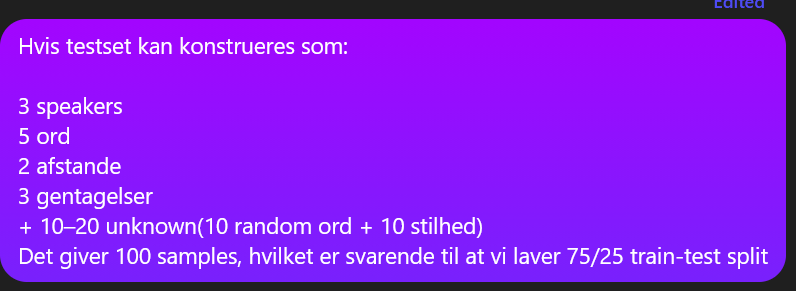

Samt ændre at vores unknown klasse, til at indeholde kun unknowns fra bachelorlokalet, HVOR VI FØR INDSAMLEDE UNKNOWNS MILJØER SOM MODELLEN IKKE KOMMER TIL AT VÆRE IBLANDT I STARTEN:

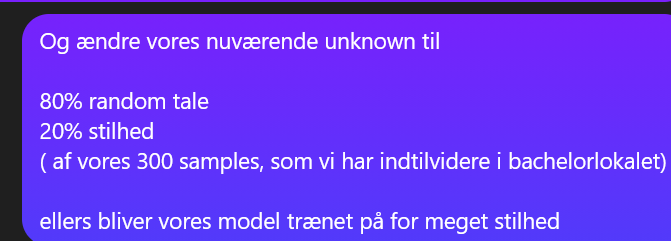

Når vi så evaluerer denne seperate test set på vores 300 samples fra bachelor lokalet, så kan vi observere om vores model er robust nok til bachelor lokalet. Hvis vi får en god confusion matrix, så har vi noget vi kan deploye og er garanteret på at vi har et MVP, som følger hele pipelinen med at vi laver indsamling af data til at vi deployer og laver inferencing på Photon 2!

Hvis den ikke er god nok, så skal vi lave flere takes, som der er beskrevet om i mappen "Anden_flere_takes_to_stømiljøer"

# Test data KUN C, hjemme hos ham (minder om stille niveau, ligesom bachelorLokale)

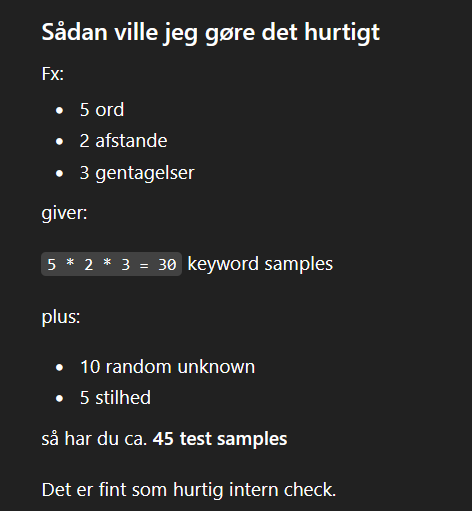

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    accuracy_score,
    classification_report,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# =========================
# SETTINGS
# =========================
TRAIN_KEYWORDS_DIR = Path("prepared_words")
TRAIN_UNKNOWN_DIR = Path("unknown_balanced")
TEST_DIR = Path("test_ready")

KEYWORD_LABELS = ["får", "ged", "hest", "laks", "ulv"]
ALL_LABELS = KEYWORD_LABELS + ["unknown"]

SAMPLE_RATE = 16000
N_MFCC = 13

# =========================
# AUDIO / FEATURE FUNCTIONS
# =========================
def load_wav(path: Path):
    x, fs = sf.read(str(path), always_2d=False)
    x = np.asarray(x, dtype=np.float32)

    if x.ndim > 1:
        x = x.mean(axis=1)

    if fs != SAMPLE_RATE:
        raise ValueError(f"Unexpected sample rate in {path}: {fs}")

    peak = np.max(np.abs(x)) + 1e-9
    x = x / peak

    return x

def magnitude_spectrum(x, fs):
    window = np.hanning(len(x))
    xw = x * window
    spec = np.fft.rfft(xw)
    mag = np.abs(spec)
    freqs = np.fft.rfftfreq(len(xw), d=1 / fs)
    return freqs, mag

def rms_energy(x):
    return float(np.sqrt(np.mean(x ** 2) + 1e-12))

def zero_crossing_rate(x):
    return float(np.mean(np.signbit(x[1:]) != np.signbit(x[:-1])))

def spectral_centroid(x, fs):
    freqs, mag = magnitude_spectrum(x, fs)
    return float(np.sum(freqs * mag) / (np.sum(mag) + 1e-12))

def spectral_rolloff(x, fs, roll_percent=0.85):
    freqs, mag = magnitude_spectrum(x, fs)
    cumsum = np.cumsum(mag)
    threshold = roll_percent * cumsum[-1]
    idx = np.searchsorted(cumsum, threshold)
    return float(freqs[min(idx, len(freqs) - 1)])

def dominant_frequency(x, fs):
    freqs, mag = magnitude_spectrum(x, fs)
    idx = np.argmax(mag[1:]) + 1 if len(mag) > 1 else 0
    return float(freqs[idx])

def band_energy(x, fs, f_low, f_high):
    freqs, mag = magnitude_spectrum(x, fs)
    power = mag ** 2
    mask = (freqs >= f_low) & (freqs < f_high)
    return float(np.sum(power[mask]))

def mfcc_features(x, sr, n_mfcc=13):
    mfcc = librosa.feature.mfcc(
        y=x,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=1024,
        hop_length=512
    )
    return np.mean(mfcc, axis=1)

def extract_features(x, fs):
    record = {
        "rms": rms_energy(x),
        "zcr": zero_crossing_rate(x),
        "centroid": spectral_centroid(x, fs),
        "rolloff": spectral_rolloff(x, fs),
        "dominant_freq": dominant_frequency(x, fs),
        "band_0_500": band_energy(x, fs, 0, 500),
        "band_500_1500": band_energy(x, fs, 500, 1500),
        "band_1500_3000": band_energy(x, fs, 1500, 3000),
        "band_3000_6000": band_energy(x, fs, 3000, 6000),
    }

    mfcc_vals = mfcc_features(x, fs, n_mfcc=N_MFCC)
    for i, val in enumerate(mfcc_vals, start=1):
        record[f"mfcc_{i}"] = float(val)

    return record

# =========================
# BUILD DATAFRAMES
# =========================
train_records = []

for label in KEYWORD_LABELS:
    for wav_path in sorted((TRAIN_KEYWORDS_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        record = extract_features(x, SAMPLE_RATE)
        record["activity"] = label
        train_records.append(record)

for wav_path in sorted(TRAIN_UNKNOWN_DIR.glob("*.wav")):
    x = load_wav(wav_path)
    record = extract_features(x, SAMPLE_RATE)
    record["activity"] = "unknown"
    train_records.append(record)

train_df = pd.DataFrame(train_records)

test_records = []

for label in ALL_LABELS:
    for wav_path in sorted((TEST_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        record = extract_features(x, SAMPLE_RATE)
        record["activity"] = label
        test_records.append(record)

test_df = pd.DataFrame(test_records)

simple_features = [
    "rms", "zcr", "centroid", "rolloff", "dominant_freq",
    "band_0_500", "band_500_1500", "band_1500_3000", "band_3000_6000"
]
mfcc_feature_cols = [f"mfcc_{i}" for i in range(1, N_MFCC + 1)]
all_features = simple_features + mfcc_feature_cols

feature_sets = {
    "simple": simple_features,
    "mfcc": mfcc_feature_cols,
    "combined": all_features,
}

models = {
    "LogisticRegression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=3000)
    ),
    "LinearSVM": make_pipeline(
        StandardScaler(),
        LinearSVC()
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=3,
        random_state=42
    ),
}

results = []

for feat_name, feat_cols in feature_sets.items():
    X_train = train_df[feat_cols]
    y_train = train_df["activity"]

    X_test = test_df[feat_cols]
    y_test = test_df["activity"]

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        results.append({
            "model": model_name,
            "features": feat_name,
            "accuracy": acc
        })

        print(f"\nModel: {model_name}, Features: {feat_name}")
        print("Accuracy:", acc)
        print(classification_report(y_test, y_pred, labels=ALL_LABELS))

        # 🔥 NYT: Confusion Matrix Plot
        cm = confusion_matrix(y_test, y_pred, labels=ALL_LABELS)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=ALL_LABELS
        )

        fig, ax = plt.subplots(figsize=(6, 5))
        disp.plot(ax=ax, cmap="magma", values_format="d")
        plt.title(f"{model_name} ({feat_name})")
        plt.tight_layout()
        plt.show()

results_df = pd.DataFrame(results)
print("\nSummary:")
print(results_df.sort_values("accuracy", ascending=False))

# Test set fra STILLE TML LOKALE

Ovenstående test data er fra tmlKlassen, hvilket vores optagelser med keywords ikke er robust for. Siden vi kun har optaget vores keywords i bachelor lokalet, så bør vi helst starte med at vores model er robust for bachelor lokalet. Det er ellers meget bøvlet at få optagelser i kassen i tmlKlassen, fordi vi ikke er garanteret om der er nok støj i forvejen, så vi laver nedenstående test, som er:

![image.png](attachment:image.png)

Samt ændre at vores unknown klasse, til at indeholde kun unknowns fra bachelorlokalet, HVOR VI FØR INDSAMLEDE UNKNOWNS MILJØER SOM MODELLEN IKKE KOMMER TIL AT VÆRE IBLANDT I STARTEN:

![image-2.png](attachment:image-2.png)

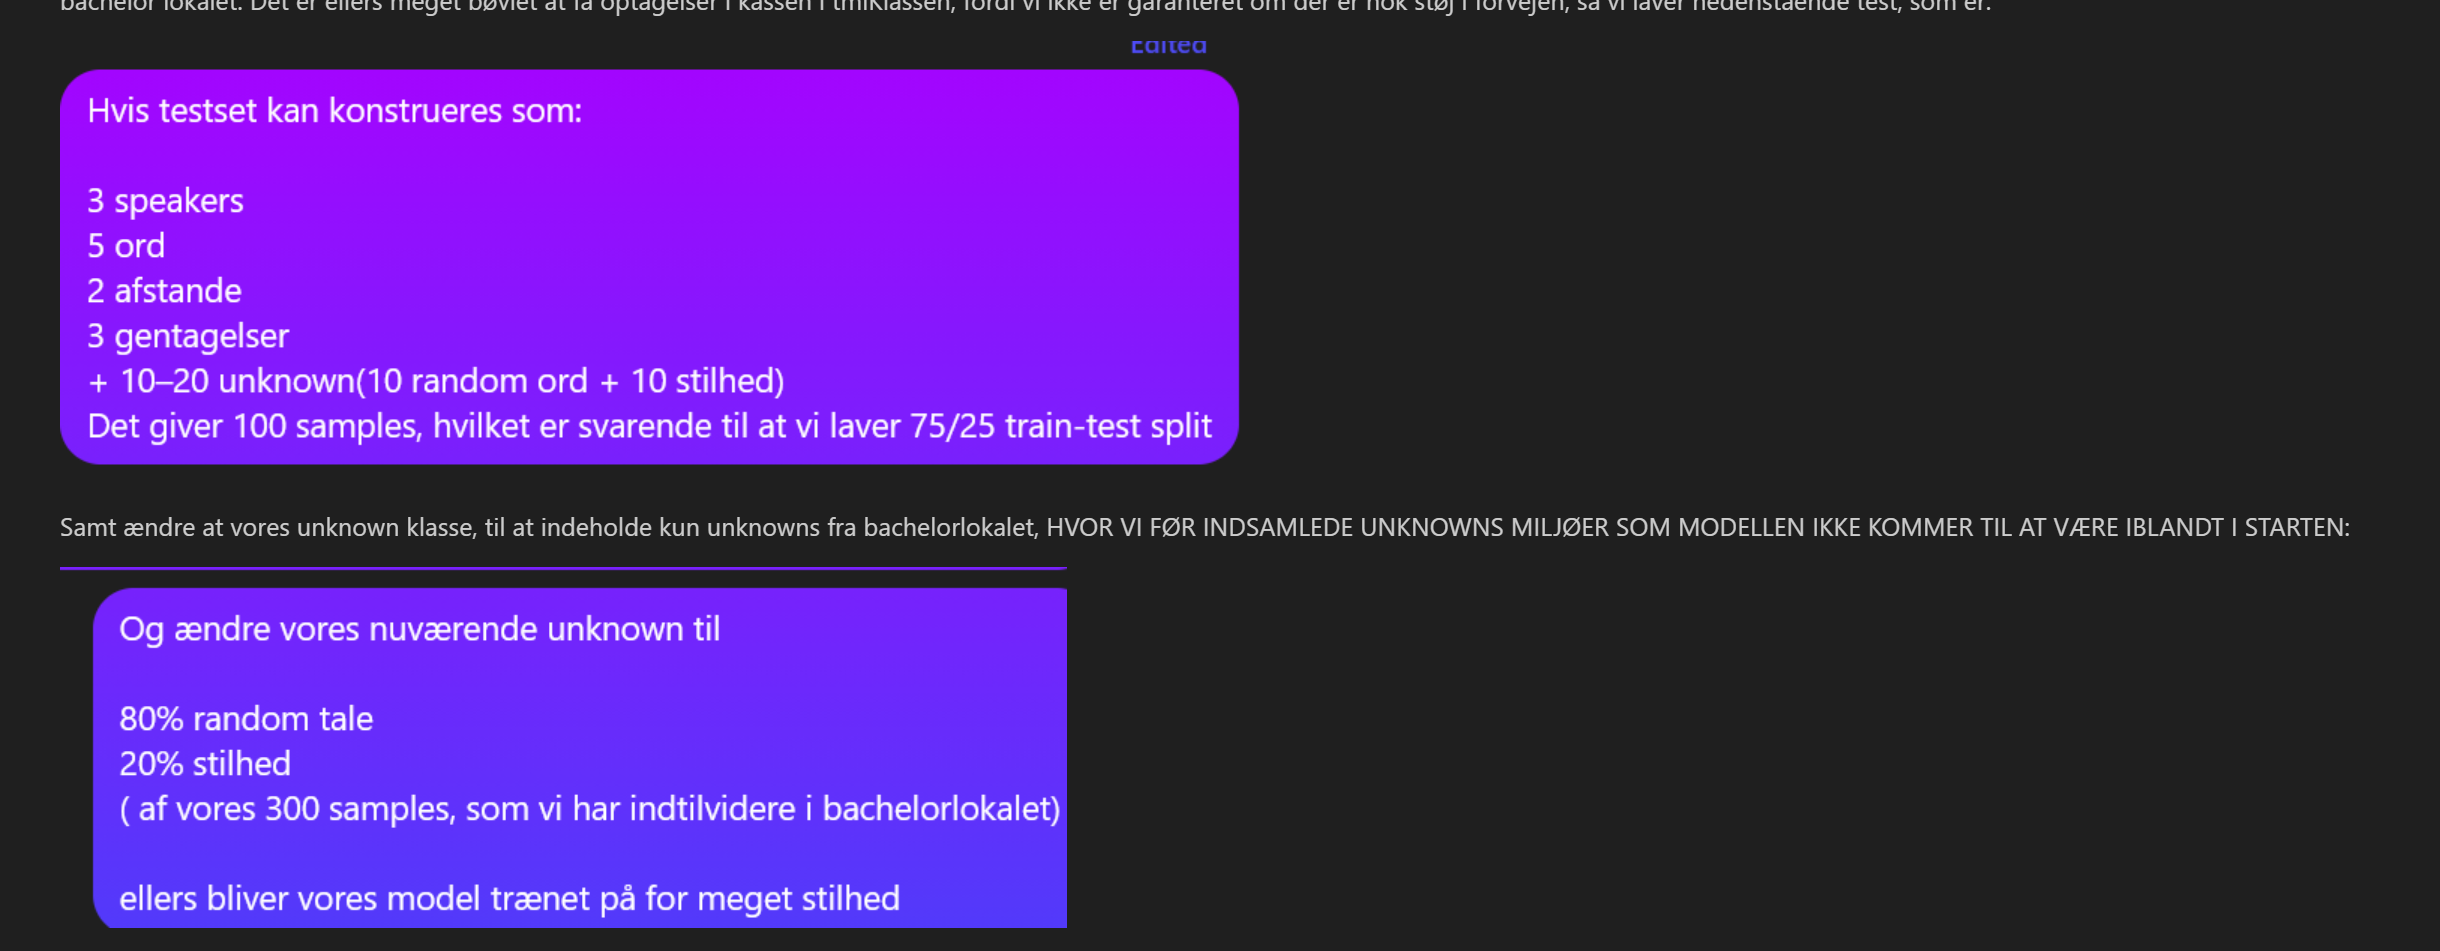

Når vi så evaluerer denne seperate test set på vores 300 samples fra bachelor lokalet, så kan vi observere om vores model er robust nok til bachelor lokalet. Hvis vi får en god confusion matrix, så har vi noget vi kan deploye og er garanteret på at vi har et MVP, som følger hele pipelinen med at vi laver indsamling af data til at vi deployer og laver inferencing på Photon 2!

Hvis den ikke er god nok, så skal vi lave flere takes, som der er beskrevet om i mappen "Anden_flere_takes_to_stømiljøer"


Model: LogisticRegression, Features: simple
Accuracy: 0.21100917431192662
              precision    recall  f1-score   support

         får       0.00      0.00      0.00        18
         ged       0.00      0.00      0.00        16
        hest       0.40      0.11      0.17        18
        laks       1.00      0.05      0.10        19
         ulv       0.00      0.00      0.00        18
     unknown       0.19      1.00      0.33        20

    accuracy                           0.21       109
   macro avg       0.27      0.19      0.10       109
weighted avg       0.28      0.21      0.11       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


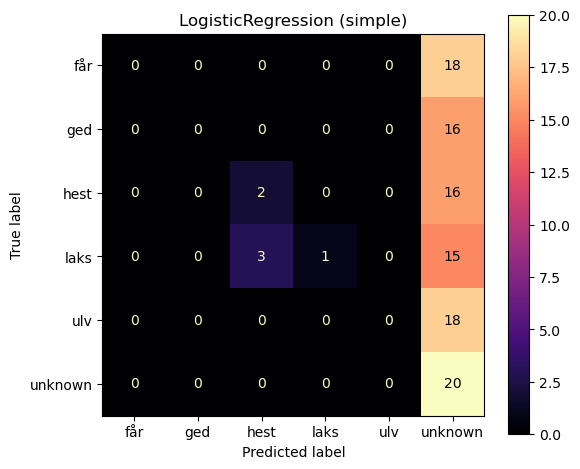


Model: LinearSVM, Features: simple
Accuracy: 0.22018348623853212
              precision    recall  f1-score   support

         får       0.00      0.00      0.00        18
         ged       0.00      0.00      0.00        16
        hest       0.67      0.11      0.19        18
        laks       1.00      0.11      0.19        19
         ulv       0.00      0.00      0.00        18
     unknown       0.19      1.00      0.32        20

    accuracy                           0.22       109
   macro avg       0.31      0.20      0.12       109
weighted avg       0.32      0.22      0.12       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


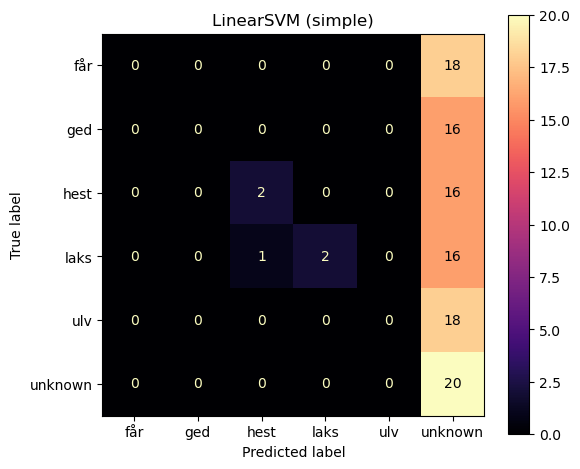


Model: RandomForest, Features: simple
Accuracy: 0.23853211009174313
              precision    recall  f1-score   support

         får       1.00      0.06      0.11        18
         ged       0.00      0.00      0.00        16
        hest       1.00      0.11      0.20        18
        laks       1.00      0.16      0.27        19
         ulv       0.00      0.00      0.00        18
     unknown       0.19      1.00      0.33        20

    accuracy                           0.24       109
   macro avg       0.53      0.22      0.15       109
weighted avg       0.54      0.24      0.16       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


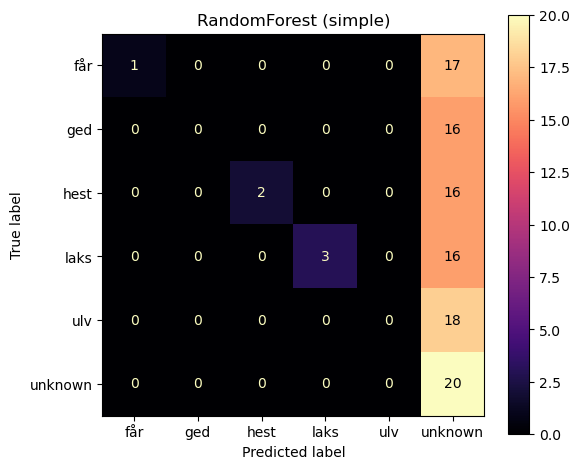


Model: LogisticRegression, Features: mfcc
Accuracy: 0.28440366972477066
              precision    recall  f1-score   support

         får       1.00      0.06      0.11        18
         ged       0.00      0.00      0.00        16
        hest       1.00      0.28      0.43        18
        laks       1.00      0.26      0.42        19
         ulv       0.00      0.00      0.00        18
     unknown       0.21      1.00      0.34        20

    accuracy                           0.28       109
   macro avg       0.53      0.27      0.22       109
weighted avg       0.54      0.28      0.22       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


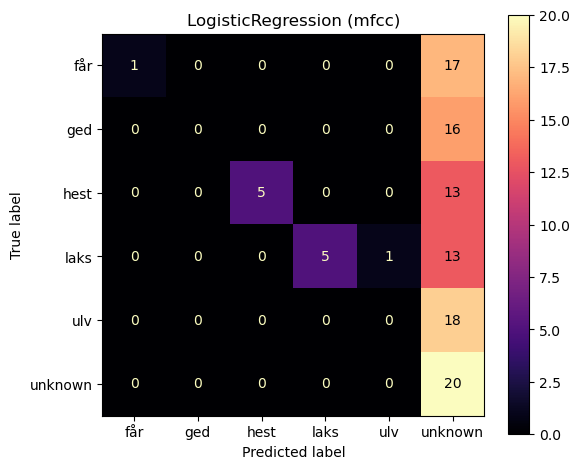


Model: LinearSVM, Features: mfcc
Accuracy: 0.30275229357798167
              precision    recall  f1-score   support

         får       1.00      0.06      0.11        18
         ged       0.00      0.00      0.00        16
        hest       1.00      0.39      0.56        18
        laks       1.00      0.26      0.42        19
         ulv       0.00      0.00      0.00        18
     unknown       0.21      1.00      0.34        20

    accuracy                           0.30       109
   macro avg       0.53      0.28      0.24       109
weighted avg       0.54      0.30      0.25       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


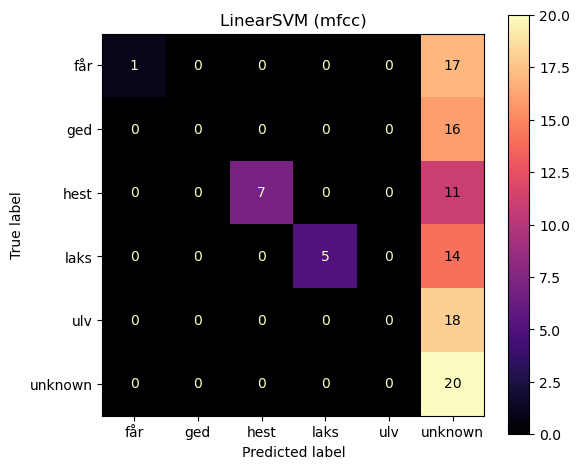


Model: RandomForest, Features: mfcc
Accuracy: 0.21100917431192662
              precision    recall  f1-score   support

         får       0.00      0.00      0.00        18
         ged       0.00      0.00      0.00        16
        hest       1.00      0.06      0.11        18
        laks       1.00      0.11      0.19        19
         ulv       0.00      0.00      0.00        18
     unknown       0.19      1.00      0.32        20

    accuracy                           0.21       109
   macro avg       0.36      0.19      0.10       109
weighted avg       0.37      0.21      0.11       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


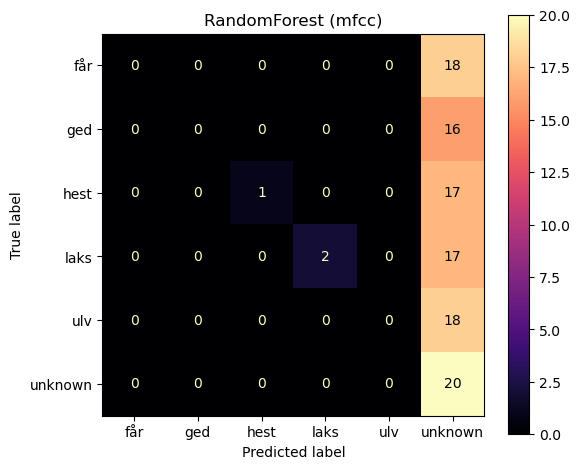


Model: LogisticRegression, Features: combined
Accuracy: 0.27522935779816515
              precision    recall  f1-score   support

         får       0.00      0.00      0.00        18
         ged       0.00      0.00      0.00        16
        hest       1.00      0.17      0.29        18
        laks       1.00      0.32      0.48        19
         ulv       1.00      0.06      0.11        18
     unknown       0.20      1.00      0.34        20

    accuracy                           0.28       109
   macro avg       0.53      0.26      0.20       109
weighted avg       0.54      0.28      0.21       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


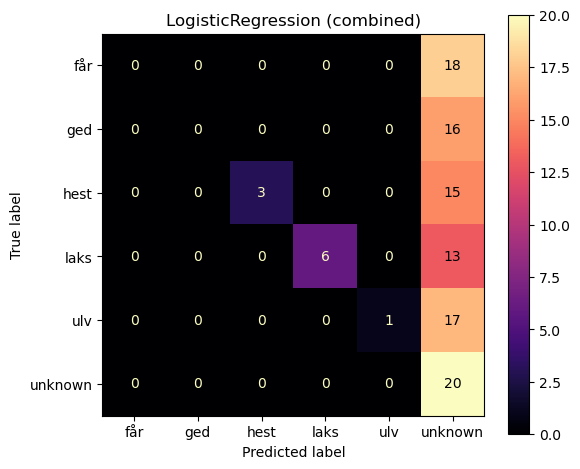


Model: LinearSVM, Features: combined
Accuracy: 0.24770642201834864
              precision    recall  f1-score   support

         får       0.00      0.00      0.00        18
         ged       0.00      0.00      0.00        16
        hest       1.00      0.22      0.36        18
        laks       1.00      0.16      0.27        19
         ulv       0.00      0.00      0.00        18
     unknown       0.20      1.00      0.33        20

    accuracy                           0.25       109
   macro avg       0.37      0.23      0.16       109
weighted avg       0.38      0.25      0.17       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


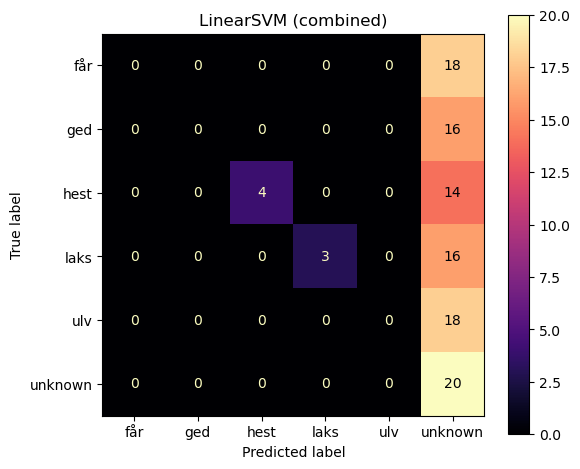


Model: RandomForest, Features: combined
Accuracy: 0.22018348623853212
              precision    recall  f1-score   support

         får       1.00      0.06      0.11        18
         ged       0.00      0.00      0.00        16
        hest       1.00      0.06      0.11        18
        laks       1.00      0.11      0.19        19
         ulv       0.00      0.00      0.00        18
     unknown       0.19      1.00      0.32        20

    accuracy                           0.22       109
   macro avg       0.53      0.20      0.12       109
weighted avg       0.54      0.22      0.13       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


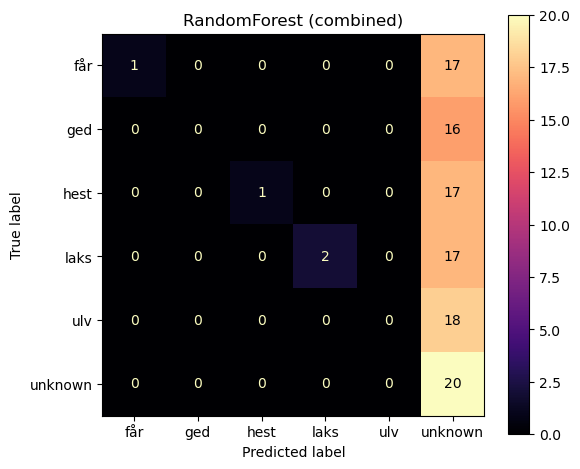


Summary:
                model  features  accuracy
4           LinearSVM      mfcc  0.302752
3  LogisticRegression      mfcc  0.284404
6  LogisticRegression  combined  0.275229
7           LinearSVM  combined  0.247706
2        RandomForest    simple  0.238532
1           LinearSVM    simple  0.220183
8        RandomForest  combined  0.220183
0  LogisticRegression    simple  0.211009
5        RandomForest      mfcc  0.211009


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    accuracy_score,
    classification_report,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# =========================
# SETTINGS
# =========================
TRAIN_KEYWORDS_DIR = Path("prepared_words")
TRAIN_UNKNOWN_DIR = Path("unknown_balanced")
TEST_DIR = Path("test_ready")

KEYWORD_LABELS = ["får", "ged", "hest", "laks", "ulv"]
ALL_LABELS = KEYWORD_LABELS + ["unknown"]

SAMPLE_RATE = 16000
N_MFCC = 13

# =========================
# AUDIO / FEATURE FUNCTIONS
# =========================
def load_wav(path: Path):
    x, fs = sf.read(str(path), always_2d=False)
    x = np.asarray(x, dtype=np.float32)

    if x.ndim > 1:
        x = x.mean(axis=1)

    if fs != SAMPLE_RATE:
        raise ValueError(f"Unexpected sample rate in {path}: {fs}")

    peak = np.max(np.abs(x)) + 1e-9
    x = x / peak

    return x

def magnitude_spectrum(x, fs):
    window = np.hanning(len(x))
    xw = x * window
    spec = np.fft.rfft(xw)
    mag = np.abs(spec)
    freqs = np.fft.rfftfreq(len(xw), d=1 / fs)
    return freqs, mag

def rms_energy(x):
    return float(np.sqrt(np.mean(x ** 2) + 1e-12))

def zero_crossing_rate(x):
    return float(np.mean(np.signbit(x[1:]) != np.signbit(x[:-1])))

def spectral_centroid(x, fs):
    freqs, mag = magnitude_spectrum(x, fs)
    return float(np.sum(freqs * mag) / (np.sum(mag) + 1e-12))

def spectral_rolloff(x, fs, roll_percent=0.85):
    freqs, mag = magnitude_spectrum(x, fs)
    cumsum = np.cumsum(mag)
    threshold = roll_percent * cumsum[-1]
    idx = np.searchsorted(cumsum, threshold)
    return float(freqs[min(idx, len(freqs) - 1)])

def dominant_frequency(x, fs):
    freqs, mag = magnitude_spectrum(x, fs)
    idx = np.argmax(mag[1:]) + 1 if len(mag) > 1 else 0
    return float(freqs[idx])

def band_energy(x, fs, f_low, f_high):
    freqs, mag = magnitude_spectrum(x, fs)
    power = mag ** 2
    mask = (freqs >= f_low) & (freqs < f_high)
    return float(np.sum(power[mask]))

def mfcc_features(x, sr, n_mfcc=13):
    mfcc = librosa.feature.mfcc(
        y=x,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=1024,
        hop_length=512
    )
    return np.mean(mfcc, axis=1)

def extract_features(x, fs):
    record = {
        "rms": rms_energy(x),
        "zcr": zero_crossing_rate(x),
        "centroid": spectral_centroid(x, fs),
        "rolloff": spectral_rolloff(x, fs),
        "dominant_freq": dominant_frequency(x, fs),
        "band_0_500": band_energy(x, fs, 0, 500),
        "band_500_1500": band_energy(x, fs, 500, 1500),
        "band_1500_3000": band_energy(x, fs, 1500, 3000),
        "band_3000_6000": band_energy(x, fs, 3000, 6000),
    }

    mfcc_vals = mfcc_features(x, fs, n_mfcc=N_MFCC)
    for i, val in enumerate(mfcc_vals, start=1):
        record[f"mfcc_{i}"] = float(val)

    return record

# =========================
# BUILD DATAFRAMES
# =========================
train_records = []

for label in KEYWORD_LABELS:
    for wav_path in sorted((TRAIN_KEYWORDS_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        record = extract_features(x, SAMPLE_RATE)
        record["activity"] = label
        train_records.append(record)

for wav_path in sorted(TRAIN_UNKNOWN_DIR.glob("*.wav")):
    x = load_wav(wav_path)
    record = extract_features(x, SAMPLE_RATE)
    record["activity"] = "unknown"
    train_records.append(record)

train_df = pd.DataFrame(train_records)

test_records = []

for label in ALL_LABELS:
    for wav_path in sorted((TEST_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        record = extract_features(x, SAMPLE_RATE)
        record["activity"] = label
        test_records.append(record)

test_df = pd.DataFrame(test_records)

simple_features = [
    "rms", "zcr", "centroid", "rolloff", "dominant_freq",
    "band_0_500", "band_500_1500", "band_1500_3000", "band_3000_6000"
]
mfcc_feature_cols = [f"mfcc_{i}" for i in range(1, N_MFCC + 1)]
all_features = simple_features + mfcc_feature_cols

feature_sets = {
    "simple": simple_features,
    "mfcc": mfcc_feature_cols,
    "combined": all_features,
}

models = {
    "LogisticRegression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=3000)
    ),
    "LinearSVM": make_pipeline(
        StandardScaler(),
        LinearSVC()
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=3,
        random_state=42
    ),
}

results = []

for feat_name, feat_cols in feature_sets.items():
    X_train = train_df[feat_cols]
    y_train = train_df["activity"]

    X_test = test_df[feat_cols]
    y_test = test_df["activity"]

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        results.append({
            "model": model_name,
            "features": feat_name,
            "accuracy": acc
        })

        print(f"\nModel: {model_name}, Features: {feat_name}")
        print("Accuracy:", acc)
        print(classification_report(y_test, y_pred, labels=ALL_LABELS))

        # 🔥 NYT: Confusion Matrix Plot
        cm = confusion_matrix(y_test, y_pred, labels=ALL_LABELS)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=ALL_LABELS
        )

        fig, ax = plt.subplots(figsize=(6, 5))
        disp.plot(ax=ax, cmap="magma", values_format="d")
        plt.title(f"{model_name} ({feat_name})")
        plt.tight_layout()
        plt.show()

results_df = pd.DataFrame(results)
print("\nSummary:")
print(results_df.sort_values("accuracy", ascending=False))

Vi plotter FFT og ser om de optagelser, som er stærkt påvirket af "klik" støjen er stærkt visualiseret og kan dermed ødelægge vores klassificering

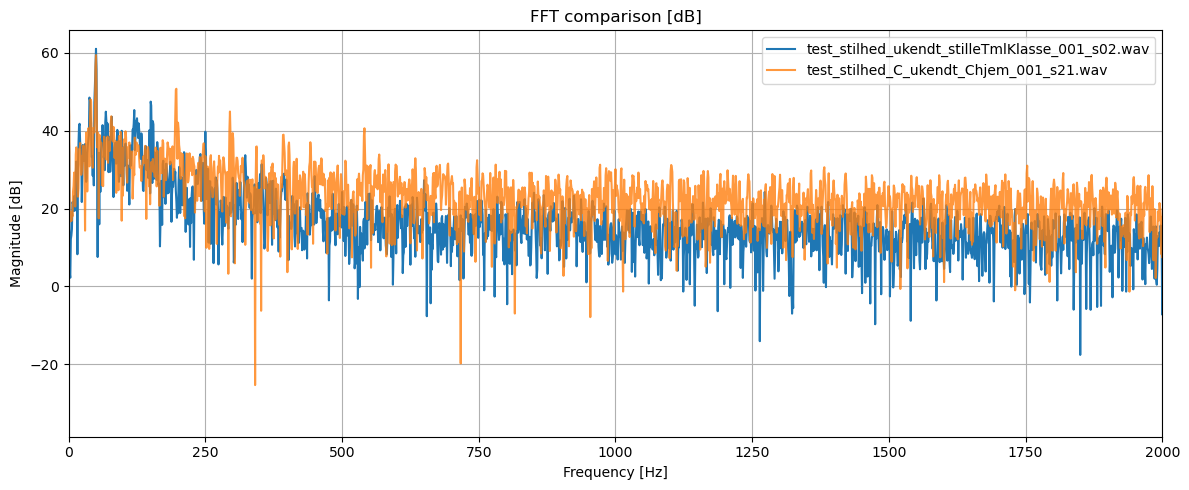

In [15]:
from pathlib import Path
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt


def load_wav_mono(path: Path):
    x, fs = sf.read(str(path), always_2d=False)
    x = np.asarray(x, dtype=np.float32)
    if x.ndim > 1:
        x = x.mean(axis=1)
    return x, fs


def normalize_peak(x, eps=1e-9):
    return x / (np.max(np.abs(x)) + eps)


def fft_db(x, fs):
    window = np.hanning(len(x))
    xw = x * window
    spec = np.fft.rfft(xw)
    mag = np.abs(spec)
    mag_db = 20 * np.log10(mag + 1e-12)
    freqs = np.fft.rfftfreq(len(xw), d=1 / fs)
    return freqs, mag_db


def compare_fft(file1, file2, xlim_freq=(0, 8000), normalize=True):
    x1, fs1 = load_wav_mono(Path(file1))
    x2, fs2 = load_wav_mono(Path(file2))

    if fs1 != fs2:
        raise ValueError(f"Different sample rates: {fs1} vs {fs2}")

    if normalize:
        x1 = normalize_peak(x1)
        x2 = normalize_peak(x2)

    f1, db1 = fft_db(x1, fs1)
    f2, db2 = fft_db(x2, fs2)

    plt.figure(figsize=(12, 5))
    plt.plot(f1, db1, label=Path(file1).name)
    plt.plot(f2, db2, label=Path(file2).name, alpha=0.8)
    plt.title("FFT comparison [dB]")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Magnitude [dB]")
    plt.xlim(xlim_freq)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Example:
compare_fft(
    "test_ready/unknown/test_stilhed_ukendt_stilleTmlKlasse_001_s02.wav",
    "test_stilhed_C_ukendt_Chjem_001_s21.wav",
    xlim_freq=(0, 2000)
)


Model: LogisticRegression, Features: simple
Accuracy: 0.26605504587155965
              precision    recall  f1-score   support

         får       0.00      0.00      0.00        18
         ged       0.00      0.00      0.00        16
        hest       0.75      0.33      0.46        18
        laks       1.00      0.16      0.27        19
         ulv       0.00      0.00      0.00        18
     unknown       0.20      1.00      0.34        20

    accuracy                           0.27       109
   macro avg       0.33      0.25      0.18       109
weighted avg       0.34      0.27      0.19       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


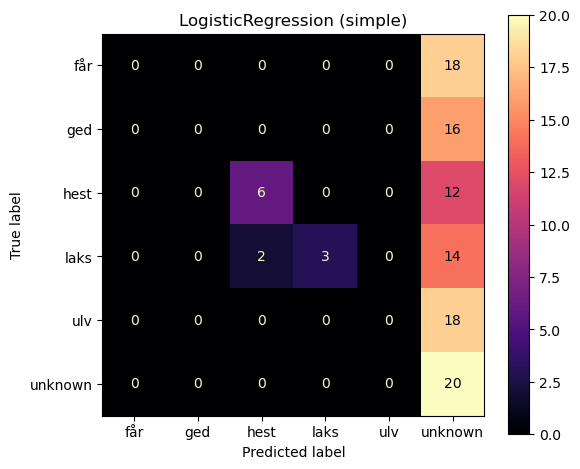


Model: LinearSVM, Features: simple
Accuracy: 0.26605504587155965
              precision    recall  f1-score   support

         får       0.00      0.00      0.00        18
         ged       0.00      0.00      0.00        16
        hest       0.83      0.28      0.42        18
        laks       1.00      0.21      0.35        19
         ulv       0.00      0.00      0.00        18
     unknown       0.20      1.00      0.34        20

    accuracy                           0.27       109
   macro avg       0.34      0.25      0.18       109
weighted avg       0.35      0.27      0.19       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


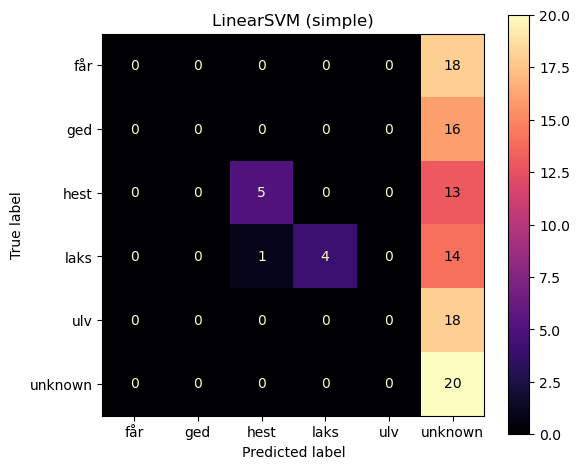


Model: RandomForest, Features: simple
Accuracy: 0.25688073394495414
              precision    recall  f1-score   support

         får       0.00      0.00      0.00        18
         ged       1.00      0.06      0.12        16
        hest       1.00      0.17      0.29        18
        laks       1.00      0.21      0.35        19
         ulv       0.00      0.00      0.00        18
     unknown       0.20      1.00      0.33        20

    accuracy                           0.26       109
   macro avg       0.53      0.24      0.18       109
weighted avg       0.52      0.26      0.19       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


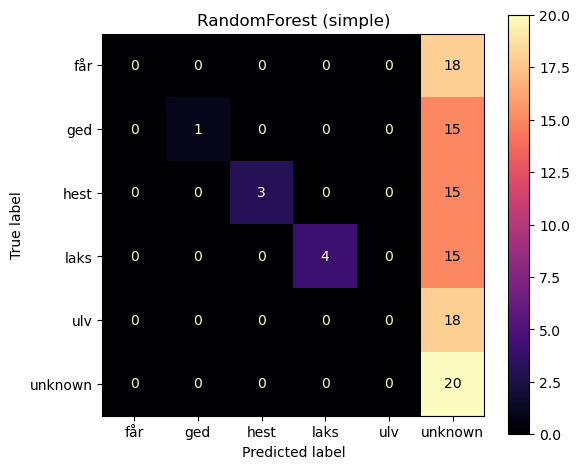


Model: LogisticRegression, Features: mfcc
Accuracy: 0.3394495412844037
              precision    recall  f1-score   support

         får       1.00      0.22      0.36        18
         ged       0.00      0.00      0.00        16
        hest       1.00      0.28      0.43        18
        laks       1.00      0.32      0.48        19
         ulv       1.00      0.11      0.20        18
     unknown       0.22      1.00      0.36        20

    accuracy                           0.34       109
   macro avg       0.70      0.32      0.31       109
weighted avg       0.71      0.34      0.31       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


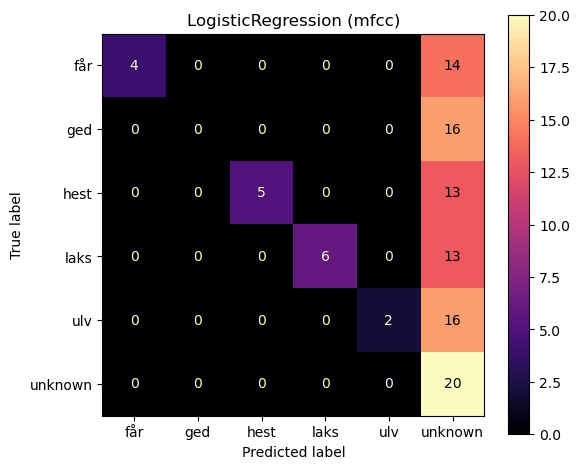


Model: LinearSVM, Features: mfcc
Accuracy: 0.3119266055045872
              precision    recall  f1-score   support

         får       1.00      0.11      0.20        18
         ged       0.00      0.00      0.00        16
        hest       1.00      0.22      0.36        18
        laks       1.00      0.32      0.48        19
         ulv       1.00      0.11      0.20        18
     unknown       0.21      1.00      0.35        20

    accuracy                           0.31       109
   macro avg       0.70      0.29      0.27       109
weighted avg       0.71      0.31      0.27       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


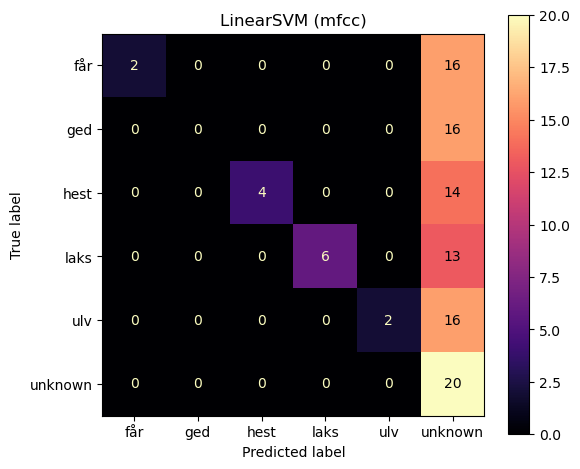


Model: RandomForest, Features: mfcc
Accuracy: 0.2018348623853211
              precision    recall  f1-score   support

         får       1.00      0.06      0.11        18
         ged       0.00      0.00      0.00        16
        hest       0.00      0.00      0.00        18
        laks       1.00      0.05      0.10        19
         ulv       0.00      0.00      0.00        18
     unknown       0.19      1.00      0.32        20

    accuracy                           0.20       109
   macro avg       0.36      0.18      0.09       109
weighted avg       0.37      0.20      0.09       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


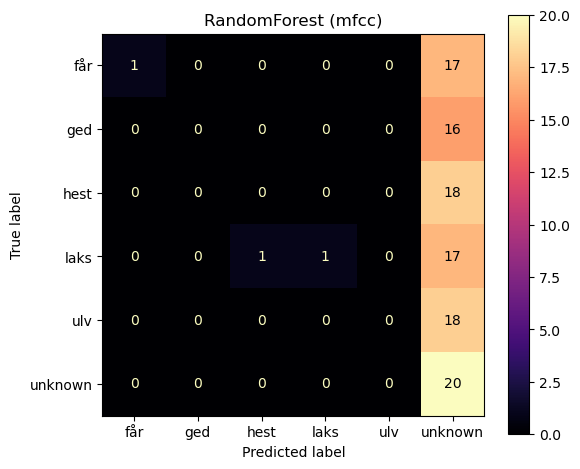


Model: LogisticRegression, Features: combined
Accuracy: 0.29357798165137616
              precision    recall  f1-score   support

         får       0.00      0.00      0.00        18
         ged       0.00      0.00      0.00        16
        hest       1.00      0.22      0.36        18
        laks       1.00      0.32      0.48        19
         ulv       1.00      0.11      0.20        18
     unknown       0.21      1.00      0.34        20

    accuracy                           0.29       109
   macro avg       0.53      0.27      0.23       109
weighted avg       0.54      0.29      0.24       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


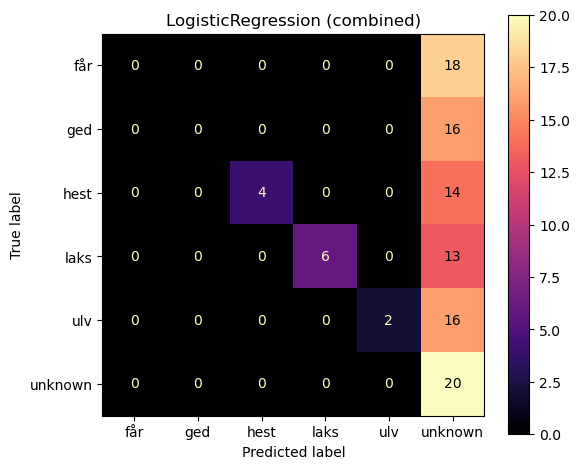


Model: LinearSVM, Features: combined
Accuracy: 0.28440366972477066
              precision    recall  f1-score   support

         får       0.00      0.00      0.00        18
         ged       0.00      0.00      0.00        16
        hest       1.00      0.22      0.36        18
        laks       1.00      0.32      0.48        19
         ulv       1.00      0.06      0.11        18
     unknown       0.20      1.00      0.34        20

    accuracy                           0.28       109
   macro avg       0.53      0.27      0.21       109
weighted avg       0.54      0.28      0.22       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


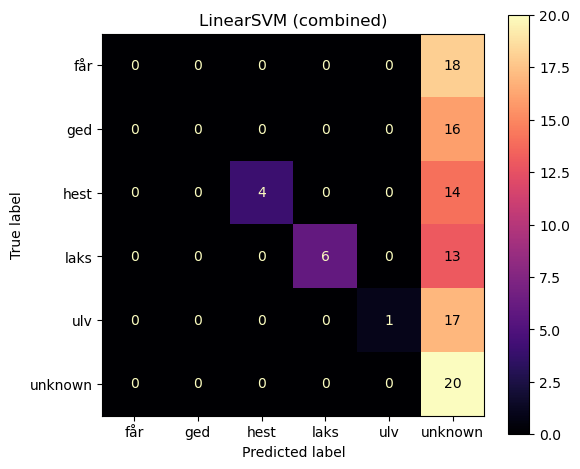


Model: RandomForest, Features: combined
Accuracy: 0.22018348623853212
              precision    recall  f1-score   support

         får       0.00      0.00      0.00        18
         ged       0.00      0.00      0.00        16
        hest       1.00      0.06      0.11        18
        laks       1.00      0.16      0.27        19
         ulv       0.00      0.00      0.00        18
     unknown       0.19      1.00      0.32        20

    accuracy                           0.22       109
   macro avg       0.37      0.20      0.12       109
weighted avg       0.37      0.22      0.12       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


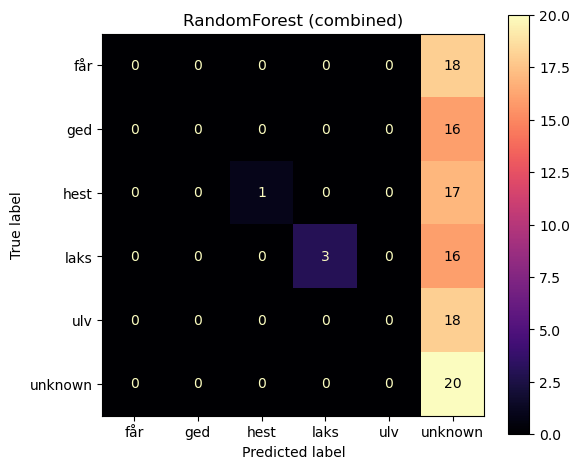


Summary:
                model  features  accuracy
3  LogisticRegression      mfcc  0.339450
4           LinearSVM      mfcc  0.311927
6  LogisticRegression  combined  0.293578
7           LinearSVM  combined  0.284404
0  LogisticRegression    simple  0.266055
1           LinearSVM    simple  0.266055
2        RandomForest    simple  0.256881
8        RandomForest  combined  0.220183
5        RandomForest      mfcc  0.201835


In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import matplotlib.pyplot as plt

from scipy.signal import medfilt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    accuracy_score,
    classification_report,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# =========================
# SETTINGS
# =========================
TRAIN_KEYWORDS_DIR = Path("prepared_words")
TRAIN_UNKNOWN_DIR = Path("unknown_balanced")
TEST_DIR = Path("test_ready")

KEYWORD_LABELS = ["får", "ged", "hest", "laks", "ulv"]
ALL_LABELS = KEYWORD_LABELS + ["unknown"]

SAMPLE_RATE = 16000
N_MFCC = 13

# =========================
# PREPROCESSING
# =========================
def remove_clicks(x, threshold=4.0):
    """
    Erstat store impuls-spikes med gennemsnittet af nabosamples.
    threshold angives i antal standardafvigelser.
    """
    x = x.copy()
    std = np.std(x) + 1e-12
    spike_mask = np.abs(x) > threshold * std
    spike_idx = np.where(spike_mask)[0]

    for i in spike_idx:
        if 1 <= i < len(x) - 1:
            x[i] = 0.5 * (x[i - 1] + x[i + 1])
        elif i == 0 and len(x) > 1:
            x[i] = x[i + 1]
        elif i == len(x) - 1 and len(x) > 1:
            x[i] = x[i - 1]

    return x


def preprocess_audio(x):
    """
    Simpel de-click preprocessing.
    Først spike-fjernelse, derefter medianfilter.
    """
    x = remove_clicks(x, threshold=4.0)
    x = medfilt(x, kernel_size=5)
    return x

# =========================
# AUDIO / FEATURE FUNCTIONS
# =========================
def load_wav(path: Path):
    x, fs = sf.read(str(path), always_2d=False)
    x = np.asarray(x, dtype=np.float32)

    if x.ndim > 1:
        x = x.mean(axis=1)

    if fs != SAMPLE_RATE:
        raise ValueError(f"Unexpected sample rate in {path}: {fs}")

    # Preprocessing mod klik / impulsstøj
    x = preprocess_audio(x)

    peak = np.max(np.abs(x)) + 1e-9
    x = x / peak

    return x

def magnitude_spectrum(x, fs):
    window = np.hanning(len(x))
    xw = x * window
    spec = np.fft.rfft(xw)
    mag = np.abs(spec)
    freqs = np.fft.rfftfreq(len(xw), d=1 / fs)
    return freqs, mag

def rms_energy(x):
    return float(np.sqrt(np.mean(x ** 2) + 1e-12))

def zero_crossing_rate(x):
    return float(np.mean(np.signbit(x[1:]) != np.signbit(x[:-1])))

def spectral_centroid(x, fs):
    freqs, mag = magnitude_spectrum(x, fs)
    return float(np.sum(freqs * mag) / (np.sum(mag) + 1e-12))

def spectral_rolloff(x, fs, roll_percent=0.85):
    freqs, mag = magnitude_spectrum(x, fs)
    cumsum = np.cumsum(mag)
    threshold = roll_percent * cumsum[-1]
    idx = np.searchsorted(cumsum, threshold)
    return float(freqs[min(idx, len(freqs) - 1)])

def dominant_frequency(x, fs):
    freqs, mag = magnitude_spectrum(x, fs)
    idx = np.argmax(mag[1:]) + 1 if len(mag) > 1 else 0
    return float(freqs[idx])

def band_energy(x, fs, f_low, f_high):
    freqs, mag = magnitude_spectrum(x, fs)
    power = mag ** 2
    mask = (freqs >= f_low) & (freqs < f_high)
    return float(np.sum(power[mask]))

def mfcc_features(x, sr, n_mfcc=13):
    mfcc = librosa.feature.mfcc(
        y=x,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=1024,
        hop_length=512
    )
    return np.mean(mfcc, axis=1)

def extract_features(x, fs):
    record = {
        "rms": rms_energy(x),
        "zcr": zero_crossing_rate(x),
        "centroid": spectral_centroid(x, fs),
        "rolloff": spectral_rolloff(x, fs),
        "dominant_freq": dominant_frequency(x, fs),
        "band_0_500": band_energy(x, fs, 0, 500),
        "band_500_1500": band_energy(x, fs, 500, 1500),
        "band_1500_3000": band_energy(x, fs, 1500, 3000),
        "band_3000_6000": band_energy(x, fs, 3000, 6000),
    }

    mfcc_vals = mfcc_features(x, fs, n_mfcc=N_MFCC)
    for i, val in enumerate(mfcc_vals, start=1):
        record[f"mfcc_{i}"] = float(val)

    return record

# =========================
# BUILD DATAFRAMES
# =========================
train_records = []

for label in KEYWORD_LABELS:
    for wav_path in sorted((TRAIN_KEYWORDS_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        record = extract_features(x, SAMPLE_RATE)
        record["activity"] = label
        train_records.append(record)

for wav_path in sorted(TRAIN_UNKNOWN_DIR.glob("*.wav")):
    x = load_wav(wav_path)
    record = extract_features(x, SAMPLE_RATE)
    record["activity"] = "unknown"
    train_records.append(record)

train_df = pd.DataFrame(train_records)

test_records = []

for label in ALL_LABELS:
    for wav_path in sorted((TEST_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        record = extract_features(x, SAMPLE_RATE)
        record["activity"] = label
        test_records.append(record)

test_df = pd.DataFrame(test_records)

simple_features = [
    "rms", "zcr", "centroid", "rolloff", "dominant_freq",
    "band_0_500", "band_500_1500", "band_1500_3000", "band_3000_6000"
]
mfcc_feature_cols = [f"mfcc_{i}" for i in range(1, N_MFCC + 1)]
all_features = simple_features + mfcc_feature_cols

feature_sets = {
    "simple": simple_features,
    "mfcc": mfcc_feature_cols,
    "combined": all_features,
}

models = {
    "LogisticRegression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=3000)
    ),
    "LinearSVM": make_pipeline(
        StandardScaler(),
        LinearSVC()
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=3,
        random_state=42
    ),
}

results = []

for feat_name, feat_cols in feature_sets.items():
    X_train = train_df[feat_cols]
    y_train = train_df["activity"]

    X_test = test_df[feat_cols]
    y_test = test_df["activity"]

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        results.append({
            "model": model_name,
            "features": feat_name,
            "accuracy": acc
        })

        print(f"\nModel: {model_name}, Features: {feat_name}")
        print("Accuracy:", acc)
        print(classification_report(y_test, y_pred, labels=ALL_LABELS))

        cm = confusion_matrix(y_test, y_pred, labels=ALL_LABELS)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=ALL_LABELS
        )

        fig, ax = plt.subplots(figsize=(6, 5))
        disp.plot(ax=ax, cmap="magma", values_format="d")
        plt.title(f"{model_name} ({feat_name})")
        plt.tight_layout()
        plt.show()

results_df = pd.DataFrame(results)
print("\nSummary:")
print(results_df.sort_values("accuracy", ascending=False))


Model: LogisticRegression, Features: simple
Accuracy: 0.26605504587155965
              precision    recall  f1-score   support

         får       0.00      0.00      0.00        18
         ged       0.00      0.00      0.00        16
        hest       0.75      0.33      0.46        18
        laks       1.00      0.16      0.27        19
         ulv       0.00      0.00      0.00        18
     unknown       0.20      1.00      0.34        20

    accuracy                           0.27       109
   macro avg       0.33      0.25      0.18       109
weighted avg       0.34      0.27      0.19       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


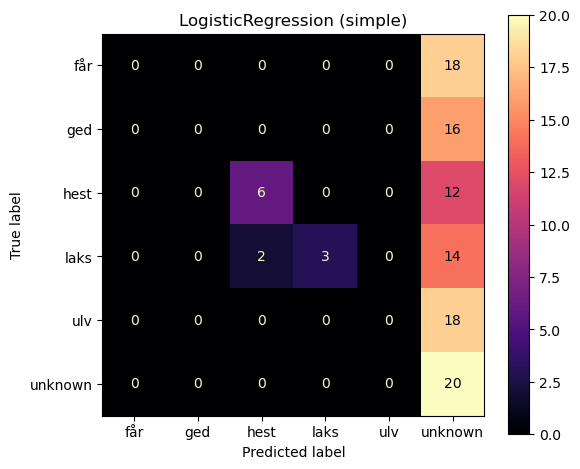


Model: LinearSVM, Features: simple
Accuracy: 0.26605504587155965
              precision    recall  f1-score   support

         får       0.00      0.00      0.00        18
         ged       0.00      0.00      0.00        16
        hest       0.83      0.28      0.42        18
        laks       1.00      0.21      0.35        19
         ulv       0.00      0.00      0.00        18
     unknown       0.20      1.00      0.34        20

    accuracy                           0.27       109
   macro avg       0.34      0.25      0.18       109
weighted avg       0.35      0.27      0.19       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


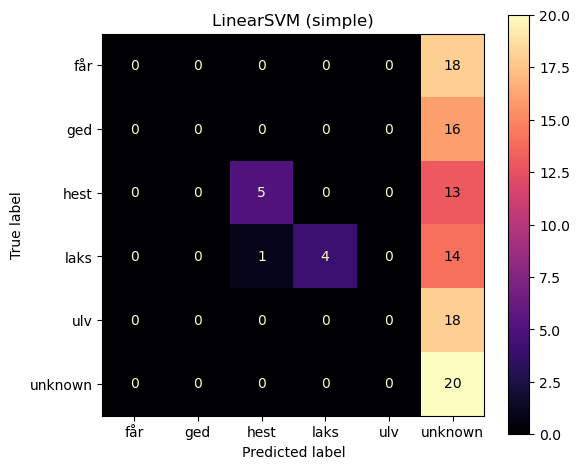


Model: RandomForest, Features: simple
Accuracy: 0.25688073394495414
              precision    recall  f1-score   support

         får       0.00      0.00      0.00        18
         ged       1.00      0.06      0.12        16
        hest       1.00      0.17      0.29        18
        laks       1.00      0.21      0.35        19
         ulv       0.00      0.00      0.00        18
     unknown       0.20      1.00      0.33        20

    accuracy                           0.26       109
   macro avg       0.53      0.24      0.18       109
weighted avg       0.52      0.26      0.19       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


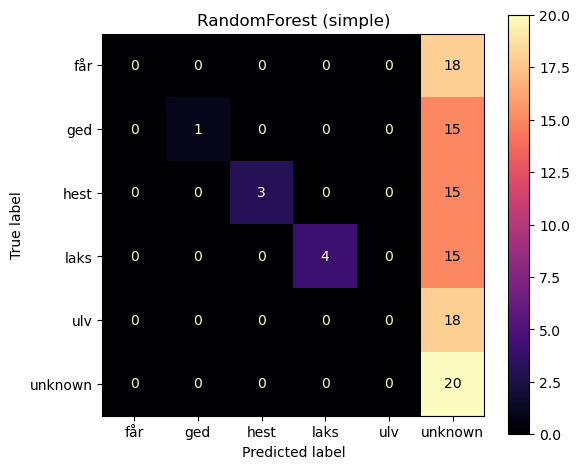


Model: LogisticRegression, Features: mfcc
Accuracy: 0.3486238532110092
              precision    recall  f1-score   support

         får       1.00      0.22      0.36        18
         ged       1.00      0.12      0.22        16
        hest       1.00      0.06      0.11        18
        laks       1.00      0.32      0.48        19
         ulv       1.00      0.28      0.43        18
     unknown       0.22      1.00      0.36        20

    accuracy                           0.35       109
   macro avg       0.87      0.33      0.33       109
weighted avg       0.86      0.35      0.33       109



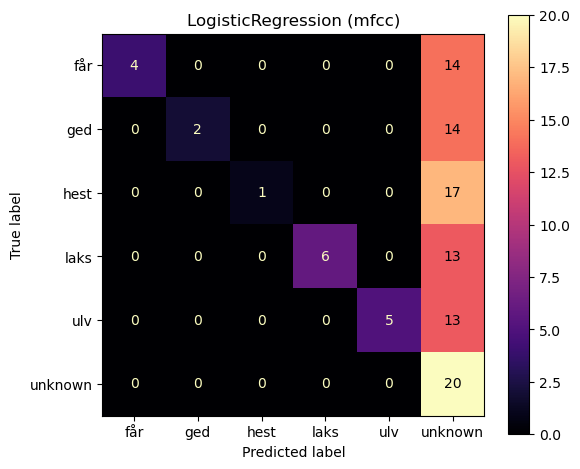


Model: LinearSVM, Features: mfcc
Accuracy: 0.27522935779816515
              precision    recall  f1-score   support

         får       1.00      0.11      0.20        18
         ged       0.00      0.00      0.00        16
        hest       0.00      0.00      0.00        18
        laks       1.00      0.32      0.48        19
         ulv       1.00      0.11      0.20        18
     unknown       0.20      1.00      0.34        20

    accuracy                           0.28       109
   macro avg       0.53      0.26      0.20       109
weighted avg       0.54      0.28      0.21       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


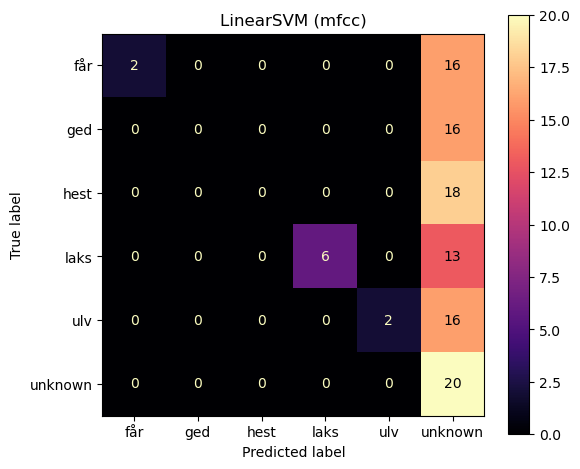


Model: RandomForest, Features: mfcc
Accuracy: 0.24770642201834864
              precision    recall  f1-score   support

         får       1.00      0.28      0.43        18
         ged       0.00      0.00      0.00        16
        hest       0.00      0.00      0.00        18
        laks       1.00      0.11      0.19        19
         ulv       0.00      0.00      0.00        18
     unknown       0.20      1.00      0.33        20

    accuracy                           0.25       109
   macro avg       0.37      0.23      0.16       109
weighted avg       0.38      0.25      0.17       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


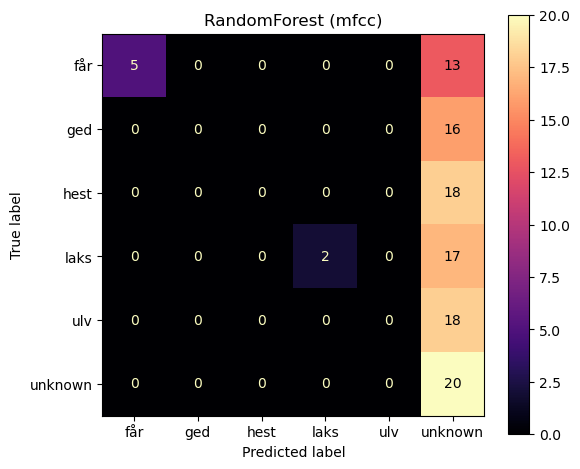


Model: LogisticRegression, Features: combined
Accuracy: 0.3761467889908257
              precision    recall  f1-score   support

         får       1.00      0.28      0.43        18
         ged       0.00      0.00      0.00        16
        hest       1.00      0.22      0.36        18
        laks       1.00      0.32      0.48        19
         ulv       1.00      0.33      0.50        18
     unknown       0.23      1.00      0.37        20

    accuracy                           0.38       109
   macro avg       0.70      0.36      0.36       109
weighted avg       0.71      0.38      0.37       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


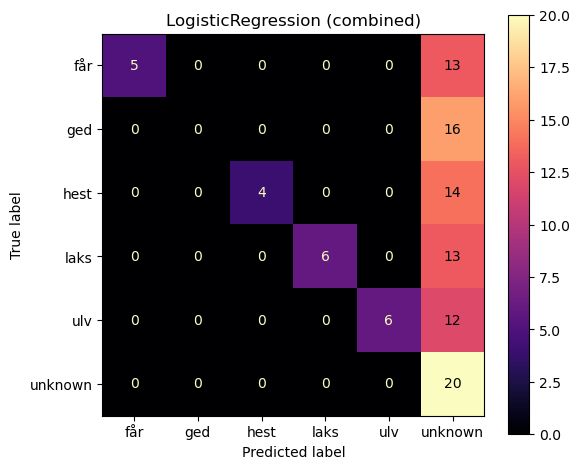


Model: LinearSVM, Features: combined
Accuracy: 0.27522935779816515
              precision    recall  f1-score   support

         får       1.00      0.11      0.20        18
         ged       0.00      0.00      0.00        16
        hest       0.00      0.00      0.00        18
        laks       1.00      0.32      0.48        19
         ulv       1.00      0.11      0.20        18
     unknown       0.20      1.00      0.34        20

    accuracy                           0.28       109
   macro avg       0.53      0.26      0.20       109
weighted avg       0.54      0.28      0.21       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


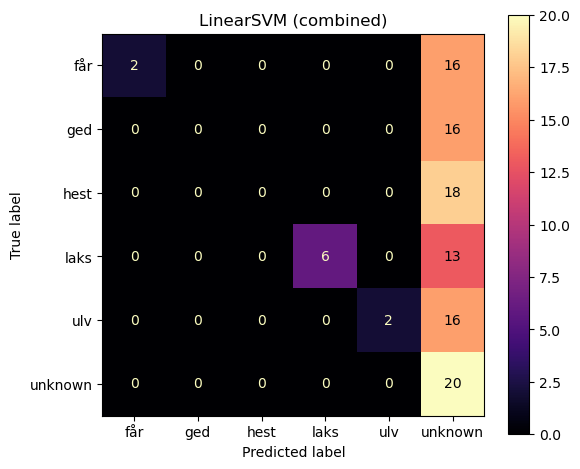


Model: RandomForest, Features: combined
Accuracy: 0.22935779816513763
              precision    recall  f1-score   support

         får       1.00      0.17      0.29        18
         ged       0.00      0.00      0.00        16
        hest       1.00      0.06      0.11        18
        laks       1.00      0.05      0.10        19
         ulv       0.00      0.00      0.00        18
     unknown       0.19      1.00      0.32        20

    accuracy                           0.23       109
   macro avg       0.53      0.21      0.14       109
weighted avg       0.54      0.23      0.14       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


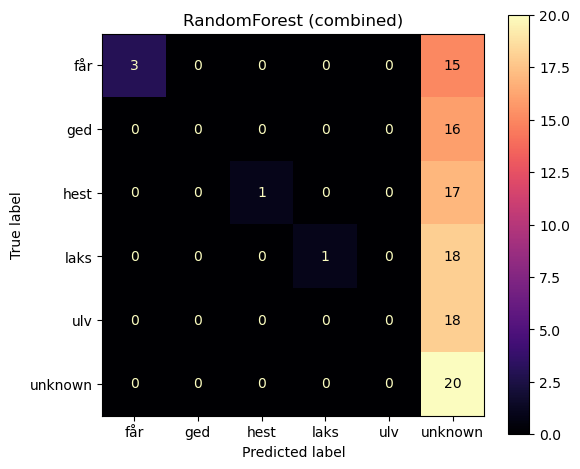


Summary:
                model  features  accuracy
6  LogisticRegression  combined  0.376147
3  LogisticRegression      mfcc  0.348624
4           LinearSVM      mfcc  0.275229
7           LinearSVM  combined  0.275229
0  LogisticRegression    simple  0.266055
1           LinearSVM    simple  0.266055
2        RandomForest    simple  0.256881
5        RandomForest      mfcc  0.247706
8        RandomForest  combined  0.229358


In [17]:
from pathlib import Path
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import matplotlib.pyplot as plt

from scipy.signal import medfilt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    accuracy_score,
    classification_report,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# =========================
# SETTINGS
# =========================
TRAIN_KEYWORDS_DIR = Path("prepared_words")
TRAIN_UNKNOWN_DIR = Path("unknown_balanced")
TEST_DIR = Path("test_ready")

KEYWORD_LABELS = ["får", "ged", "hest", "laks", "ulv"]
ALL_LABELS = KEYWORD_LABELS + ["unknown"]

SAMPLE_RATE = 16000
N_MFCC = 13

# =========================
# PREPROCESSING
# =========================
def remove_clicks(x, threshold=4.0):
    """
    Erstat store impuls-spikes med gennemsnittet af nabosamples.
    threshold angives i antal standardafvigelser.
    """
    x = x.copy()
    std = np.std(x) + 1e-12
    spike_mask = np.abs(x) > threshold * std
    spike_idx = np.where(spike_mask)[0]

    for i in spike_idx:
        if 1 <= i < len(x) - 1:
            x[i] = 0.5 * (x[i - 1] + x[i + 1])
        elif i == 0 and len(x) > 1:
            x[i] = x[i + 1]
        elif i == len(x) - 1 and len(x) > 1:
            x[i] = x[i - 1]

    return x


def preprocess_audio(x):
    """
    Simpel de-click preprocessing.
    Først spike-fjernelse, derefter medianfilter.
    """
    x = remove_clicks(x, threshold=4.0)
    x = medfilt(x, kernel_size=5)
    return x

# =========================
# AUDIO / FEATURE FUNCTIONS
# =========================
def load_wav(path: Path):
    x, fs = sf.read(str(path), always_2d=False)
    x = np.asarray(x, dtype=np.float32)

    if x.ndim > 1:
        x = x.mean(axis=1)

    if fs != SAMPLE_RATE:
        raise ValueError(f"Unexpected sample rate in {path}: {fs}")

    # Preprocessing mod klik / impulsstøj
    x = preprocess_audio(x)

    peak = np.max(np.abs(x)) + 1e-9
    x = x / peak

    return x

def magnitude_spectrum(x, fs):
    window = np.hanning(len(x))
    xw = x * window
    spec = np.fft.rfft(xw)
    mag = np.abs(spec)
    freqs = np.fft.rfftfreq(len(xw), d=1 / fs)
    return freqs, mag

def rms_energy(x):
    return float(np.sqrt(np.mean(x ** 2) + 1e-12))

def zero_crossing_rate(x):
    return float(np.mean(np.signbit(x[1:]) != np.signbit(x[:-1])))

def spectral_centroid(x, fs):
    freqs, mag = magnitude_spectrum(x, fs)
    return float(np.sum(freqs * mag) / (np.sum(mag) + 1e-12))

def spectral_rolloff(x, fs, roll_percent=0.85):
    freqs, mag = magnitude_spectrum(x, fs)
    cumsum = np.cumsum(mag)
    threshold = roll_percent * cumsum[-1]
    idx = np.searchsorted(cumsum, threshold)
    return float(freqs[min(idx, len(freqs) - 1)])

def dominant_frequency(x, fs):
    freqs, mag = magnitude_spectrum(x, fs)
    idx = np.argmax(mag[1:]) + 1 if len(mag) > 1 else 0
    return float(freqs[idx])

def band_energy(x, fs, f_low, f_high):
    freqs, mag = magnitude_spectrum(x, fs)
    power = mag ** 2
    mask = (freqs >= f_low) & (freqs < f_high)
    return float(np.sum(power[mask]))

def mfcc_features(x, sr, n_mfcc=13):
    mfcc = librosa.feature.mfcc(
        y=x,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=1024,
        hop_length=512
    )

    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)

    return np.concatenate([mfcc_mean, mfcc_std])

def extract_features(x, fs):
    record = {
        "rms": rms_energy(x),
        "zcr": zero_crossing_rate(x),
        "centroid": spectral_centroid(x, fs),
        "rolloff": spectral_rolloff(x, fs),
        "dominant_freq": dominant_frequency(x, fs),
        "band_0_500": band_energy(x, fs, 0, 500),
        "band_500_1500": band_energy(x, fs, 500, 1500),
        "band_1500_3000": band_energy(x, fs, 1500, 3000),
        "band_3000_6000": band_energy(x, fs, 3000, 6000),
    }

    mfcc_vals = mfcc_features(x, fs, n_mfcc=N_MFCC)

    for i in range(N_MFCC):
        record[f"mfcc_mean_{i+1}"] = float(mfcc_vals[i])

    for i in range(N_MFCC):
        record[f"mfcc_std_{i+1}"] = float(mfcc_vals[N_MFCC + i])

    return record

# =========================
# BUILD DATAFRAMES
# =========================
train_records = []

for label in KEYWORD_LABELS:
    for wav_path in sorted((TRAIN_KEYWORDS_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        record = extract_features(x, SAMPLE_RATE)
        record["activity"] = label
        train_records.append(record)

for wav_path in sorted(TRAIN_UNKNOWN_DIR.glob("*.wav")):
    x = load_wav(wav_path)
    record = extract_features(x, SAMPLE_RATE)
    record["activity"] = "unknown"
    train_records.append(record)

train_df = pd.DataFrame(train_records)

test_records = []

for label in ALL_LABELS:
    for wav_path in sorted((TEST_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        record = extract_features(x, SAMPLE_RATE)
        record["activity"] = label
        test_records.append(record)

test_df = pd.DataFrame(test_records)

simple_features = [
    "rms", "zcr", "centroid", "rolloff", "dominant_freq",
    "band_0_500", "band_500_1500", "band_1500_3000", "band_3000_6000"
]
mfcc_feature_cols = (
    [f"mfcc_mean_{i}" for i in range(1, N_MFCC + 1)] +
    [f"mfcc_std_{i}" for i in range(1, N_MFCC + 1)]
)
all_features = simple_features + mfcc_feature_cols

feature_sets = {
    "simple": simple_features,
    "mfcc": mfcc_feature_cols,
    "combined": all_features,
}

models = {
    "LogisticRegression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=3000)
    ),
    "LinearSVM": make_pipeline(
        StandardScaler(),
        LinearSVC()
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=3,
        random_state=42
    ),
}

results = []

for feat_name, feat_cols in feature_sets.items():
    X_train = train_df[feat_cols]
    y_train = train_df["activity"]

    X_test = test_df[feat_cols]
    y_test = test_df["activity"]

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        results.append({
            "model": model_name,
            "features": feat_name,
            "accuracy": acc
        })

        print(f"\nModel: {model_name}, Features: {feat_name}")
        print("Accuracy:", acc)
        print(classification_report(y_test, y_pred, labels=ALL_LABELS))

        cm = confusion_matrix(y_test, y_pred, labels=ALL_LABELS)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=ALL_LABELS
        )

        fig, ax = plt.subplots(figsize=(6, 5))
        disp.plot(ax=ax, cmap="magma", values_format="d")
        plt.title(f"{model_name} ({feat_name})")
        plt.tight_layout()
        plt.show()

results_df = pd.DataFrame(results)
print("\nSummary:")
print(results_df.sort_values("accuracy", ascending=False))


Model: LogisticRegression, Features: simple
Accuracy: 0.26605504587155965
              precision    recall  f1-score   support

         får       0.00      0.00      0.00        18
         ged       0.00      0.00      0.00        16
        hest       0.83      0.28      0.42        18
        laks       1.00      0.21      0.35        19
         ulv       0.00      0.00      0.00        18
     unknown       0.20      1.00      0.34        20

    accuracy                           0.27       109
   macro avg       0.34      0.25      0.18       109
weighted avg       0.35      0.27      0.19       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


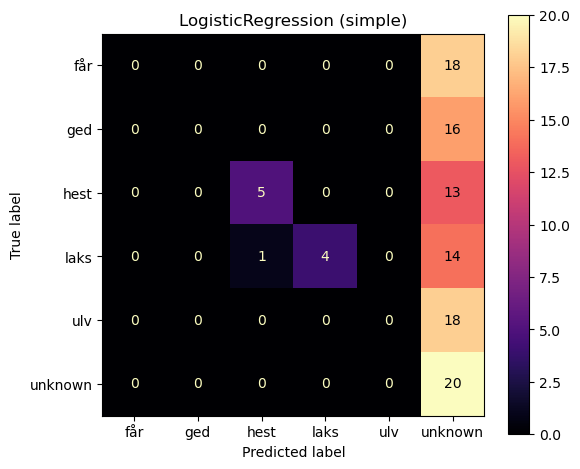


Model: LinearSVM, Features: simple
Accuracy: 0.26605504587155965
              precision    recall  f1-score   support

         får       0.00      0.00      0.00        18
         ged       0.00      0.00      0.00        16
        hest       0.83      0.28      0.42        18
        laks       1.00      0.21      0.35        19
         ulv       0.00      0.00      0.00        18
     unknown       0.20      1.00      0.34        20

    accuracy                           0.27       109
   macro avg       0.34      0.25      0.18       109
weighted avg       0.35      0.27      0.19       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


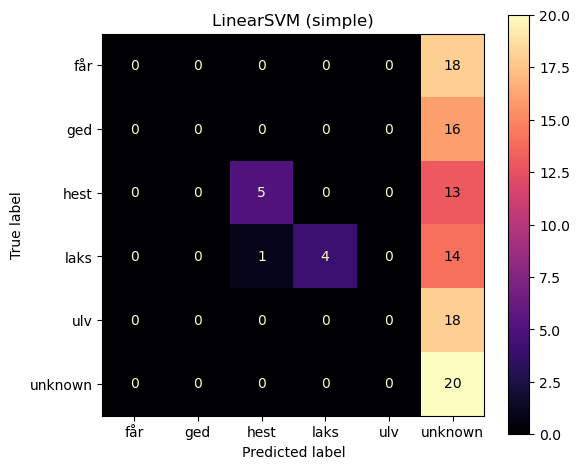


Model: RandomForest, Features: simple
Accuracy: 0.25688073394495414
              precision    recall  f1-score   support

         får       0.00      0.00      0.00        18
         ged       1.00      0.06      0.12        16
        hest       1.00      0.17      0.29        18
        laks       1.00      0.21      0.35        19
         ulv       0.00      0.00      0.00        18
     unknown       0.20      1.00      0.33        20

    accuracy                           0.26       109
   macro avg       0.53      0.24      0.18       109
weighted avg       0.52      0.26      0.19       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


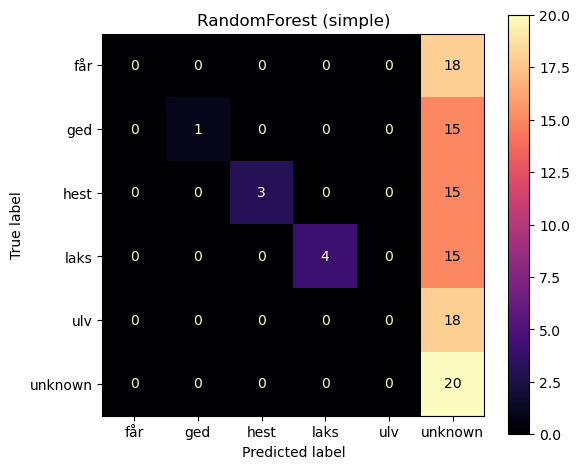


Model: LogisticRegression, Features: mfcc
Accuracy: 0.3853211009174312
              precision    recall  f1-score   support

         får       1.00      0.17      0.29        18
         ged       1.00      0.19      0.32        16
        hest       1.00      0.22      0.36        18
        laks       1.00      0.32      0.48        19
         ulv       1.00      0.33      0.50        18
     unknown       0.23      1.00      0.37        20

    accuracy                           0.39       109
   macro avg       0.87      0.37      0.39       109
weighted avg       0.86      0.39      0.39       109



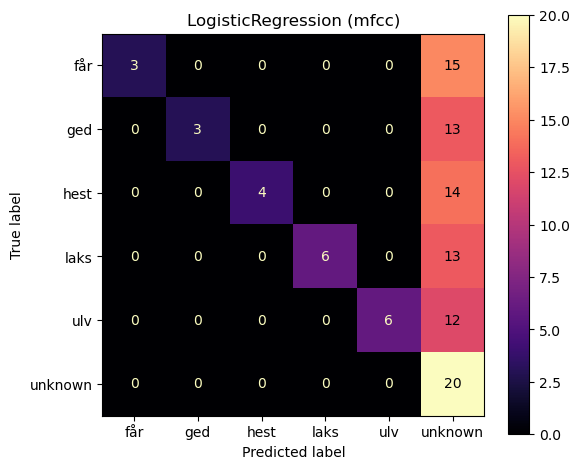


Model: LinearSVM, Features: mfcc
Accuracy: 0.4036697247706422
              precision    recall  f1-score   support

         får       1.00      0.11      0.20        18
         ged       1.00      0.12      0.22        16
        hest       1.00      0.22      0.36        18
        laks       1.00      0.47      0.64        19
         ulv       1.00      0.39      0.56        18
     unknown       0.24      1.00      0.38        20

    accuracy                           0.40       109
   macro avg       0.87      0.39      0.39       109
weighted avg       0.86      0.40      0.40       109



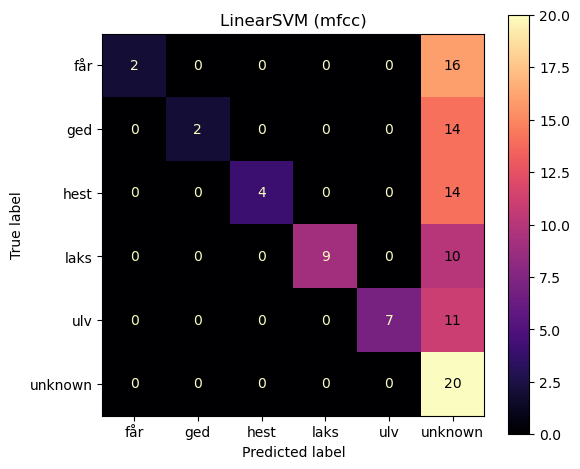


Model: RandomForest, Features: mfcc
Accuracy: 0.29357798165137616
              precision    recall  f1-score   support

         får       1.00      0.67      0.80        18
         ged       0.00      0.00      0.00        16
        hest       0.00      0.00      0.00        18
        laks       0.00      0.00      0.00        19
         ulv       0.00      0.00      0.00        18
     unknown       0.21      1.00      0.34        20

    accuracy                           0.29       109
   macro avg       0.20      0.28      0.19       109
weighted avg       0.20      0.29      0.19       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


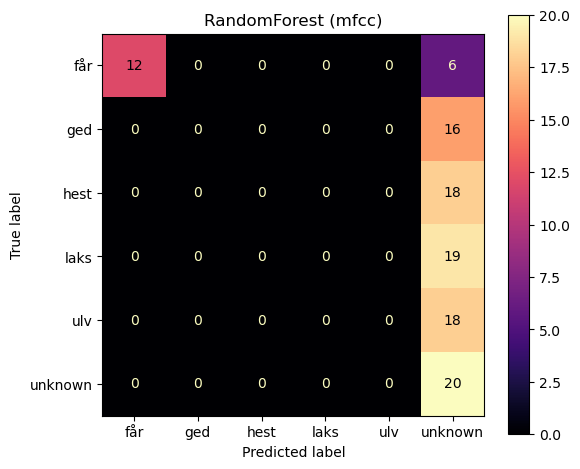


Model: LogisticRegression, Features: combined
Accuracy: 0.46788990825688076
              precision    recall  f1-score   support

         får       1.00      0.39      0.56        18
         ged       1.00      0.25      0.40        16
        hest       1.00      0.28      0.43        18
        laks       1.00      0.32      0.48        19
         ulv       1.00      0.50      0.67        18
     unknown       0.26      1.00      0.41        20

    accuracy                           0.47       109
   macro avg       0.88      0.46      0.49       109
weighted avg       0.86      0.47      0.49       109



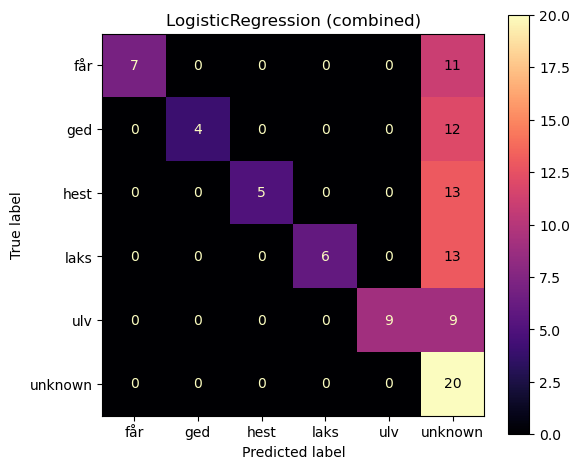


Model: LinearSVM, Features: combined
Accuracy: 0.3761467889908257
              precision    recall  f1-score   support

         får       1.00      0.28      0.43        18
         ged       1.00      0.12      0.22        16
        hest       1.00      0.22      0.36        18
        laks       1.00      0.21      0.35        19
         ulv       1.00      0.33      0.50        18
     unknown       0.23      1.00      0.37        20

    accuracy                           0.38       109
   macro avg       0.87      0.36      0.37       109
weighted avg       0.86      0.38      0.38       109



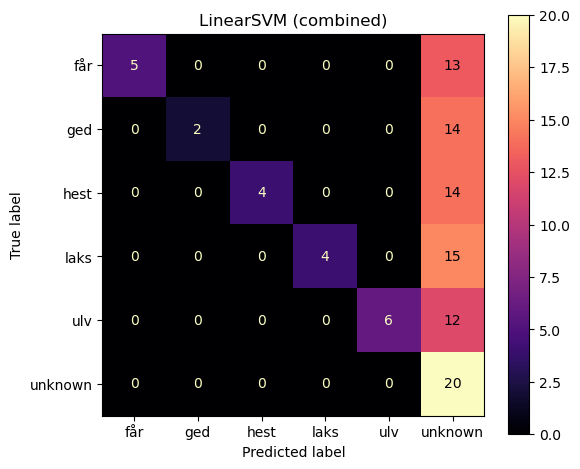


Model: RandomForest, Features: combined
Accuracy: 0.3211009174311927
              precision    recall  f1-score   support

         får       1.00      0.56      0.71        18
         ged       0.00      0.00      0.00        16
        hest       1.00      0.11      0.20        18
        laks       1.00      0.16      0.27        19
         ulv       0.00      0.00      0.00        18
     unknown       0.21      1.00      0.35        20

    accuracy                           0.32       109
   macro avg       0.54      0.30      0.26       109
weighted avg       0.54      0.32      0.26       109



c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


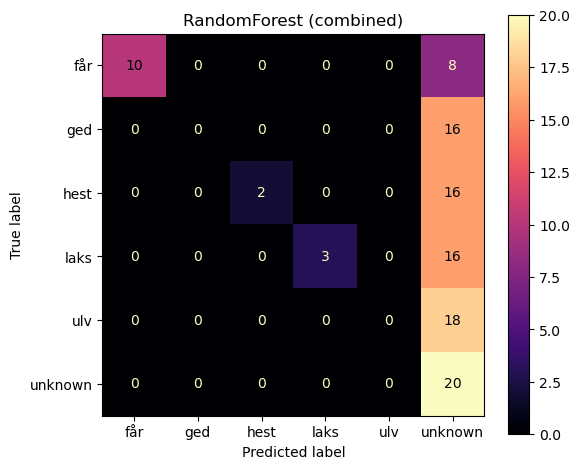


Summary:
                model  features  accuracy
6  LogisticRegression  combined  0.467890
4           LinearSVM      mfcc  0.403670
3  LogisticRegression      mfcc  0.385321
7           LinearSVM  combined  0.376147
8        RandomForest  combined  0.321101
5        RandomForest      mfcc  0.293578
0  LogisticRegression    simple  0.266055
1           LinearSVM    simple  0.266055
2        RandomForest    simple  0.256881


In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import matplotlib.pyplot as plt

from scipy.signal import medfilt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    accuracy_score,
    classification_report,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# =========================
# SETTINGS
# =========================
TRAIN_KEYWORDS_DIR = Path("prepared_words")
TRAIN_UNKNOWN_DIR = Path("unknown_balanced")
TEST_DIR = Path("test_ready")

KEYWORD_LABELS = ["får", "ged", "hest", "laks", "ulv"]
ALL_LABELS = KEYWORD_LABELS + ["unknown"]

SAMPLE_RATE = 16000
N_MFCC = 13

# =========================
# PREPROCESSING
# =========================
def remove_clicks(x, threshold=4.0):
    """
    Erstat store impuls-spikes med gennemsnittet af nabosamples.
    threshold angives i antal standardafvigelser.
    """
    x = x.copy()
    std = np.std(x) + 1e-12
    spike_mask = np.abs(x) > threshold * std
    spike_idx = np.where(spike_mask)[0]

    for i in spike_idx:
        if 1 <= i < len(x) - 1:
            x[i] = 0.5 * (x[i - 1] + x[i + 1])
        elif i == 0 and len(x) > 1:
            x[i] = x[i + 1]
        elif i == len(x) - 1 and len(x) > 1:
            x[i] = x[i - 1]

    return x


def preprocess_audio(x):
    """
    Simpel de-click preprocessing.
    Først spike-fjernelse, derefter medianfilter.
    """
    x = remove_clicks(x, threshold=4.0)
    x = medfilt(x, kernel_size=5)
    return x

# =========================
# AUDIO / FEATURE FUNCTIONS
# =========================
def load_wav(path: Path):
    x, fs = sf.read(str(path), always_2d=False)
    x = np.asarray(x, dtype=np.float32)

    if x.ndim > 1:
        x = x.mean(axis=1)

    if fs != SAMPLE_RATE:
        raise ValueError(f"Unexpected sample rate in {path}: {fs}")

    x = preprocess_audio(x)

    peak = np.max(np.abs(x)) + 1e-9
    x = x / peak

    return x


def magnitude_spectrum(x, fs):
    window = np.hanning(len(x))
    xw = x * window
    spec = np.fft.rfft(xw)
    mag = np.abs(spec)
    freqs = np.fft.rfftfreq(len(xw), d=1 / fs)
    return freqs, mag


def rms_energy(x):
    return float(np.sqrt(np.mean(x ** 2) + 1e-12))


def zero_crossing_rate(x):
    return float(np.mean(np.signbit(x[1:]) != np.signbit(x[:-1])))


def spectral_centroid(x, fs):
    freqs, mag = magnitude_spectrum(x, fs)
    return float(np.sum(freqs * mag) / (np.sum(mag) + 1e-12))


def spectral_rolloff(x, fs, roll_percent=0.85):
    freqs, mag = magnitude_spectrum(x, fs)
    cumsum = np.cumsum(mag)
    threshold = roll_percent * cumsum[-1]
    idx = np.searchsorted(cumsum, threshold)
    return float(freqs[min(idx, len(freqs) - 1)])


def dominant_frequency(x, fs):
    freqs, mag = magnitude_spectrum(x, fs)
    idx = np.argmax(mag[1:]) + 1 if len(mag) > 1 else 0
    return float(freqs[idx])


def band_energy(x, fs, f_low, f_high):
    freqs, mag = magnitude_spectrum(x, fs)
    power = mag ** 2
    mask = (freqs >= f_low) & (freqs < f_high)
    return float(np.sum(power[mask]))


def mfcc_features(x, sr, n_mfcc=13):
    mfcc = librosa.feature.mfcc(
        y=x,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=1024,
        hop_length=512
    )

    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    feats = []

    for m in [mfcc, delta, delta2]:
        feats.append(np.mean(m, axis=1))
        feats.append(np.std(m, axis=1))

    return np.concatenate(feats)


def extract_features(x, fs):
    record = {
        "rms": rms_energy(x),
        "zcr": zero_crossing_rate(x),
        "centroid": spectral_centroid(x, fs),
        "rolloff": spectral_rolloff(x, fs),
        "dominant_freq": dominant_frequency(x, fs),
        "band_0_500": band_energy(x, fs, 0, 500),
        "band_500_1500": band_energy(x, fs, 500, 1500),
        "band_1500_3000": band_energy(x, fs, 1500, 3000),
        "band_3000_6000": band_energy(x, fs, 3000, 6000),
    }

    mfcc_vals = mfcc_features(x, fs, n_mfcc=N_MFCC)

    idx = 0
    for name_prefix in [
        "mfcc_mean",
        "mfcc_std",
        "delta_mean",
        "delta_std",
        "delta2_mean",
        "delta2_std",
    ]:
        for i in range(1, N_MFCC + 1):
            record[f"{name_prefix}_{i}"] = float(mfcc_vals[idx])
            idx += 1

    return record

# =========================
# BUILD DATAFRAMES
# =========================
train_records = []

for label in KEYWORD_LABELS:
    for wav_path in sorted((TRAIN_KEYWORDS_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        record = extract_features(x, SAMPLE_RATE)
        record["activity"] = label
        train_records.append(record)

for wav_path in sorted(TRAIN_UNKNOWN_DIR.glob("*.wav")):
    x = load_wav(wav_path)
    record = extract_features(x, SAMPLE_RATE)
    record["activity"] = "unknown"
    train_records.append(record)

train_df = pd.DataFrame(train_records)

test_records = []

for label in ALL_LABELS:
    for wav_path in sorted((TEST_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        record = extract_features(x, SAMPLE_RATE)
        record["activity"] = label
        test_records.append(record)

test_df = pd.DataFrame(test_records)

simple_features = [
    "rms", "zcr", "centroid", "rolloff", "dominant_freq",
    "band_0_500", "band_500_1500", "band_1500_3000", "band_3000_6000"
]

mfcc_feature_cols = (
    [f"mfcc_mean_{i}" for i in range(1, N_MFCC + 1)] +
    [f"mfcc_std_{i}" for i in range(1, N_MFCC + 1)] +
    [f"delta_mean_{i}" for i in range(1, N_MFCC + 1)] +
    [f"delta_std_{i}" for i in range(1, N_MFCC + 1)] +
    [f"delta2_mean_{i}" for i in range(1, N_MFCC + 1)] +
    [f"delta2_std_{i}" for i in range(1, N_MFCC + 1)]
)

all_features = simple_features + mfcc_feature_cols

feature_sets = {
    "simple": simple_features,
    "mfcc": mfcc_feature_cols,
    "combined": all_features,
}

models = {
    "LogisticRegression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=3000, C=0.1)
    ),
    "LinearSVM": make_pipeline(
        StandardScaler(),
        LinearSVC()
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=3,
        random_state=42
    ),
}

results = []

for feat_name, feat_cols in feature_sets.items():
    X_train = train_df[feat_cols]
    y_train = train_df["activity"]

    X_test = test_df[feat_cols]
    y_test = test_df["activity"]

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        results.append({
            "model": model_name,
            "features": feat_name,
            "accuracy": acc
        })

        print(f"\nModel: {model_name}, Features: {feat_name}")
        print("Accuracy:", acc)
        print(classification_report(y_test, y_pred, labels=ALL_LABELS))

        cm = confusion_matrix(y_test, y_pred, labels=ALL_LABELS)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=ALL_LABELS
        )

        fig, ax = plt.subplots(figsize=(6, 5))
        disp.plot(ax=ax, cmap="magma", values_format="d")
        plt.title(f"{model_name} ({feat_name})")
        plt.tight_layout()
        plt.show()

results_df = pd.DataFrame(results)
print("\nSummary:")
print(results_df.sort_values("accuracy", ascending=False))